# Phase 1B — Probability-Based Multi-Label Unlearning Benchmark

This Colab-ready notebook repeats the **target-paragraph-only Phase 1 comparison** with the old and new codebooks, but asks each LLM to return **elicited probability distributions** instead of only hard labels.

The experiment is designed to answer four separate questions:

1. Does requesting probabilities preserve or improve the raw hard-label predictions?
2. Can out-of-sample calibration and threshold selection improve binary Unlearning accuracy/F1 without unacceptable loss of specificity?
3. Can hierarchical post-processing improve the old-codebook and new-codebook label assignments?
4. Can probability ensembling across OpenAI, Anthropic, and Gemini improve results over the earlier labels-only Phase 1 run?

**Important interpretation:** the probabilities requested here are *model-reported probabilities*, not native next-token log probabilities. They must therefore be evaluated for calibration rather than assumed to be calibrated.

## Default matched Phase 1 conditions

- Old codebook + simple definition prompt
- Old codebook + explicit evidence checklist
- New codebook + simple definition prompt
- New codebook + explicit evidence checklist
- Optional direct/no-definition control

The provisional adaptive definition conditions from the earlier seven-condition Phase 1 design are included as optional configuration, but disabled by default because this study focuses on the old-versus-new codebook comparison.

## Leakage control

Thresholds, Platt scaling, isotonic calibration, stacking, and multiclass calibration are evaluated **out of fold**. Binary post-processing prefers document-held-out folds when multiple source documents are available. The notebook never tunes a threshold on a row and then scores that same row with the tuned threshold.

## Core outputs

- Frozen JSONL probability responses from every API call
- Raw probability and hard-label metrics
- Reliability/calibration metrics and reliability tables
- Cross-fitted post-processing comparisons
- Probability ensembles across providers
- Old/new label-family metrics
- Paired comparison with imported labels-only Phase 1 predictions
- Uncertainty-ranked human-review queue
- CSV, Excel, JSON, and plot artifacts


## 0. Install packages

Run this cell once in a fresh Colab runtime. Restart the runtime only if Colab asks you to do so.


In [1]:
%pip install -q -U openpyxl pyarrow scipy tqdm pydantic openai anthropic google-genai tiktoken nbformat


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.8/79.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.1/259.1 kB 10.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently ta

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports, API keys, and reproducibility

Store keys in **Colab Secrets** using these names:

- `OPENAI_API_KEY`
- `ANTHROPIC_API_KEY`
- `GEMINI_API_KEY`

The notebook also works with ordinary environment variables outside Colab.


In [3]:
from __future__ import annotations

import copy
import hashlib
import json
import math
import os
import random
import re
import time
import traceback
import warnings
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable, Mapping, Optional

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.special import expit, logit
from scipy.stats import binomtest
from sklearn.calibration import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)

try:
    from google.colab import userdata

    for _env_name in ["OPENAI_API_KEY", "ANTHROPIC_API_KEY", "GEMINI_API_KEY"]:
        try:
            _value = userdata.get(_env_name)
        except Exception:
            _value = None
        if _value:
            os.environ[_env_name] = _value
    print("Loaded available API keys from Colab Secrets.")
except ImportError:
    print("Not running in Colab; using ordinary environment variables.")

GLOBAL_SEED = 17
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)


Loaded available API keys from Colab Secrets.


## 2. Experiment configuration

Start with `RUN_API_CALLS = False`. Inspect the loaded benchmark, prompts, schemas, call count, and token estimate first. Then set it to `True` and enter the confirmation phrase.

The default model IDs are the requested model IDs used in the prior Phase 1 work so that the probability run can be compared as closely as possible. Change an ID only when the provider no longer accepts it, and record that change in the final manifest.


In [27]:
# -------------------------------
# Runtime and file configuration
# -------------------------------
MOUNT_GOOGLE_DRIVE = True
DRIVE_MOUNT_POINT = "/content/drive"

# A directory is safer than scattering outputs around MyDrive.
PROJECT_ROOT = Path("/content/drive/MyDrive/Unlearning_Project/phase1_probability_v1")
if not Path("/content").exists():
    PROJECT_ROOT = Path("./phase1_probability_v1")

INPUT_DIR = PROJECT_ROOT / "inputs"
RUN_DIR = PROJECT_ROOT / "runs"
REPORT_DIR = PROJECT_ROOT / "reports"
PLOT_DIR = REPORT_DIR / "plots"
for _directory in [INPUT_DIR, RUN_DIR, REPORT_DIR, PLOT_DIR]:
    _directory.mkdir(parents=True, exist_ok=True)

# Supply either:
#   A) one combined workbook with old/new codebook sheets and the GPT Test sheet, OR
#   B) separate old and new codebook workbooks plus an optional benchmark workbook.
COMBINED_WORKBOOK_PATH: Optional[Path] = None
OLD_CODEBOOK_PATH: Optional[Path] = None
NEW_CODEBOOK_PATH: Optional[Path] = None
BENCHMARK_PATH: Optional[Path] = None

# Optional frozen hard-label predictions from the previous Phase 1 experiment.
# This can be a JSONL/CSV/Parquet/XLSX file or a directory containing provider JSONL files.
LABELS_ONLY_BASELINE_PATH: Optional[Path] = None

AUTO_DISCOVER_FILES = True
DEMO_MODE_IF_INPUTS_MISSING = True

# Common sheet names; automatic matching is case/spacing insensitive.
BENCHMARK_SHEET_CANDIDATES = ["GPT Test", "Cleaned GPT Test", "Benchmark", "benchmark_canonical"]
OLD_CODEBOOK_SHEET_CANDIDATES = ["Codebook (original)", "Codebook original", "Original Codebook", "Old Codebook"]
NEW_CODEBOOK_SHEET_CANDIDATES = ["Codebook (revised)", "Codebook revised", "Revised Codebook", "New Codebook", "Codebook"]

# Explicit column overrides. Leave None for automatic detection.
ROW_ID_COLUMN: Optional[str] = None
TEXT_COLUMN: Optional[str] = None
DOCUMENT_COLUMN: Optional[str] = None
GOLD_BINARY_SHARED_COLUMN: Optional[str] = None
GOLD_BINARY_OLD_COLUMN: Optional[str] = None
GOLD_BINARY_NEW_COLUMN: Optional[str] = None
GOLD_NEW_TARGET_COLUMN: Optional[str] = None
GOLD_OLD_PILLAR_COLUMN: Optional[str] = None
GOLD_OLD_DEPTH_COLUMN: Optional[str] = None
GOLD_OLD_NATURE_COLUMN: Optional[str] = None

EXPECTED_BENCHMARK_ROWS: Optional[int] = 42
EXPECTED_DATASET_SHA256: Optional[str] = None
ENFORCE_EXPECTED_DATASET_HASH = False

# -------------------------------
# Phase 1 conditions
# -------------------------------
INCLUDE_DIRECT_CONTROL = True
INCLUDE_ADAPTIVE_CONDITIONS = False
ADAPTIVE_DEFINITION_TEXT = ""  # Paste/freeze the provisional adaptive definition here before enabling it.

# Probability conditions use target paragraph only, matching Phase 1 C1_target.
CONDITIONS_TO_RUN = [
    "P1_DIRECT",
    "P2_D1_OLD",
    "P2_D2_CURRENT",
    "P3_D1_OLD",
    "P3_D2_CURRENT",
]
if not INCLUDE_DIRECT_CONTROL:
    CONDITIONS_TO_RUN = [c for c in CONDITIONS_TO_RUN if c != "P1_DIRECT"]
if INCLUDE_ADAPTIVE_CONDITIONS:
    CONDITIONS_TO_RUN += ["P2_D3_ADAPTIVE", "P3_D3_ADAPTIVE"]

# -------------------------------
# Providers and model controls
# -------------------------------
PROVIDER_CONFIGS = {
    "openai": {
        "enabled": True,
        "model": "gpt-5.6-terra",
        "api_key_env": "OPENAI_API_KEY",
        "max_output_tokens": 2200,
        "reasoning_effort": "low",
        "sleep_seconds": 0.15,
        # Optional current prices. Leave None to disable dollar estimates.
        "input_usd_per_million": None,
        "output_usd_per_million": None,
    },
    "anthropic": {
        "enabled": True,
        "model": "claude-haiku-4-5-20251001",
        "api_key_env": "ANTHROPIC_API_KEY",
        "max_output_tokens": 2200,
        "sleep_seconds": 0.15,
        "input_usd_per_million": None,
        "output_usd_per_million": None,
    },
    "gemini": {
        "enabled": True,
        "model": "gemini-3.1-flash-lite",
        "api_key_env": "GEMINI_API_KEY",
        "max_output_tokens": 2200,
        "thinking_level": "low",
        "sleep_seconds": 0.15,
        "input_usd_per_million": None,
        "output_usd_per_million": None,
    },
}

# Use one seed for the direct Phase 1 comparison. The optional stability grid repeats selected conditions.
SEEDS_TO_RUN = [17]
RUN_STABILITY_GRID = False
STABILITY_SEEDS = [17, 43, 101, 211, 307]
STABILITY_CONDITIONS = ["P2_D1_OLD", "P2_D2_CURRENT", "P3_D1_OLD", "P3_D2_CURRENT"]

ROW_LIMIT: Optional[int] = None
RUN_API_CALLS = True
RUN_CONFIRMATION = "RUN PROBABILITY PHASE 1"  # Must exactly equal: RUN PROBABILITY PHASE 1
CONFIRMATION_PHRASE = "RUN PROBABILITY PHASE 1"
RESUME_FROM_JSONL = True
STOP_PROVIDER_ON_FIRST_FINAL_ERROR = False
MAX_ATTEMPTS = 4
MAX_TOTAL_CALLS = 1500
MAX_ESTIMATED_COST_USD: Optional[float] = None

# Set True only for notebook self-tests; never use mock predictions as research results.
USE_MOCK_PROVIDER = False

# -------------------------------
# Probability and validation rules
# -------------------------------
PROBABILITY_SUM_TOLERANCE = 0.015
MIN_PROBABILITY = 1e-6
MAX_RATIONALE_CHARS = 700

# Binary post-processing candidates. Thresholds are selected only inside training folds.
THRESHOLD_GRID = np.round(np.linspace(0.05, 0.95, 91), 2)
SPECIFICITY_FLOOR = 0.80
PRIMARY_THRESHOLD_OBJECTIVE = "f1"  # f1, balanced_accuracy, accuracy, or youden
CV_SPLITS = 5
CV_REPEATS = 20
CV_RANDOM_SEED = 2026
GROUP_CV_BY_DOCUMENT_WHEN_POSSIBLE = True

# Bootstrap settings for paired uncertainty intervals.
BOOTSTRAP_REPEATS = 2000
BOOTSTRAP_RANDOM_SEED = 8072026

# -------------------------------
# Closed label taxonomies
# -------------------------------
# These reproduce the closed labels used by the prior old/new pipeline. Edit only if your frozen codebook differs.
NEW_LABEL_GROUPS = {
    "target": [
        "leadership",
        "laws_plans_policies",
        "capabilities",
        "funds_resources",
        "misc_organizational",
    ]
}

OLD_LABEL_GROUPS = {
    "pillar": [
        "reconsidering_epistemic",
        "discarding_normative",
        "realignment_technical",
        "merging_integrative",
    ],
    "depth": ["low_depth", "moderate_depth", "high_depth"],
    "nature": ["normative_nature", "technical_nature"],
}

# An agency is open-ended text by default, so it is extracted rather than treated as a normalized class probability.
# To evaluate agency as a closed classification task, supply a pre-registered taxonomy here.
AGENCY_LABELS: list[str] = []

PROTOCOL_VERSION = "phase1_probability_postprocessing_v1"
PROMPT_REVISION = "2026-08-07_r1"

print("Project root:", PROJECT_ROOT.resolve())
print("Conditions:", CONDITIONS_TO_RUN)
print("Enabled providers:", [p for p, c in PROVIDER_CONFIGS.items() if c["enabled"]])
print("RUN_API_CALLS:", RUN_API_CALLS)


Project root: /content/drive/MyDrive/Unlearning_Project/phase1_probability_v1
Conditions: ['P1_DIRECT', 'P2_D1_OLD', 'P2_D2_CURRENT', 'P3_D1_OLD', 'P3_D2_CURRENT']
Enabled providers: ['openai', 'anthropic', 'gemini']
RUN_API_CALLS: True


## 3. Generic utilities and file discovery


In [28]:
def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def normalize_name(value: Any) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(value or "").lower())


def slugify(value: Any) -> str:
    text = re.sub(r"[^a-zA-Z0-9]+", "_", str(value or "").strip().lower())
    return re.sub(r"_+", "_", text).strip("_")


def clean_text(value: Any, max_chars: Optional[int] = None) -> str:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return ""
    text = re.sub(r"\s+", " ", str(value).replace("\r", " ").replace("\n", " ")).strip()
    if max_chars is not None and len(text) > max_chars:
        return text[:max_chars].rstrip() + " …"
    return text


def sha256_text(text: str) -> str:
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def json_safe(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(v) for v in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return None if np.isnan(value) else float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    try:
        missing = pd.isna(value)
        if isinstance(missing, (bool, np.bool_)) and missing:
            return None
    except Exception:
        pass
    return value


def stable_json(value: Any) -> str:
    return json.dumps(json_safe(value), ensure_ascii=False, sort_keys=True, separators=(",", ":"))


def append_jsonl(path: Path, record: Mapping[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as handle:
        handle.write(json.dumps(json_safe(dict(record)), ensure_ascii=False) + "\n")


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    records: list[dict[str, Any]] = []
    if not path.exists():
        return records
    with open(path, "r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                parsed = json.loads(line)
                if isinstance(parsed, dict):
                    records.append(parsed)
            except Exception as error:
                print(f"Skipping malformed JSONL line {line_number} in {path}: {error}")
    return records


def find_column(df: pd.DataFrame, candidates: Iterable[str], explicit: Optional[str] = None) -> Optional[str]:
    if explicit is not None:
        if explicit not in df.columns:
            raise KeyError(f"Explicit column {explicit!r} was not found. Available columns: {list(df.columns)}")
        return explicit
    normalized = {normalize_name(column): column for column in df.columns}
    for candidate in candidates:
        match = normalized.get(normalize_name(candidate))
        if match is not None:
            return match
    return None


def find_sheet(sheet_names: Iterable[str], candidates: Iterable[str]) -> Optional[str]:
    normalized = {normalize_name(name): name for name in sheet_names}
    for candidate in candidates:
        match = normalized.get(normalize_name(candidate))
        if match is not None:
            return match
    # conservative substring fallback
    for candidate in candidates:
        candidate_norm = normalize_name(candidate)
        for key, original in normalized.items():
            if candidate_norm and (candidate_norm in key or key in candidate_norm):
                return original
    return None


def mount_drive_if_requested() -> None:
    if not MOUNT_GOOGLE_DRIVE or not Path("/content").exists():
        return
    try:
        from google.colab import drive

        if not Path(DRIVE_MOUNT_POINT).exists() or not any(Path(DRIVE_MOUNT_POINT).iterdir()):
            drive.mount(DRIVE_MOUNT_POINT)
        else:
            print("Google Drive already appears mounted.")
    except Exception as error:
        print("Drive mount was not completed:", error)


def discover_candidate_files(search_roots: Iterable[Path]) -> pd.DataFrame:
    patterns = ["*.xlsx", "*.xls", "*.csv", "*.parquet", "*.jsonl"]
    rows = []
    for root in search_roots:
        if not root.exists():
            continue
        for pattern in patterns:
            for path in root.rglob(pattern):
                try:
                    stat = path.stat()
                except OSError:
                    continue
                rows.append({
                    "path": str(path),
                    "name": path.name,
                    "suffix": path.suffix.lower(),
                    "size_mb": stat.st_size / (1024 ** 2),
                    "modified_utc": datetime.fromtimestamp(stat.st_mtime, timezone.utc).isoformat(),
                })
    if not rows:
        return pd.DataFrame(columns=["path", "name", "suffix", "size_mb", "modified_utc"])
    return pd.DataFrame(rows).drop_duplicates("path").sort_values("modified_utc", ascending=False)


mount_drive_if_requested()

SEARCH_ROOTS = [Path("/content"), Path("/content/drive/MyDrive"), Path.cwd(), INPUT_DIR]
file_inventory_df = discover_candidate_files(SEARCH_ROOTS) if AUTO_DISCOVER_FILES else pd.DataFrame()
if len(file_inventory_df):
    print(f"Discovered {len(file_inventory_df):,} candidate files. Most recent relevant names:")
    display(file_inventory_df[file_inventory_df["name"].str.contains("unlearning|codebook|benchmark|phase", case=False, regex=True)].head(30))
else:
    print("No candidate files discovered automatically.")


Google Drive already appears mounted.
Discovered 253 candidate files. Most recent relevant names:


,path,name,suffix,size_mb,modified_utc
126,/content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/analysis/prelangchain_posthoc_v1_3_1/tables/phase2_candidates.csv,phase2_candidates.csv,.csv,0.003779,2026-07-24T00:46:08+00:00
110,/content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/analysis/prelangchain_posthoc_v1_3_1/tables/phase2_context_comparison.csv,phase2_context_comparison.csv,.csv,0.003446,2026-07-24T00:46:08+00:00
111,/content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/analysis/prelangchain_posthoc_v1_3_1/tables/phase3_ranking.csv,phase3_ranking.csv,.csv,0.000971,2026-07-24T00:46:08+00:00
112,/content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/analysis/prelangchain_posthoc_v1_3_1/tables/phase3_provider.csv,phase3_provider.csv,.csv,0.002303,2026-07-24T00:46:08+00:00
113,/content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/analysis/prelangchain_posthoc_v1_3_1/tables/phase3_documents.csv,phase3_documents.csv,.csv,0.007534,2026-07-24T00:46:08+00:00
114,/content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/analysis/prelangchain_posthoc_v1_3_1/tables/phase3_target_audit.csv,phase3_target_audit.csv,.csv,0.000160,2026-07-24T00:46:08+00:00
108,/content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/analysis/prelangchain_posthoc_v1_3_1/tables/phase2_documents.csv,phase2_documents.csv,.csv,0.029254,2026-07-24T00:46:08+00:00
109,/content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/analysis/prelangchain_posthoc_v1_3_1/tables/phase2_timing.csv,phase2_timing.csv,.csv,0.003551,2026-07-24T00:46:08+00:00
107,/content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/analysis/prelangchain_posthoc_v1_3_1/tables/phase2_provider.csv,phase2_provider.csv,.csv,0.008324,2026-07-24T00:46:08+00:00
98,/content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/analysis/prelangchain_posthoc_v1_3_1/tables/phase1_ranking.csv,phase1_ranking.csv,.csv,0.002629,2026-07-24T00:46:08+00:00


## 4. Resolve input files and load the benchmark/codebooks

The loader supports either a combined workbook or separate old/new workbooks. Automatic discovery favors filenames containing `old`, `new`, `original`, `revised`, `codebook`, and `unlearning`, but it never overwrites an explicit path.

When no files are available, the notebook can create a **synthetic 42-row dry-run fixture**. The fixture exists only to test code, schemas, checkpointing, and analysis cells; it is not research data.


In [29]:
def _path_or_none(value: Any) -> Optional[Path]:
    if value is None or str(value).strip() == "":
        return None
    return Path(value)


def inspect_excel_sheets(path: Path) -> list[str]:
    try:
        return pd.ExcelFile(path).sheet_names
    except Exception:
        return []


def auto_resolve_paths(
    inventory: pd.DataFrame,
    combined_path: Optional[Path],
    old_path: Optional[Path],
    new_path: Optional[Path],
    benchmark_path: Optional[Path],
) -> tuple[Optional[Path], Optional[Path], Optional[Path], Optional[Path]]:
    combined_path = _path_or_none(combined_path)
    old_path = _path_or_none(old_path)
    new_path = _path_or_none(new_path)
    benchmark_path = _path_or_none(benchmark_path)

    if inventory.empty:
        return combined_path, old_path, new_path, benchmark_path

    candidates = inventory[inventory["suffix"].isin([".xlsx", ".xls"])].copy()
    candidates["name_norm"] = candidates["name"].map(normalize_name)

    def choose(regex: str, exclude: str = r"$a") -> Optional[Path]:
        subset = candidates[
            candidates["name"].str.contains(regex, case=False, regex=True)
            & ~candidates["name"].str.contains(exclude, case=False, regex=True)
        ]
        if subset.empty:
            return None
        return Path(subset.iloc[0]["path"])

    if old_path is None:
        old_path = choose(r"(old|original).*(codebook)|codebook.*(old|original)")
    if new_path is None:
        new_path = choose(r"(new|revised|current).*(codebook)|codebook.*(new|revised|current)")

    if combined_path is None:
        # Inspect likely codebook workbooks and select one that contains both original and revised sheets.
        likely = candidates[candidates["name"].str.contains("unlearning|codebook", case=False, regex=True)].head(25)
        for _, row in likely.iterrows():
            path = Path(row["path"])
            sheets = inspect_excel_sheets(path)
            old_sheet = find_sheet(sheets, OLD_CODEBOOK_SHEET_CANDIDATES)
            new_sheet = find_sheet(sheets, NEW_CODEBOOK_SHEET_CANDIDATES)
            benchmark_sheet = find_sheet(sheets, BENCHMARK_SHEET_CANDIDATES)
            if old_sheet and new_sheet:
                combined_path = path
                if benchmark_path is None and benchmark_sheet:
                    benchmark_path = path
                break

    if benchmark_path is None:
        # Prefer a workbook that includes GPT Test / benchmark sheet.
        for _, row in candidates[candidates["name"].str.contains("unlearning|benchmark|codebook|test", case=False, regex=True)].head(30).iterrows():
            path = Path(row["path"])
            if find_sheet(inspect_excel_sheets(path), BENCHMARK_SHEET_CANDIDATES):
                benchmark_path = path
                break

    if benchmark_path is None:
        benchmark_path = new_path or combined_path or old_path
    return combined_path, old_path, new_path, benchmark_path


COMBINED_WORKBOOK_PATH, OLD_CODEBOOK_PATH, NEW_CODEBOOK_PATH, BENCHMARK_PATH = auto_resolve_paths(
    file_inventory_df,
    COMBINED_WORKBOOK_PATH,
    OLD_CODEBOOK_PATH,
    NEW_CODEBOOK_PATH,
    BENCHMARK_PATH,
)

print("Resolved combined workbook:", COMBINED_WORKBOOK_PATH)
print("Resolved old codebook:", OLD_CODEBOOK_PATH)
print("Resolved new codebook:", NEW_CODEBOOK_PATH)
print("Resolved benchmark:", BENCHMARK_PATH)


Resolved combined workbook: /content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/data/Unlearning_Codebook_Local_Context_Test_Set.xlsx
Resolved old codebook: None
Resolved new codebook: None
Resolved benchmark: /content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/data/Unlearning_Codebook_Local_Context_Test_Set.xlsx


/tmp/ipykernel_1014/1781092189.py:34: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  candidates["name"].str.contains(regex, case=False, regex=True)


In [30]:
def read_tabular(path: Path, sheet_name: Optional[str] = None, header: Any = 0) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path, sheet_name=sheet_name, header=header)
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(path)
    if suffix == ".jsonl":
        return pd.DataFrame(read_jsonl(path))
    raise ValueError(f"Unsupported input type: {path}")


def drop_empty_columns(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result = result.dropna(axis=1, how="all")
    keep = [column for column in result.columns if not str(column).startswith("Unnamed")]
    return result.loc[:, keep]


def load_codebook_table(path: Path, sheet_candidates: Iterable[str], role: str) -> tuple[pd.DataFrame, str, str]:
    if path.suffix.lower() not in {".xlsx", ".xls"}:
        table = drop_empty_columns(read_tabular(path))
        return table, "", path.name

    sheets = inspect_excel_sheets(path)
    sheet = find_sheet(sheets, sheet_candidates)
    if sheet is None:
        raise KeyError(f"Could not find the {role} codebook sheet in {path}. Available sheets: {sheets}")

    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    objective = ""
    if raw.shape[0] and raw.shape[1] and not pd.isna(raw.iloc[0, 0]):
        objective = clean_text(raw.iloc[0, 0])

    header_row: Optional[int] = None
    for idx in range(min(30, len(raw))):
        row_norm = [normalize_name(value) for value in raw.iloc[idx].tolist()]
        if "code" in row_norm and ("definition" in row_norm or "detectionlogic" in row_norm):
            header_row = idx
            break

    if header_row is None:
        # Fall back to normal header inference.
        table = drop_empty_columns(pd.read_excel(path, sheet_name=sheet))
    else:
        headers = [clean_text(value) if not pd.isna(value) else "" for value in raw.iloc[header_row].tolist()]
        table = raw.iloc[header_row + 1 :].copy()
        table.columns = headers
        table = table.loc[:, [column for column in table.columns if str(column).strip()]]
        table = table.dropna(axis=0, how="all").reset_index(drop=True)
        table = drop_empty_columns(table)

    return table, objective, sheet


def serialize_codebook(table: pd.DataFrame, objective: str = "") -> str:
    if table.empty:
        return objective
    wanted = [
        "Code",
        "Definition",
        "Detection Logic",
        "Examples",
        "Positive Clarification",
        "Negative Clarification",
        "Notes",
    ]
    normalized = {normalize_name(column): column for column in table.columns}
    selected = []
    for candidate in wanted:
        found = normalized.get(normalize_name(candidate))
        if found is not None:
            selected.append((candidate, found))
    if not selected:
        selected = [(str(column), column) for column in table.columns[:8]]

    blocks = []
    for _, row in table.iterrows():
        parts = []
        for display_name, actual_name in selected:
            value = clean_text(row.get(actual_name, ""))
            if value and value.lower() != "nan":
                parts.append(f"{display_name}: {value}")
        if parts:
            blocks.append("\n".join(parts))
    prefix = f"Codebook objective:\n{objective}\n\n" if objective else ""
    return prefix + "\n\n".join(blocks)


def load_benchmark(path: Path) -> tuple[pd.DataFrame, str]:
    if path.suffix.lower() in {".xlsx", ".xls"}:
        sheets = inspect_excel_sheets(path)
        sheet = find_sheet(sheets, BENCHMARK_SHEET_CANDIDATES)
        if sheet is None:
            raise KeyError(f"Could not find a benchmark sheet in {path}. Available sheets: {sheets}")
        return drop_empty_columns(pd.read_excel(path, sheet_name=sheet)), sheet
    return drop_empty_columns(read_tabular(path)), path.name


def synthetic_codebooks() -> tuple[pd.DataFrame, pd.DataFrame]:
    old_rows = [
        {"Code": "Unlearning", "Definition": "A prior assumption, routine, structure, or practice is questioned, displaced, combined, or fundamentally changed."},
        {"Code": "Reconsidering (Epistemic Unlearning)", "Definition": "A prior belief, interpretation, or causal explanation is reconsidered."},
        {"Code": "Discarding (Normative Unlearning)", "Definition": "A prior value, goal, or norm is rejected."},
        {"Code": "Realignment (Technical Unlearning)", "Definition": "A prior routine, capability, or operational arrangement is fundamentally realigned."},
        {"Code": "Merging (Integrative Unlearning)", "Definition": "Previously separate practices or knowledge systems are integrated into a new arrangement."},
    ]
    new_rows = [
        {"Code": "Unlearning", "Definition": "The text must identify a prior approach and evidence that it is abandoned, replaced, or fundamentally rethought rather than merely expanded."},
        {"Code": "Target — Leadership", "Definition": "Leadership role, authority, or responsibility is the object of change."},
        {"Code": "Target — laws, plans and policies", "Definition": "A formal law, plan, regulation, or policy is the object of change."},
        {"Code": "Target — capabilities", "Definition": "A technical system, operational capability, model, tool, or routine is the object of change."},
        {"Code": "Target — funds/resources", "Definition": "Funding or resource allocation is the object of change."},
        {"Code": "Target — miscellaneous organizational", "Definition": "Another organizational structure or arrangement is the object of change."},
    ]
    return pd.DataFrame(old_rows), pd.DataFrame(new_rows)


def synthetic_benchmark(n_rows: int = 42, seed: int = 17) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    documents = ["EPA lessons learned", "GAO preliminary observations", "Post-Katrina preparedness"]
    targets = NEW_LABEL_GROUPS["target"]
    pillars = OLD_LABEL_GROUPS["pillar"]
    depths = OLD_LABEL_GROUPS["depth"]
    natures = OLD_LABEL_GROUPS["nature"]
    rows = []
    for i in range(n_rows):
        positive = i < 32
        document = documents[i % len(documents)]
        if positive:
            text = (
                f"Synthetic passage {i + 1}: after a documented failure, the agency concluded that its prior "
                f"approach was inadequate and replaced it with a fundamentally different arrangement."
            )
        else:
            text = (
                f"Synthetic passage {i + 1}: the agency continued its existing approach and added routine staffing "
                f"without identifying or replacing a prior practice."
            )
        rows.append({
            "Number": f"SYN-{i + 1:03d}",
            "Document": document,
            "Text Content": text,
            "Unlearning": "Yes" if positive else "No",
            "Target": targets[i % len(targets)] if positive else "none",
            "Pillar": pillars[i % len(pillars)] if positive else "none",
            "Depth": depths[i % len(depths)] if positive else "none",
            "Nature": natures[i % len(natures)] if positive else "none",
            "synthetic_signal": float(np.clip(rng.normal(0.76 if positive else 0.25, 0.12), 0.01, 0.99)),
        })
    return pd.DataFrame(rows)


inputs_available = any(path is not None and Path(path).exists() for path in [COMBINED_WORKBOOK_PATH, OLD_CODEBOOK_PATH, NEW_CODEBOOK_PATH, BENCHMARK_PATH])
DEMO_MODE = bool(DEMO_MODE_IF_INPUTS_MISSING and not inputs_available)

if DEMO_MODE:
    print("WARNING: No research inputs were resolved. Creating a synthetic dry-run fixture.")
    raw_benchmark_df = synthetic_benchmark(42, GLOBAL_SEED)
    old_codebook_df, new_codebook_df = synthetic_codebooks()
    old_objective = "Synthetic old-codebook objective for software testing only."
    new_objective = "Synthetic new-codebook objective for software testing only."
    benchmark_source = "synthetic_fixture"
    old_codebook_source = "synthetic_fixture"
    new_codebook_source = "synthetic_fixture"
else:
    if BENCHMARK_PATH is None or not Path(BENCHMARK_PATH).exists():
        raise FileNotFoundError("Set BENCHMARK_PATH or provide a workbook containing a GPT Test/benchmark sheet.")
    raw_benchmark_df, benchmark_sheet = load_benchmark(Path(BENCHMARK_PATH))
    benchmark_source = f"{BENCHMARK_PATH}::{benchmark_sheet}"

    combined = Path(COMBINED_WORKBOOK_PATH) if COMBINED_WORKBOOK_PATH and Path(COMBINED_WORKBOOK_PATH).exists() else None
    old_path = Path(OLD_CODEBOOK_PATH) if OLD_CODEBOOK_PATH and Path(OLD_CODEBOOK_PATH).exists() else combined
    new_path = Path(NEW_CODEBOOK_PATH) if NEW_CODEBOOK_PATH and Path(NEW_CODEBOOK_PATH).exists() else combined
    if old_path is None or new_path is None:
        raise FileNotFoundError("Provide old and new codebook workbooks, or one combined workbook containing both sheets.")

    old_codebook_df, old_objective, old_sheet = load_codebook_table(old_path, OLD_CODEBOOK_SHEET_CANDIDATES, "old")
    new_codebook_df, new_objective, new_sheet = load_codebook_table(new_path, NEW_CODEBOOK_SHEET_CANDIDATES, "new")
    old_codebook_source = f"{old_path}::{old_sheet}"
    new_codebook_source = f"{new_path}::{new_sheet}"

OLD_CODEBOOK_TEXT = serialize_codebook(old_codebook_df, old_objective)
NEW_CODEBOOK_TEXT = serialize_codebook(new_codebook_df, new_objective)

print("Benchmark source:", benchmark_source)
print("Old codebook source:", old_codebook_source)
print("New codebook source:", new_codebook_source)
print("Raw benchmark shape:", raw_benchmark_df.shape)
print("Old codebook rows:", len(old_codebook_df), "| serialized chars:", len(OLD_CODEBOOK_TEXT))
print("New codebook rows:", len(new_codebook_df), "| serialized chars:", len(NEW_CODEBOOK_TEXT))
display(raw_benchmark_df.head(3))


Benchmark source: /content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/data/Unlearning_Codebook_Local_Context_Test_Set.xlsx::GPT Test
Old codebook source: /content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/data/Unlearning_Codebook_Local_Context_Test_Set.xlsx::Codebook
New codebook source: /content/drive/MyDrive/Unlearning_Project/prelangchain_ab_v1_2_workspace/data/Unlearning_Codebook_Local_Context_Test_Set.xlsx::Codebook
Raw benchmark shape: (42, 12)
Old codebook rows: 14 | serialized chars: 11380
New codebook rows: 14 | serialized chars: 11380


,Number,Text Content,Document,PDF Page,Section Heading,Paragraph Order,Local Context (±2 source paragraphs),Codes,Unlearning,Target,Government Agency,Rationale
0,P001,"• Coordination within EPA, with State and local officials, and with the U.S. Army Corps of Engineers (USACE) could have been better. In some instances, coordination problems re...",Lessons Learned: EPA’s Response to Hurricane Katrina,3,What We Found,7,"[PREVIOUS 1]\nIn our prior reports on EPA’s response to Katrina, we reported that EPA, Mississippi, and Louisiana took extraordinary efforts to assess and restore public drinki...",Unlearning: No,No,NaN,NaN,Not unlearning. As no logic being abandoned.
1,P002,"EPA officials told us that, in some instances, coordination could be improved for future disaster responses. Areas where coordination could be improved occurred with respect to...",Lessons Learned: EPA’s Response to Hurricane Katrina,9–10,Coordination within EPA and with Others → Drinking Water Response,46–49,[PREVIOUS 2]\nThe following sections discuss in detail these three issues and EPA’s efforts to address them.\n\n[PREVIOUS 1]\nCoordination within EPA and with Others\n\n[TARGET...,Unlearning: No,No,NaN,NaN,Not unlearning. As no logic being abandoned just better cooordination.
2,P003,"From our review of wastewater issues, we found at times that parts of EPA were not communicating. We also found that EPA could coordinate its work better with the States and wi...",Lessons Learned: EPA’s Response to Hurricane Katrina,11,Wastewater Response,55,"[PREVIOUS 2]\n. . . develop integrated operational plans, procedures and capabilities for their support to the base NRP and all ESFs and Support Annexes…. Each primary departme...",Unlearning: Yes | Government Agency: EPA,Yes,NaN,EPA,Unlearning as it states EPA was not commuunicating. Implies change in EPA communication.


## 5. Normalize the benchmark and gold labels

The notebook keeps separate old/new gold columns when available. When only one historical `Unlearning` column is present, both codebooks are scored against that same historical label and the output manifest records this limitation.


In [31]:
def normalize_yes_no(value: Any) -> Optional[int]:
    if value is None:
        return None
    if isinstance(value, bool):
        return int(value)
    if isinstance(value, (int, np.integer)) and value in {0, 1}:
        return int(value)
    if isinstance(value, float) and not np.isnan(value) and value in {0.0, 1.0}:
        return int(value)
    text = clean_text(value).lower()
    if text in {"yes", "y", "true", "1", "unlearning", "positive", "present"}:
        return 1
    if text in {"no", "n", "false", "0", "not unlearning", "non-unlearning", "negative", "absent"}:
        return 0
    return None


def canonical_new_target(value: Any) -> Optional[str]:
    text = slugify(value)
    mapping = {
        "leadership": "leadership",
        "laws_plans_policies": "laws_plans_policies",
        "laws_plans_and_policies": "laws_plans_policies",
        "laws_plans_and_policy": "laws_plans_policies",
        "capability": "capabilities",
        "capabilities": "capabilities",
        "funds_resources": "funds_resources",
        "funds_and_resources": "funds_resources",
        "funds_and_resource_allocation": "funds_resources",
        "funds_resource_allocation": "funds_resources",
        "funds_and_resource_allocations": "funds_resources",
        "resource_allocation": "funds_resources",
        "resources": "funds_resources",
        "misc_organizational": "misc_organizational",
        "miscellaneous_organizational": "misc_organizational",
        "miscellaneous_organization": "misc_organizational",
        "miscellaneous": "misc_organizational",
        "none": "none",
        "na": "none",
        "n_a": "none",
    }
    return mapping.get(text, text if text in NEW_LABEL_GROUPS["target"] else None)


def canonical_old_pillar(value: Any) -> Optional[str]:
    text = slugify(value)
    if text in {"none", "na", "n_a", ""}:
        return "none" if text else None
    if "reconsider" in text or "epistemic" in text:
        return "reconsidering_epistemic"
    if "discard" in text or "normative_unlearning" in text:
        return "discarding_normative"
    if "realign" in text or "technical_unlearning" in text:
        return "realignment_technical"
    if "merg" in text or "integrative" in text:
        return "merging_integrative"
    return text if text in OLD_LABEL_GROUPS["pillar"] else None


def canonical_old_depth(value: Any) -> Optional[str]:
    text = slugify(value)
    if text in {"none", "na", "n_a", ""}:
        return "none" if text else None
    if "low" in text:
        return "low_depth"
    if "moderate" in text or "medium" in text:
        return "moderate_depth"
    if "high" in text or "deep" in text:
        return "high_depth"
    return text if text in OLD_LABEL_GROUPS["depth"] else None


def canonical_old_nature(value: Any) -> Optional[str]:
    text = slugify(value)
    if text in {"none", "na", "n_a", ""}:
        return "none" if text else None
    if "normative" in text:
        return "normative_nature"
    if "technical" in text or "cognitive" in text:
        return "technical_nature"
    return text if text in OLD_LABEL_GROUPS["nature"] else None


def parse_codes_cell(value: Any) -> dict[str, str]:
    text = clean_text(value)
    parsed: dict[str, str] = {}
    if not text:
        return parsed
    for part in re.split(r"[,;|]\s*", text):
        if ":" in part:
            key, val = part.split(":", 1)
            parsed[slugify(key)] = clean_text(val)
        elif part.strip().lower() == "unlearning":
            parsed["unlearning"] = "Yes"
    return parsed


row_id_col = find_column(raw_benchmark_df, ["Number", "paragraph_id", "row_id", "id", "passage_id"], ROW_ID_COLUMN)
text_col = find_column(raw_benchmark_df, ["Text Content", "text_content", "target", "paragraph", "text"], TEXT_COLUMN)
document_col = find_column(raw_benchmark_df, ["Document", "document_title", "source_document", "title", "source"], DOCUMENT_COLUMN)
shared_binary_col = find_column(raw_benchmark_df, ["Unlearning", "Anmol_Binary", "Human_Binary", "human_unlearning", "ground_truth_unlearning", "gold_unlearning", "gold_binary", "final_unlearning", "Final Binary"], GOLD_BINARY_SHARED_COLUMN)
old_binary_col = find_column(raw_benchmark_df, ["Unlearning old", "old_unlearning", "gold_unlearning_old"], GOLD_BINARY_OLD_COLUMN)
new_binary_col = find_column(raw_benchmark_df, ["Unlearning new", "current_unlearning", "revised_unlearning", "gold_unlearning_new"], GOLD_BINARY_NEW_COLUMN)
new_target_col = find_column(raw_benchmark_df, ["Target", "Anmol_Target", "Human_Target", "target_type", "revised_target", "gold_target", "final_target", "Final Target"], GOLD_NEW_TARGET_COLUMN)
old_pillar_col = find_column(raw_benchmark_df, ["Pillar", "Anmol_Pillar", "Human_Pillar", "target_or_pillar", "old_pillar"], GOLD_OLD_PILLAR_COLUMN)
old_depth_col = find_column(raw_benchmark_df, ["Depth", "Anmol_Depth", "Human_Depth", "old_depth"], GOLD_OLD_DEPTH_COLUMN)
old_nature_col = find_column(raw_benchmark_df, ["Nature", "Anmol_Nature", "Human_Nature", "old_nature"], GOLD_OLD_NATURE_COLUMN)
codes_col = find_column(raw_benchmark_df, ["Codes", "Anmol_Codes", "Human_Codes", "codes", "human_codes"], None)

if text_col is None:
    raise KeyError(f"Could not detect paragraph text. Available columns: {list(raw_benchmark_df.columns)}")

benchmark_df = pd.DataFrame()
benchmark_df["row_id"] = raw_benchmark_df[row_id_col].astype(str) if row_id_col else [f"ROW-{i + 1:04d}" for i in range(len(raw_benchmark_df))]
benchmark_df["document"] = raw_benchmark_df[document_col].map(clean_text) if document_col else "Unknown document"
benchmark_df["text"] = raw_benchmark_df[text_col].map(clean_text)
benchmark_df["source_index"] = raw_benchmark_df.index.astype(int)

if old_binary_col:
    benchmark_df["gold_binary_old"] = raw_benchmark_df[old_binary_col].map(normalize_yes_no)
elif shared_binary_col:
    benchmark_df["gold_binary_old"] = raw_benchmark_df[shared_binary_col].map(normalize_yes_no)
else:
    benchmark_df["gold_binary_old"] = np.nan

if new_binary_col:
    benchmark_df["gold_binary_new"] = raw_benchmark_df[new_binary_col].map(normalize_yes_no)
elif shared_binary_col:
    benchmark_df["gold_binary_new"] = raw_benchmark_df[shared_binary_col].map(normalize_yes_no)
else:
    benchmark_df["gold_binary_new"] = np.nan

benchmark_df["gold_target_new"] = raw_benchmark_df[new_target_col].map(canonical_new_target) if new_target_col else None
benchmark_df["gold_pillar_old"] = raw_benchmark_df[old_pillar_col].map(canonical_old_pillar) if old_pillar_col else None
benchmark_df["gold_depth_old"] = raw_benchmark_df[old_depth_col].map(canonical_old_depth) if old_depth_col else None
benchmark_df["gold_nature_old"] = raw_benchmark_df[old_nature_col].map(canonical_old_nature) if old_nature_col else None

# Fill old labels from the historical combined Codes cell where needed.
if codes_col:
    parsed_codes = raw_benchmark_df[codes_col].map(parse_codes_cell)
    for idx, parsed in parsed_codes.items():
        pos = raw_benchmark_df.index.get_loc(idx)
        if pd.isna(benchmark_df.at[pos, "gold_pillar_old"]) or benchmark_df.at[pos, "gold_pillar_old"] is None:
            benchmark_df.at[pos, "gold_pillar_old"] = canonical_old_pillar(parsed.get("pillar"))
        if pd.isna(benchmark_df.at[pos, "gold_depth_old"]) or benchmark_df.at[pos, "gold_depth_old"] is None:
            benchmark_df.at[pos, "gold_depth_old"] = canonical_old_depth(parsed.get("depth"))
        if pd.isna(benchmark_df.at[pos, "gold_nature_old"]) or benchmark_df.at[pos, "gold_nature_old"] is None:
            benchmark_df.at[pos, "gold_nature_old"] = canonical_old_nature(parsed.get("nature"))

# Enforce hierarchical gold consistency: No rows use none for subordinate labels.
for idx, row in benchmark_df.iterrows():
    if row["gold_binary_new"] == 0:
        benchmark_df.at[idx, "gold_target_new"] = "none"
    if row["gold_binary_old"] == 0:
        benchmark_df.at[idx, "gold_pillar_old"] = "none"
        benchmark_df.at[idx, "gold_depth_old"] = "none"
        benchmark_df.at[idx, "gold_nature_old"] = "none"

benchmark_df = benchmark_df[benchmark_df["text"].str.len().gt(0)].drop_duplicates("row_id", keep="first").reset_index(drop=True)
if ROW_LIMIT is not None:
    benchmark_df = benchmark_df.head(ROW_LIMIT).copy()

# Stable dataset hash includes IDs, documents, text, and every available gold field.
hash_columns = [
    "row_id", "document", "text", "gold_binary_old", "gold_binary_new",
    "gold_target_new", "gold_pillar_old", "gold_depth_old", "gold_nature_old",
]
DATASET_SHA256 = sha256_text(stable_json(benchmark_df[hash_columns].to_dict(orient="records")))

if EXPECTED_BENCHMARK_ROWS is not None and ROW_LIMIT is None and len(benchmark_df) != EXPECTED_BENCHMARK_ROWS:
    print(f"WARNING: Expected {EXPECTED_BENCHMARK_ROWS} benchmark rows but loaded {len(benchmark_df)}.")
if EXPECTED_DATASET_SHA256 and DATASET_SHA256 != EXPECTED_DATASET_SHA256:
    message = f"Dataset hash mismatch: expected {EXPECTED_DATASET_SHA256}, loaded {DATASET_SHA256}"
    if ENFORCE_EXPECTED_DATASET_HASH:
        raise ValueError(message)
    print("WARNING:", message)

shared_gold_warning = (old_binary_col is None and new_binary_col is None and shared_binary_col is not None)
print("Detected columns:")
print({
    "row_id": row_id_col,
    "text": text_col,
    "document": document_col,
    "shared_binary": shared_binary_col,
    "old_binary": old_binary_col,
    "new_binary": new_binary_col,
    "new_target": new_target_col,
    "old_pillar": old_pillar_col,
    "old_depth": old_depth_col,
    "old_nature": old_nature_col,
    "codes": codes_col,
})
print("Canonical benchmark shape:", benchmark_df.shape)
print("Dataset SHA256:", DATASET_SHA256)
if shared_gold_warning:
    print("IMPORTANT: old and new codebooks will be scored against the same historical binary gold column.")

display(benchmark_df.head())
print("Binary label counts (old):", benchmark_df["gold_binary_old"].value_counts(dropna=False).to_dict())
print("Binary label counts (new):", benchmark_df["gold_binary_new"].value_counts(dropna=False).to_dict())


Detected columns:
{'row_id': 'Number', 'text': 'Text Content', 'document': 'Document', 'shared_binary': 'Unlearning', 'old_binary': None, 'new_binary': None, 'new_target': 'Target', 'old_pillar': None, 'old_depth': None, 'old_nature': None, 'codes': 'Codes'}
Canonical benchmark shape: (42, 10)
Dataset SHA256: b22dbae86f4dd93614c8ffaa2a66e1b6b9f6def5fa46a26ab79e99af30f169e1
IMPORTANT: old and new codebooks will be scored against the same historical binary gold column.


,row_id,document,text,source_index,gold_binary_old,gold_binary_new,gold_target_new,gold_pillar_old,gold_depth_old,gold_nature_old
0,P001,Lessons Learned: EPA’s Response to Hurricane Katrina,"• Coordination within EPA, with State and local officials, and with the U.S. Army Corps of Engineers (USACE) could have been better. In some instances, coordination problems re...",0,0,0,none,none,none,none
1,P002,Lessons Learned: EPA’s Response to Hurricane Katrina,"EPA officials told us that, in some instances, coordination could be improved for future disaster responses. Areas where coordination could be improved occurred with respect to...",1,0,0,none,none,none,none
2,P003,Lessons Learned: EPA’s Response to Hurricane Katrina,"From our review of wastewater issues, we found at times that parts of EPA were not communicating. We also found that EPA could coordinate its work better with the States and wi...",2,1,1,None,None,None,None
3,P004,Lessons Learned: EPA’s Response to Hurricane Katrina,"Communication is a key component of emergency response. In two instances brought to our attention, EPA visited two municipal wastewater facilities, asked if their facilities ne...",3,1,1,None,None,None,None
4,P005,Lessons Learned: EPA’s Response to Hurricane Katrina,EPA regional officials concurred that tremendous communication issues existed following Hurricane Katrina. Both Regions 4 and 6 indicated they have taken a number of steps to i...,4,1,1,None,None,None,None


Binary label counts (old): {1: 32, 0: 10}
Binary label counts (new): {1: 32, 0: 10}


## 6. Phase 1 condition registry, structured schemas, and prompts

Each subordinate distribution is explicitly **conditional on `Unlearning = Yes`**. The notebook later converts it into a valid joint distribution:

\[
P(\text{none})=P(\text{No}), \qquad
P(\text{label})=P(\text{Yes})\,P(\text{label}\mid\text{Yes}).
\]

This prevents the target probabilities from being forced to compete directly with the binary No probability inside the prompt.


In [32]:
@dataclass(frozen=True)
class ConditionSpec:
    condition_id: str
    definition_id: str
    codebook_version: str
    prompt_style: str
    label_space: str
    description: str


CONDITION_REGISTRY: dict[str, ConditionSpec] = {
    "P1_DIRECT": ConditionSpec(
        "P1_DIRECT", "D0_none", "none", "P1_direct", "new",
        "No codebook definition; exposes only the closed output label space.",
    ),
    "P2_D1_OLD": ConditionSpec(
        "P2_D1_OLD", "D1_old_broad", "old", "P2_simple_definition", "old",
        "Old broad codebook with a simple probability-classification prompt.",
    ),
    "P2_D2_CURRENT": ConditionSpec(
        "P2_D2_CURRENT", "D2_current_strict", "new", "P2_simple_definition", "new",
        "Current/new strict codebook with a simple probability-classification prompt.",
    ),
    "P2_D3_ADAPTIVE": ConditionSpec(
        "P2_D3_ADAPTIVE", "D3_provisional_adaptive", "adaptive", "P2_simple_definition", "new",
        "Provisional adaptive definition with a simple prompt.",
    ),
    "P3_D1_OLD": ConditionSpec(
        "P3_D1_OLD", "D1_old_broad", "old", "P3_evidence_checklist", "old",
        "Old broad codebook with an explicit evidence checklist.",
    ),
    "P3_D2_CURRENT": ConditionSpec(
        "P3_D2_CURRENT", "D2_current_strict", "new", "P3_evidence_checklist", "new",
        "Current/new strict codebook with an explicit evidence checklist.",
    ),
    "P3_D3_ADAPTIVE": ConditionSpec(
        "P3_D3_ADAPTIVE", "D3_provisional_adaptive", "adaptive", "P3_evidence_checklist", "new",
        "Provisional adaptive definition with an explicit evidence checklist.",
    ),
}

unknown_conditions = sorted(set(CONDITIONS_TO_RUN) - set(CONDITION_REGISTRY))
if unknown_conditions:
    raise ValueError(f"Unknown conditions: {unknown_conditions}")
if INCLUDE_ADAPTIVE_CONDITIONS and not ADAPTIVE_DEFINITION_TEXT.strip():
    raise ValueError("Set ADAPTIVE_DEFINITION_TEXT before enabling adaptive conditions.")

condition_table_df = pd.DataFrame([asdict(CONDITION_REGISTRY[c]) for c in CONDITIONS_TO_RUN])
display(condition_table_df)


,condition_id,definition_id,codebook_version,prompt_style,label_space,description
0,P1_DIRECT,D0_none,none,P1_direct,new,No codebook definition; exposes only the closed output label space.
1,P2_D1_OLD,D1_old_broad,old,P2_simple_definition,old,Old broad codebook with a simple probability-classification prompt.
2,P2_D2_CURRENT,D2_current_strict,new,P2_simple_definition,new,Current/new strict codebook with a simple probability-classification prompt.
3,P3_D1_OLD,D1_old_broad,old,P3_evidence_checklist,old,Old broad codebook with an explicit evidence checklist.
4,P3_D2_CURRENT,D2_current_strict,new,P3_evidence_checklist,new,Current/new strict codebook with an explicit evidence checklist.


In [33]:
EVIDENCE_CHECKS = {
    "prior_practice_named": "The target paragraph identifies a prior assumption, practice, routine, structure, policy, capability, or arrangement.",
    "failure_or_problem_linked": "The paragraph links that prior approach to failure, inadequacy, harm, obsolescence, or a serious problem.",
    "displacement_or_fundamental_rethinking": "The paragraph supports abandonment, replacement, removal, or fundamental rethinking rather than ordinary addition or incremental improvement.",
    "target_evidence_sufficient": "The evidence needed for the unlearning judgment is present in the target paragraph itself.",
}


def number_schema() -> dict[str, Any]:
    return {"type": "number", "minimum": 0.0, "maximum": 1.0}


def fixed_probability_object(labels: list[str], description: str) -> dict[str, Any]:
    return {
        "type": "object",
        "description": description,
        "properties": {label: number_schema() for label in labels},
        "required": labels,
        "additionalProperties": False,
    }


def selected_labels_schema(label_groups: Mapping[str, list[str]]) -> dict[str, Any]:
    return {
        "type": "object",
        "properties": {
            group: {"type": "string", "enum": labels}
            for group, labels in label_groups.items()
        },
        "required": list(label_groups),
        "additionalProperties": False,
    }


def conditional_probabilities_schema(label_groups: Mapping[str, list[str]]) -> dict[str, Any]:
    return {
        "type": "object",
        "properties": {
            group: fixed_probability_object(
                labels,
                f"Probability distribution over {group}, conditional on Unlearning=Yes; values must sum to 1.",
            )
            for group, labels in label_groups.items()
        },
        "required": list(label_groups),
        "additionalProperties": False,
    }


def evidence_schema() -> dict[str, Any]:
    check_schema = {
        "type": "object",
        "properties": {
            "probability": number_schema(),
            "quote": {"type": "string", "maxLength": 500},
        },
        "required": ["probability", "quote"],
        "additionalProperties": False,
    }
    return {
        "type": "object",
        "properties": {name: copy.deepcopy(check_schema) for name in EVIDENCE_CHECKS},
        "required": list(EVIDENCE_CHECKS),
        "additionalProperties": False,
    }


def make_output_schema(spec: ConditionSpec) -> dict[str, Any]:
    label_groups = OLD_LABEL_GROUPS if spec.label_space == "old" else NEW_LABEL_GROUPS
    properties: dict[str, Any] = {
        "unlearning_probabilities": fixed_probability_object(
            ["no", "yes"],
            "Unconditional probabilities for No and Yes; values must sum to 1.",
        ),
        "selected_unlearning": {"type": "string", "enum": ["No", "Yes"]},
        "conditional_label_probabilities": conditional_probabilities_schema(label_groups),
        "selected_labels": selected_labels_schema(label_groups),
        "agency": {"type": "string", "maxLength": 300},
        "rationale": {"type": "string", "maxLength": MAX_RATIONALE_CHARS},
    }
    required = list(properties)
    if spec.prompt_style == "P3_evidence_checklist":
        properties["evidence"] = evidence_schema()
        required.append("evidence")
    if AGENCY_LABELS:
        properties["agency_probabilities"] = fixed_probability_object(
            AGENCY_LABELS,
            "Closed agency taxonomy probabilities; values must sum to 1.",
        )
        properties["selected_agency_label"] = {"type": "string", "enum": AGENCY_LABELS}
        required += ["agency_probabilities", "selected_agency_label"]

    return {
        "type": "object",
        "properties": properties,
        "required": required,
        "additionalProperties": False,
    }


def codebook_text_for_condition(spec: ConditionSpec) -> str:
    if spec.codebook_version == "old":
        return OLD_CODEBOOK_TEXT
    if spec.codebook_version == "new":
        return NEW_CODEBOOK_TEXT
    if spec.codebook_version == "adaptive":
        return ADAPTIVE_DEFINITION_TEXT.strip()
    return ""


def label_instructions(spec: ConditionSpec) -> str:
    groups = OLD_LABEL_GROUPS if spec.label_space == "old" else NEW_LABEL_GROUPS
    lines = []
    for group, labels in groups.items():
        lines.append(f"- {group}: {', '.join(labels)}")
    return "\n".join(lines)


BASE_SYSTEM_PROMPT = """You are a careful qualitative coding assistant for a public-administration research project about organizational unlearning after Hurricane Katrina.
Return only the JSON object required by the supplied schema. Do not include markdown or hidden reasoning.
Probabilities must be genuine numeric judgments between 0 and 1, not confidence adjectives.
Do not use information outside the target paragraph and the supplied codebook condition.""".strip()


def build_prompt(spec: ConditionSpec, row: pd.Series) -> tuple[str, str, dict[str, Any]]:
    schema = make_output_schema(spec)
    codebook_text = codebook_text_for_condition(spec)
    checklist_text = ""
    if spec.prompt_style == "P3_evidence_checklist":
        checklist_lines = [f"- {name}: {description}" for name, description in EVIDENCE_CHECKS.items()]
        checklist_text = "\n\nEvidence checklist to estimate before the final judgment:\n" + "\n".join(checklist_lines)

    definition_block = ""
    if codebook_text:
        definition_block = f"\n\nCODEBOOK CONDITION ({spec.definition_id}):\n{codebook_text}"
    else:
        definition_block = (
            "\n\nDIRECT CONTROL: no operational definition is supplied. "
            "Use the ordinary meaning of organizational unlearning."
        )

    user_prompt = f"""Classify one target paragraph under condition {spec.condition_id}.

Required probability semantics:
1. `unlearning_probabilities.no` + `unlearning_probabilities.yes` must equal 1.
2. For each label family, return a full distribution conditional on Unlearning=Yes; every listed value must be present and each family must sum to 1.
3. `selected_unlearning` must be your direct hard decision, not mechanically copied from a threshold.
4. Each `selected_labels` value must be the most appropriate label in its family conditional on Yes.
5. The agency field is open text; use an empty string when no agency/sub-unit is stated.
6. Keep the rationale to 1–3 concise sentences and do not reveal chain-of-thought.

Closed label families:
{label_instructions(spec)}{definition_block}{checklist_text}

Passage ID: {row['row_id']}
Document: {row['document']}
Target paragraph:
{row['text']}
""".strip()
    return BASE_SYSTEM_PROMPT, user_prompt, schema


# Freeze prompt/schema fingerprints before any API call.
prompt_preview_rows = []
preview_row = benchmark_df.iloc[0]
for condition_id in CONDITIONS_TO_RUN:
    spec = CONDITION_REGISTRY[condition_id]
    system_prompt, user_prompt, schema = build_prompt(spec, preview_row)
    prompt_preview_rows.append({
        "condition_id": condition_id,
        "system_chars": len(system_prompt),
        "user_chars": len(user_prompt),
        "schema_chars": len(stable_json(schema)),
        "prompt_sha256": sha256_text(system_prompt + "\n" + user_prompt),
        "schema_sha256": sha256_text(stable_json(schema)),
    })

prompt_audit_df = pd.DataFrame(prompt_preview_rows)
display(prompt_audit_df)

for condition_id in CONDITIONS_TO_RUN[: min(3, len(CONDITIONS_TO_RUN))]:
    spec = CONDITION_REGISTRY[condition_id]
    _, preview_prompt, _ = build_prompt(spec, preview_row)
    print("=" * 100)
    print(condition_id)
    print(preview_prompt[:3500])


,condition_id,system_chars,user_chars,schema_chars,prompt_sha256,schema_sha256
0,P1_DIRECT,435,1395,1590,50c5f02083e58f142bdd2b13b353d7b125073fa593fc39110e9efb43c6d42727,f40cb7173e845374ebc4da700544fdca5ddbc4d9444e22885f8ebe82447bdfa1
1,P2_D1_OLD,435,12799,2514,b38030aed467277b27fad3c41093424300f86448fa9f4141eafbcc49bc947fd4,91f9a220a5adeeb4b9267fec933077109a98507d7b297756d175002581f741a8
2,P2_D2_CURRENT,435,12710,1590,8181ffd1922a3430e2c8681a7a8d4282f184a2ef956bb4ccbd6a23869cf07c3b,f40cb7173e845374ebc4da700544fdca5ddbc4d9444e22885f8ebe82447bdfa1
3,P3_D1_OLD,435,13440,3649,b5ca0927466571f7efeac31995e2892ddf784ec7921b31d395e9e6fff1e2c0de,ea19b6d227aa1672f88b65e034b631c2ad2d70467aa0ecada4d70af3de25a64a
4,P3_D2_CURRENT,435,13351,2725,87ed84a9e58355c5af5f7f5c8e2575ea4e6b38350de481703aea6aea64eb97ab,0aa914315cf7c410f51da3374429565854d284aec8a62677325bab58863736c0


P1_DIRECT
Classify one target paragraph under condition P1_DIRECT.

Required probability semantics:
1. `unlearning_probabilities.no` + `unlearning_probabilities.yes` must equal 1.
2. For each label family, return a full distribution conditional on Unlearning=Yes; every listed value must be present and each family must sum to 1.
3. `selected_unlearning` must be your direct hard decision, not mechanically copied from a threshold.
4. Each `selected_labels` value must be the most appropriate label in its family conditional on Yes.
5. The agency field is open text; use an empty string when no agency/sub-unit is stated.
6. Keep the rationale to 1–3 concise sentences and do not reveal chain-of-thought.

Closed label families:
- target: leadership, laws_plans_policies, capabilities, funds_resources, misc_organizational

DIRECT CONTROL: no operational definition is supplied. Use the ordinary meaning of organizational unlearning.

Passage ID: P001
Document: Lessons Learned: EPA’s Response to Hur

## 7. Run plan, token estimate, and hard guards

Dollar estimates are displayed only when you enter current prices in `PROVIDER_CONFIGS`. Actual token usage and cost are saved from the API response whenever the provider exposes usage metadata.


In [34]:
_TOKEN_ENCODER_CACHE: dict[str, Any] = {}


def estimate_text_tokens(text: str, provider: str) -> int:
    if provider == "openai":
        try:
            if "o200k_base" not in _TOKEN_ENCODER_CACHE:
                import tiktoken

                _TOKEN_ENCODER_CACHE["o200k_base"] = tiktoken.get_encoding("o200k_base")
            return len(_TOKEN_ENCODER_CACHE["o200k_base"].encode(text))
        except Exception:
            pass
    return max(1, math.ceil(len(text) / 4))


def seed_condition_pairs() -> list[tuple[int, str]]:
    pairs = [(seed, condition) for seed in SEEDS_TO_RUN for condition in CONDITIONS_TO_RUN]
    if RUN_STABILITY_GRID:
        for seed in STABILITY_SEEDS:
            for condition in STABILITY_CONDITIONS:
                if condition in CONDITION_REGISTRY and (seed, condition) not in pairs:
                    pairs.append((seed, condition))
    return pairs


def estimate_run_plan() -> pd.DataFrame:
    rows = []
    pairs = seed_condition_pairs()
    for provider, cfg in PROVIDER_CONFIGS.items():
        if not cfg["enabled"]:
            continue
        for seed, condition_id in pairs:
            spec = CONDITION_REGISTRY[condition_id]
            input_tokens = 0
            for _, row in benchmark_df.iterrows():
                system_prompt, user_prompt, schema = build_prompt(spec, row)
                payload_text = system_prompt + "\n" + user_prompt + "\n" + stable_json(schema)
                input_tokens += estimate_text_tokens(payload_text, provider)
            output_tokens = int(len(benchmark_df) * min(cfg["max_output_tokens"], 650))
            input_price = cfg.get("input_usd_per_million")
            output_price = cfg.get("output_usd_per_million")
            estimated_cost = None
            if input_price is not None and output_price is not None:
                estimated_cost = input_tokens / 1_000_000 * float(input_price) + output_tokens / 1_000_000 * float(output_price)
            rows.append({
                "provider": provider,
                "model": cfg["model"],
                "seed": seed,
                "condition_id": condition_id,
                "rows": len(benchmark_df),
                "estimated_input_tokens": input_tokens,
                "assumed_output_tokens": output_tokens,
                "estimated_cost_usd": estimated_cost,
            })
    return pd.DataFrame(rows)


run_plan_df = estimate_run_plan()
TOTAL_PLANNED_CALLS = int(run_plan_df["rows"].sum()) if len(run_plan_df) else 0
TOTAL_ESTIMATED_COST = run_plan_df["estimated_cost_usd"].sum(min_count=1) if len(run_plan_df) else np.nan

print("Total planned calls:", TOTAL_PLANNED_CALLS)
print("Estimated cost (only if prices configured):", TOTAL_ESTIMATED_COST)
display(run_plan_df)

if TOTAL_PLANNED_CALLS > MAX_TOTAL_CALLS:
    raise RuntimeError(f"Planned call count {TOTAL_PLANNED_CALLS} exceeds MAX_TOTAL_CALLS={MAX_TOTAL_CALLS}.")
if MAX_ESTIMATED_COST_USD is not None and not pd.isna(TOTAL_ESTIMATED_COST) and TOTAL_ESTIMATED_COST > MAX_ESTIMATED_COST_USD:
    raise RuntimeError(
        f"Estimated cost ${TOTAL_ESTIMATED_COST:.4f} exceeds MAX_ESTIMATED_COST_USD=${MAX_ESTIMATED_COST_USD:.4f}."
    )


Total planned calls: 630
Estimated cost (only if prices configured): nan


,provider,model,seed,condition_id,rows,estimated_input_tokens,assumed_output_tokens,estimated_cost_usd
0,openai,gpt-5.6-terra,17,P1_DIRECT,42,34726,27300,None
1,openai,gpt-5.6-terra,17,P2_D1_OLD,42,136492,27300,None
2,openai,gpt-5.6-terra,17,P2_D2_CURRENT,42,125656,27300,None
3,openai,gpt-5.6-terra,17,P3_D1_OLD,42,153292,27300,None
4,openai,gpt-5.6-terra,17,P3_D2_CURRENT,42,142456,27300,None
5,anthropic,claude-haiku-4-5-20251001,17,P1_DIRECT,42,40384,27300,None
6,anthropic,claude-haiku-4-5-20251001,17,P2_D1_OLD,42,169828,27300,None
7,anthropic,claude-haiku-4-5-20251001,17,P2_D2_CURRENT,42,159189,27300,None
8,anthropic,claude-haiku-4-5-20251001,17,P3_D1_OLD,42,188476,27300,None
9,anthropic,claude-haiku-4-5-20251001,17,P3_D2_CURRENT,42,177837,27300,None


## 8. Probability parsing, validation, and hierarchical feature construction

The validator does not silently accept arbitrary numbers. It checks every expected key, range, and sum. Small rounding deviations within `PROBABILITY_SUM_TOLERANCE` are renormalized and logged; larger deviations fail validation.


In [35]:
class ProbabilityValidationError(ValueError):
    pass


def extract_json_object(raw: Any) -> dict[str, Any]:
    if isinstance(raw, dict):
        return raw
    text = str(raw or "").strip()
    if not text:
        return {}
    try:
        parsed = json.loads(text)
        return parsed if isinstance(parsed, dict) else {}
    except Exception:
        pass
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not match:
        return {}
    try:
        parsed = json.loads(match.group(0))
        return parsed if isinstance(parsed, dict) else {}
    except Exception:
        return {}


def normalize_probability_map(
    values: Any,
    labels: list[str],
    field_name: str,
    tolerance: float = PROBABILITY_SUM_TOLERANCE,
) -> tuple[dict[str, float], bool, float]:
    if not isinstance(values, Mapping):
        raise ProbabilityValidationError(f"{field_name} must be an object.")
    missing = [label for label in labels if label not in values]
    extras = [key for key in values if key not in labels]
    if missing or extras:
        raise ProbabilityValidationError(f"{field_name} keys mismatch. Missing={missing}; extra={extras}")

    result: dict[str, float] = {}
    for label in labels:
        try:
            number = float(values[label])
        except Exception as error:
            raise ProbabilityValidationError(f"{field_name}.{label} is not numeric: {error}") from error
        if not np.isfinite(number) or number < 0 or number > 1:
            raise ProbabilityValidationError(f"{field_name}.{label}={number} is outside [0,1].")
        result[label] = number

    total = float(sum(result.values()))
    deviation = abs(total - 1.0)
    if total <= 0 or deviation > tolerance:
        raise ProbabilityValidationError(f"{field_name} sums to {total:.6f}; tolerance is ±{tolerance}.")
    corrected = deviation > 1e-12
    if corrected:
        result = {key: value / total for key, value in result.items()}
    result = {key: float(np.clip(value, MIN_PROBABILITY, 1 - MIN_PROBABILITY)) for key, value in result.items()}
    renorm_total = sum(result.values())
    result = {key: value / renorm_total for key, value in result.items()}
    return result, corrected, total


def canonical_selected_unlearning(value: Any) -> str:
    normalized = normalize_yes_no(value)
    if normalized == 1:
        return "Yes"
    if normalized == 0:
        return "No"
    raise ProbabilityValidationError(f"selected_unlearning must be Yes or No, received {value!r}")


def validate_probability_output(parsed: dict[str, Any], spec: ConditionSpec) -> dict[str, Any]:
    if not isinstance(parsed, dict):
        raise ProbabilityValidationError("Parsed output is not a JSON object.")

    corrections: list[str] = []
    original_sums: dict[str, float] = {}

    binary, corrected, original_sum = normalize_probability_map(
        parsed.get("unlearning_probabilities"), ["no", "yes"], "unlearning_probabilities"
    )
    if corrected:
        corrections.append("renormalized:unlearning_probabilities")
    original_sums["unlearning_probabilities"] = original_sum

    groups = OLD_LABEL_GROUPS if spec.label_space == "old" else NEW_LABEL_GROUPS
    raw_conditional = parsed.get("conditional_label_probabilities")
    if not isinstance(raw_conditional, Mapping):
        raise ProbabilityValidationError("conditional_label_probabilities must be an object.")

    conditional: dict[str, dict[str, float]] = {}
    for group, labels in groups.items():
        distribution, was_corrected, group_sum = normalize_probability_map(
            raw_conditional.get(group), labels, f"conditional_label_probabilities.{group}"
        )
        conditional[group] = distribution
        original_sums[f"conditional_label_probabilities.{group}"] = group_sum
        if was_corrected:
            corrections.append(f"renormalized:conditional_label_probabilities.{group}")

    selected_labels_raw = parsed.get("selected_labels")
    if not isinstance(selected_labels_raw, Mapping):
        raise ProbabilityValidationError("selected_labels must be an object.")
    selected_labels: dict[str, str] = {}
    for group, labels in groups.items():
        selected = str(selected_labels_raw.get(group, ""))
        if selected not in labels:
            raise ProbabilityValidationError(f"selected_labels.{group}={selected!r} is not in {labels}")
        selected_labels[group] = selected

    evidence: dict[str, dict[str, Any]] = {}
    if spec.prompt_style == "P3_evidence_checklist":
        raw_evidence = parsed.get("evidence")
        if not isinstance(raw_evidence, Mapping):
            raise ProbabilityValidationError("Checklist condition is missing evidence object.")
        for check_name in EVIDENCE_CHECKS:
            item = raw_evidence.get(check_name)
            if not isinstance(item, Mapping):
                raise ProbabilityValidationError(f"evidence.{check_name} must be an object.")
            probability = float(item.get("probability"))
            if not np.isfinite(probability) or probability < 0 or probability > 1:
                raise ProbabilityValidationError(f"evidence.{check_name}.probability is outside [0,1].")
            evidence[check_name] = {
                "probability": probability,
                "quote": clean_text(item.get("quote", ""), 500),
            }

    agency_distribution = None
    selected_agency = None
    if AGENCY_LABELS:
        agency_distribution, agency_corrected, agency_sum = normalize_probability_map(
            parsed.get("agency_probabilities"), AGENCY_LABELS, "agency_probabilities"
        )
        if agency_corrected:
            corrections.append("renormalized:agency_probabilities")
        original_sums["agency_probabilities"] = agency_sum
        selected_agency = str(parsed.get("selected_agency_label", ""))
        if selected_agency not in AGENCY_LABELS:
            raise ProbabilityValidationError("selected_agency_label is not in AGENCY_LABELS.")

    normalized = {
        "unlearning_probabilities": binary,
        "selected_unlearning": canonical_selected_unlearning(parsed.get("selected_unlearning")),
        "conditional_label_probabilities": conditional,
        "selected_labels": selected_labels,
        "agency": clean_text(parsed.get("agency", ""), 300),
        "rationale": clean_text(parsed.get("rationale", ""), MAX_RATIONALE_CHARS),
        "evidence": evidence,
        "agency_probabilities": agency_distribution,
        "selected_agency_label": selected_agency,
        "validation_corrections": corrections,
        "original_probability_sums": original_sums,
    }
    return normalized


def flatten_validated_output(validated: Mapping[str, Any], spec: ConditionSpec) -> dict[str, Any]:
    p_yes = float(validated["unlearning_probabilities"]["yes"])
    p_no = float(validated["unlearning_probabilities"]["no"])
    flat: dict[str, Any] = {
        "p_unlearning_yes": p_yes,
        "p_unlearning_no": p_no,
        "selected_unlearning": validated["selected_unlearning"],
        "selected_unlearning_binary": 1 if validated["selected_unlearning"] == "Yes" else 0,
        "binary_argmax_prediction": int(p_yes >= p_no),
        "binary_selection_probability_mismatch": int(
            (validated["selected_unlearning"] == "Yes") != (p_yes >= p_no)
        ),
        "agency": validated.get("agency", ""),
        "rationale": validated.get("rationale", ""),
        "validation_corrections": "|".join(validated.get("validation_corrections", [])),
    }

    groups = OLD_LABEL_GROUPS if spec.label_space == "old" else NEW_LABEL_GROUPS
    for group, labels in groups.items():
        distribution = validated["conditional_label_probabilities"][group]
        selected = validated["selected_labels"][group]
        conditional_argmax = max(distribution, key=distribution.get)
        flat[f"selected_{group}"] = selected
        flat[f"argmax_{group}_conditional"] = conditional_argmax
        flat[f"{group}_selection_probability_mismatch"] = int(selected != conditional_argmax)
        for label in labels:
            conditional_probability = float(distribution[label])
            flat[f"p_{group}__{label}_given_yes"] = conditional_probability
            flat[f"p_joint_{group}__{label}"] = p_yes * conditional_probability
        flat[f"p_joint_{group}__none"] = p_no
        joint_labels = ["none"] + labels
        flat[f"argmax_{group}_joint"] = max(
            joint_labels,
            key=lambda label: flat[f"p_joint_{group}__{label}"],
        )

    evidence_probabilities = []
    for check_name in EVIDENCE_CHECKS:
        item = validated.get("evidence", {}).get(check_name)
        if item is None:
            flat[f"p_evidence__{check_name}"] = np.nan
            flat[f"quote_evidence__{check_name}"] = ""
        else:
            probability = float(item["probability"])
            flat[f"p_evidence__{check_name}"] = probability
            flat[f"quote_evidence__{check_name}"] = item.get("quote", "")
            evidence_probabilities.append(probability)

    if evidence_probabilities:
        clipped = np.clip(np.asarray(evidence_probabilities, dtype=float), MIN_PROBABILITY, 1)
        flat["evidence_mean"] = float(np.mean(clipped))
        flat["evidence_min"] = float(np.min(clipped))
        flat["evidence_geomean"] = float(np.exp(np.mean(np.log(clipped))))
    else:
        flat["evidence_mean"] = np.nan
        flat["evidence_min"] = np.nan
        flat["evidence_geomean"] = np.nan

    if AGENCY_LABELS and validated.get("agency_probabilities"):
        for label, probability in validated["agency_probabilities"].items():
            flat[f"p_agency__{label}"] = probability
        flat["selected_agency_label"] = validated.get("selected_agency_label")
    return flat


## 9. Provider adapters using native structured outputs

The three adapters use each provider's native schema-constrained output mechanism. Unsupported sampling controls are deliberately omitted. Each call returns a common record with response text, usage, latency, model ID, and request ID where available.


In [48]:
def sanitize_schema_for_provider(schema: dict[str, Any], provider: str) -> dict[str, Any]:
    result = copy.deepcopy(schema)

    def recurse(node: Any) -> None:
        if isinstance(node, dict):

            # Anthropic structured outputs do not support these
            # validation constraints in the raw JSON schema.
            # We still enforce probability ranges later in
            # validate_probability_output().
            if provider == "anthropic":
                for key in [
                    "minimum",
                    "maximum",
                    "exclusiveMinimum",
                    "exclusiveMaximum",
                    "minLength",
                    "maxLength",
                    "multipleOf",
                ]:
                    node.pop(key, None)

            # Gemini uses a subset of JSON Schema.
            if provider == "gemini":
                node.pop("additionalProperties", None)
                node.pop("maxLength", None)

            for value in node.values():
                recurse(value)

        elif isinstance(node, list):
            for value in node:
                recurse(value)

    recurse(result)
    return result


def calculate_cost(input_tokens: int, output_tokens: int, cfg: Mapping[str, Any]) -> Optional[float]:
    input_price = cfg.get("input_usd_per_million")
    output_price = cfg.get("output_usd_per_million")
    if input_price is None or output_price is None:
        return None
    return input_tokens / 1_000_000 * float(input_price) + output_tokens / 1_000_000 * float(output_price)


def is_transient_error(error: Exception) -> bool:
    text = str(error).lower()
    transient_markers = [
        "429", "rate limit", "rate_limit", "overloaded", "529", "timeout", "timed out",
        "connection", "temporarily", "internal server", "500", "502", "503", "504",
    ]
    return any(marker in text for marker in transient_markers)


def call_with_retry(callable_fn, max_attempts: int = MAX_ATTEMPTS) -> dict[str, Any]:
    last_error: Optional[Exception] = None
    for attempt in range(1, max_attempts + 1):
        try:
            result = callable_fn()
            result["attempts"] = attempt
            return result
        except Exception as error:
            last_error = error
            if attempt >= max_attempts or not is_transient_error(error):
                raise
            sleep_seconds = min(30.0, (2 ** (attempt - 1)) + random.random())
            print(f"Transient error on attempt {attempt}: {error}. Retrying after {sleep_seconds:.1f}s.")
            time.sleep(sleep_seconds)
    raise RuntimeError(str(last_error))


def call_openai_structured(system_prompt: str, user_prompt: str, schema: dict[str, Any], cfg: Mapping[str, Any]) -> dict[str, Any]:
    from openai import OpenAI

    client = OpenAI(api_key=os.environ.get(cfg["api_key_env"]))
    request_kwargs: dict[str, Any] = {
        "model": cfg["model"],
        "input": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        "max_output_tokens": cfg["max_output_tokens"],
        "text": {
            "format": {
                "type": "json_schema",
                "name": "unlearning_probability_annotation",
                "schema": sanitize_schema_for_provider(schema, "openai"),
                "strict": True,
            }
        },
        "store": False,
    }
    if cfg.get("reasoning_effort"):
        request_kwargs["reasoning"] = {"effort": cfg["reasoning_effort"]}

    started = time.perf_counter()
    try:
        response = client.responses.create(**request_kwargs)
    except Exception as error:
        # Keep a narrow compatibility fallback for a model that rejects the reasoning control.
        if "reasoning" in str(error).lower() and "reasoning" in request_kwargs:
            request_kwargs.pop("reasoning", None)
            response = client.responses.create(**request_kwargs)
        else:
            raise
    latency = time.perf_counter() - started

    raw_text = getattr(response, "output_text", "") or ""
    usage = getattr(response, "usage", None)
    input_tokens = int(getattr(usage, "input_tokens", 0) or 0)
    output_tokens = int(getattr(usage, "output_tokens", 0) or 0)
    return {
        "raw_response": raw_text,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": input_tokens + output_tokens,
        "latency_seconds": latency,
        "resolved_model": getattr(response, "model", cfg["model"]),
        "request_id": getattr(response, "id", ""),
    }


def call_anthropic_structured(system_prompt: str, user_prompt: str, schema: dict[str, Any], cfg: Mapping[str, Any]) -> dict[str, Any]:
    import anthropic

    client = anthropic.Anthropic(api_key=os.environ.get(cfg["api_key_env"]))
    started = time.perf_counter()
    response = client.messages.create(
        model=cfg["model"],
        max_tokens=cfg["max_output_tokens"],
        system=system_prompt,
        messages=[{"role": "user", "content": user_prompt}],
        output_config={
            "format": {
                "type": "json_schema",
                "schema": sanitize_schema_for_provider(schema, "anthropic"),
            }
        },
    )
    latency = time.perf_counter() - started
    raw_text = "".join(
        getattr(block, "text", "")
        for block in getattr(response, "content", [])
        if getattr(block, "type", None) == "text"
    )
    usage = getattr(response, "usage", None)
    input_tokens = int(getattr(usage, "input_tokens", 0) or 0)
    output_tokens = int(getattr(usage, "output_tokens", 0) or 0)
    return {
        "raw_response": raw_text,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": input_tokens + output_tokens,
        "latency_seconds": latency,
        "resolved_model": getattr(response, "model", cfg["model"]),
        "request_id": getattr(response, "id", ""),
    }


def call_gemini_structured(system_prompt: str, user_prompt: str, schema: dict[str, Any], cfg: Mapping[str, Any]) -> dict[str, Any]:
    from google import genai
    from google.genai import types

    client = genai.Client(api_key=os.environ.get(cfg["api_key_env"]))
    schema_for_gemini = sanitize_schema_for_provider(schema, "gemini")
    config_kwargs: dict[str, Any] = {
        "system_instruction": system_prompt,
        "max_output_tokens": cfg["max_output_tokens"],
        "response_mime_type": "application/json",
        "response_json_schema": schema_for_gemini,
    }
    if cfg.get("thinking_level"):
        try:
            config_kwargs["thinking_config"] = types.ThinkingConfig(thinking_level=cfg["thinking_level"])
        except Exception:
            pass

    started = time.perf_counter()
    try:
        response = client.models.generate_content(
            model=cfg["model"],
            contents=user_prompt,
            config=types.GenerateContentConfig(**config_kwargs),
        )
    except TypeError:
        # Compatibility with google-genai versions that expose response_schema instead.
        config_kwargs.pop("response_json_schema", None)
        config_kwargs["response_schema"] = schema_for_gemini
        response = client.models.generate_content(
            model=cfg["model"],
            contents=user_prompt,
            config=types.GenerateContentConfig(**config_kwargs),
        )
    latency = time.perf_counter() - started

    raw_text = getattr(response, "text", "") or ""
    usage = getattr(response, "usage_metadata", None)
    input_tokens = int(getattr(usage, "prompt_token_count", 0) or 0)
    output_tokens = int(getattr(usage, "candidates_token_count", 0) or 0)
    total_tokens = int(getattr(usage, "total_token_count", 0) or input_tokens + output_tokens)
    return {
        "raw_response": raw_text,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": total_tokens,
        "latency_seconds": latency,
        "resolved_model": cfg["model"],
        "request_id": "",
    }


In [37]:
def _deterministic_noise(key: str, low: float = -0.08, high: float = 0.08) -> float:
    integer = int(sha256_text(key)[:12], 16)
    fraction = integer / float(16 ** 12 - 1)
    return low + fraction * (high - low)


def _soft_distribution(labels: list[str], winner_index: int, sharpness: float = 0.62) -> dict[str, float]:
    if len(labels) == 1:
        return {labels[0]: 1.0}
    remaining = (1.0 - sharpness) / (len(labels) - 1)
    return {label: (sharpness if idx == winner_index else remaining) for idx, label in enumerate(labels)}


def mock_structured_output(
    system_prompt: str,
    user_prompt: str,
    schema: dict[str, Any],
    cfg: Mapping[str, Any],
    spec: ConditionSpec,
    row: pd.Series,
    provider: str,
    seed: int,
) -> dict[str, Any]:
    started = time.perf_counter()
    text_lower = row["text"].lower()
    positive_signal = any(word in text_lower for word in ["replaced", "abandoned", "fundamentally", "inadequate"])
    base = 0.76 if positive_signal else 0.24
    provider_bias = {"openai": -0.03, "anthropic": 0.01, "gemini": 0.05}.get(provider, 0)
    condition_bias = {
        "P1_DIRECT": 0.00,
        "P2_D1_OLD": 0.09,
        "P3_D1_OLD": 0.06,
        "P2_D2_CURRENT": -0.08,
        "P3_D2_CURRENT": -0.03,
        "P2_D3_ADAPTIVE": 0.01,
        "P3_D3_ADAPTIVE": 0.02,
    }.get(spec.condition_id, 0)
    noise = _deterministic_noise(f"{provider}|{spec.condition_id}|{seed}|{row['row_id']}")
    p_yes = float(np.clip(base + provider_bias + condition_bias + noise, 0.02, 0.98))

    groups = OLD_LABEL_GROUPS if spec.label_space == "old" else NEW_LABEL_GROUPS
    conditional = {}
    selected = {}
    row_integer = int(sha256_text(str(row["row_id"]))[:8], 16)
    for group_index, (group, labels) in enumerate(groups.items()):
        winner = (row_integer + group_index + seed) % len(labels)
        distribution = _soft_distribution(labels, winner, 0.64)
        conditional[group] = distribution
        selected[group] = labels[winner]

    result: dict[str, Any] = {
        "unlearning_probabilities": {"no": 1 - p_yes, "yes": p_yes},
        "selected_unlearning": "Yes" if p_yes >= 0.5 else "No",
        "conditional_label_probabilities": conditional,
        "selected_labels": selected,
        "agency": "Synthetic agency" if DEMO_MODE else "",
        "rationale": "Synthetic mock response used only to validate the notebook execution path.",
    }
    if spec.prompt_style == "P3_evidence_checklist":
        evidence_base = p_yes * 0.9 + 0.05
        result["evidence"] = {
            name: {
                "probability": float(np.clip(evidence_base + _deterministic_noise(name + str(row["row_id"]), -0.05, 0.05), 0.01, 0.99)),
                "quote": "Synthetic evidence quote." if positive_signal else "",
            }
            for name in EVIDENCE_CHECKS
        }
    if AGENCY_LABELS:
        result["agency_probabilities"] = _soft_distribution(AGENCY_LABELS, row_integer % len(AGENCY_LABELS), 0.65)
        result["selected_agency_label"] = AGENCY_LABELS[row_integer % len(AGENCY_LABELS)]

    raw_text = json.dumps(result, ensure_ascii=False)
    latency = time.perf_counter() - started
    return {
        "raw_response": raw_text,
        "input_tokens": estimate_text_tokens(system_prompt + user_prompt + stable_json(schema), provider),
        "output_tokens": estimate_text_tokens(raw_text, provider),
        "total_tokens": estimate_text_tokens(system_prompt + user_prompt + stable_json(schema) + raw_text, provider),
        "latency_seconds": latency,
        "resolved_model": "mock-provider",
        "request_id": f"mock-{sha256_text(provider + spec.condition_id + str(row['row_id']))[:16]}",
    }


def call_provider(
    provider: str,
    cfg: Mapping[str, Any],
    system_prompt: str,
    user_prompt: str,
    schema: dict[str, Any],
    spec: ConditionSpec,
    row: pd.Series,
    seed: int,
) -> dict[str, Any]:
    if USE_MOCK_PROVIDER:
        return mock_structured_output(system_prompt, user_prompt, schema, cfg, spec, row, provider, seed)
    if provider == "openai":
        return call_openai_structured(system_prompt, user_prompt, schema, cfg)
    if provider == "anthropic":
        return call_anthropic_structured(system_prompt, user_prompt, schema, cfg)
    if provider == "gemini":
        return call_gemini_structured(system_prompt, user_prompt, schema, cfg)
    raise ValueError(f"Unsupported provider: {provider}")


## 10. Resumable provider-separated execution

A JSONL record is written after every attempted row. Run keys include the dataset hash, provider, requested model, condition, seed, row ID, prompt revision, and schema hash, so incompatible experiments are not accidentally resumed together.


In [50]:
def provider_results_path(provider: str) -> Path:
    return RUN_DIR / f"{PROTOCOL_VERSION}__{provider}__results.jsonl"


def make_run_key(
    provider: str,
    model: str,
    condition_id: str,
    seed: int,
    row_id: str,
    prompt_sha256: str,
    schema_sha256: str,
) -> str:
    payload = {
        "protocol_version": PROTOCOL_VERSION,
        "prompt_revision": PROMPT_REVISION,
        "dataset_sha256": DATASET_SHA256,
        "provider": provider,
        "model": model,
        "condition_id": condition_id,
        "seed": seed,
        "row_id": row_id,
        "prompt_sha256": prompt_sha256,
        "schema_sha256": schema_sha256,
    }
    return sha256_text(stable_json(payload))


def execute_provider(provider: str) -> pd.DataFrame:
    cfg = PROVIDER_CONFIGS[provider]
    if not cfg["enabled"]:
        print(provider, "is disabled.")
        return pd.DataFrame()
    if not RUN_API_CALLS:
        print(f"RUN_API_CALLS=False; {provider} calls were not made.")
        return pd.DataFrame(read_jsonl(provider_results_path(provider)))
    if RUN_CONFIRMATION != CONFIRMATION_PHRASE:
        raise RuntimeError(f"Set RUN_CONFIRMATION exactly to {CONFIRMATION_PHRASE!r} before calling APIs.")
    if not USE_MOCK_PROVIDER and not os.environ.get(cfg["api_key_env"]):
        raise RuntimeError(f"Missing {cfg['api_key_env']} for {provider}.")

    result_path = provider_results_path(provider)

    existing_records = read_jsonl(result_path) if RESUME_FROM_JSONL else []
    # Only successful records count as completed.
    # api_error and schema_validation_failed records should be retried.
    existing_keys = {
        record.get("run_key")
        for record in existing_records
        if record.get("run_key")
        and record.get("status") == "ok"
    }
    records = list(existing_records)


    pairs = seed_condition_pairs()
    total = len(benchmark_df) * len(pairs)
    progress = tqdm(total=total, desc=f"{provider} probability grid")
    provider_final_error = False

    for seed, condition_id in pairs:
        if provider_final_error and STOP_PROVIDER_ON_FIRST_FINAL_ERROR:
            break
        spec = CONDITION_REGISTRY[condition_id]
        for _, row in benchmark_df.iterrows():
            system_prompt, user_prompt, schema = build_prompt(spec, row)
            prompt_hash = sha256_text(system_prompt + "\n" + user_prompt)
            schema_hash = sha256_text(stable_json(schema))
            run_key = make_run_key(provider, cfg["model"], condition_id, seed, str(row["row_id"]), prompt_hash, schema_hash)
            if run_key in existing_keys:
                progress.update(1)
                continue

            base_record = {
                "run_key": run_key,
                "protocol_version": PROTOCOL_VERSION,
                "prompt_revision": PROMPT_REVISION,
                "dataset_sha256": DATASET_SHA256,
                "provider": provider,
                "requested_model": cfg["model"],
                "condition_id": condition_id,
                "definition_id": spec.definition_id,
                "codebook_version": spec.codebook_version,
                "prompt_style": spec.prompt_style,
                "label_space": spec.label_space,
                "seed": seed,
                "row_id": str(row["row_id"]),
                "document": row["document"],
                "text": row["text"],
                "gold_binary_old": row.get("gold_binary_old"),
                "gold_binary_new": row.get("gold_binary_new"),
                "gold_target_new": row.get("gold_target_new"),
                "gold_pillar_old": row.get("gold_pillar_old"),
                "gold_depth_old": row.get("gold_depth_old"),
                "gold_nature_old": row.get("gold_nature_old"),
                "prompt_sha256": prompt_hash,
                "schema_sha256": schema_hash,
                "timestamp_utc": utc_now_iso(),
            }

            try:
                api_result = call_with_retry(
                    lambda: call_provider(provider, cfg, system_prompt, user_prompt, schema, spec, row, seed)
                )
                parsed = extract_json_object(api_result.get("raw_response"))
                validated = validate_probability_output(parsed, spec)
                flat = flatten_validated_output(validated, spec)
                input_tokens = int(api_result.get("input_tokens", 0) or 0)
                output_tokens = int(api_result.get("output_tokens", 0) or 0)
                record = {
                    **base_record,
                    "status": "ok",
                    "resolved_model": api_result.get("resolved_model", cfg["model"]),
                    "request_id": api_result.get("request_id", ""),
                    "raw_response": api_result.get("raw_response", ""),
                    "validated_output": validated,
                    **flat,
                    "input_tokens": input_tokens,
                    "output_tokens": output_tokens,
                    "total_tokens": int(api_result.get("total_tokens", input_tokens + output_tokens) or input_tokens + output_tokens),
                    "cost_usd": calculate_cost(input_tokens, output_tokens, cfg),
                    "latency_seconds": float(api_result.get("latency_seconds", 0.0) or 0.0),
                    "attempts": int(api_result.get("attempts", 1) or 1),
                    "error_type": "",
                    "error_message": "",
                }
            except ProbabilityValidationError as error:
                record = {
                    **base_record,
                    "status": "schema_validation_failed",
                    "resolved_model": cfg["model"],
                    "request_id": "",
                    "raw_response": locals().get("api_result", {}).get("raw_response", "") if isinstance(locals().get("api_result"), dict) else "",
                    "validated_output": None,
                    "input_tokens": int(locals().get("api_result", {}).get("input_tokens", 0) or 0) if isinstance(locals().get("api_result"), dict) else 0,
                    "output_tokens": int(locals().get("api_result", {}).get("output_tokens", 0) or 0) if isinstance(locals().get("api_result"), dict) else 0,
                    "total_tokens": int(locals().get("api_result", {}).get("total_tokens", 0) or 0) if isinstance(locals().get("api_result"), dict) else 0,
                    "cost_usd": None,
                    "latency_seconds": float(locals().get("api_result", {}).get("latency_seconds", 0.0) or 0.0) if isinstance(locals().get("api_result"), dict) else 0.0,
                    "attempts": int(locals().get("api_result", {}).get("attempts", 1) or 1) if isinstance(locals().get("api_result"), dict) else 1,
                    "error_type": type(error).__name__,
                    "error_message": str(error),
                }
            except Exception as error:
                record = {
                    **base_record,
                    "status": "api_error",
                    "resolved_model": cfg["model"],
                    "request_id": "",
                    "raw_response": "",
                    "validated_output": None,
                    "input_tokens": 0,
                    "output_tokens": 0,
                    "total_tokens": 0,
                    "cost_usd": None,
                    "latency_seconds": 0.0,
                    "attempts": MAX_ATTEMPTS,
                    "error_type": type(error).__name__,
                    "error_message": str(error),
                    "traceback_tail": "\n".join(traceback.format_exc().splitlines()[-8:]),
                }
                provider_final_error = True

            append_jsonl(result_path, record)
            records.append(record)
            existing_keys.add(run_key)
            progress.update(1)
            time.sleep(float(cfg.get("sleep_seconds", 0) or 0))

    progress.close()
    return pd.DataFrame(records)


### 10A. OpenAI


In [39]:
openai_records_df = execute_provider("openai")
print("OpenAI records:", len(openai_records_df))
if len(openai_records_df):
    display(openai_records_df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="rows"))


openai probability grid:   0%|          | 0/210 [00:00<?, ?it/s]

OpenAI records: 210


,status,rows
0,ok,210


### 10B. Anthropic


In [51]:
anthropic_records_df = execute_provider("anthropic")
print("Anthropic records:", len(anthropic_records_df))
if len(anthropic_records_df):
    display(anthropic_records_df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="rows"))


anthropic probability grid:   0%|          | 0/210 [00:00<?, ?it/s]

Anthropic records: 420


,status,rows
0,api_error,210
1,ok,210


### 10C. Gemini


In [41]:
gemini_records_df = execute_provider("gemini")
print("Gemini records:", len(gemini_records_df))
if len(gemini_records_df):
    display(gemini_records_df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="rows"))


gemini probability grid:   0%|          | 0/210 [00:00<?, ?it/s]

Transient error on attempt 1: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-3.1-flash-lite\nPlease retry in 32.141917743s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'mod

,status,rows
0,ok,205
1,schema_validation_failed,3
2,api_error,2


In [52]:
gemini_records_df = execute_provider("gemini")
print("Gemini records:", len(gemini_records_df))
if len(gemini_records_df):
    display(gemini_records_df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="rows"))


gemini probability grid:   0%|          | 0/210 [00:00<?, ?it/s]

Gemini records: 215


,status,rows
0,ok,210
1,schema_validation_failed,3
2,api_error,2


## 11. Load all frozen probability records and audit completeness


In [53]:
def load_all_probability_records() -> pd.DataFrame:
    records: list[dict[str, Any]] = []
    for provider, cfg in PROVIDER_CONFIGS.items():
        if not cfg["enabled"]:
            continue
        records.extend(read_jsonl(provider_results_path(provider)))
    if not records:
        return pd.DataFrame()
    frame = pd.DataFrame(records)
    if "timestamp_utc" in frame.columns:
        frame = frame.sort_values("timestamp_utc")
    if "run_key" in frame.columns:
        frame = frame.drop_duplicates("run_key", keep="last")
    return frame.reset_index(drop=True)


all_records_df = load_all_probability_records()
if all_records_df.empty:
    print("No probability records are available yet. Run provider cells or point RUN_DIR to an existing frozen run.")
    probability_df = pd.DataFrame()
    coverage_audit_df = pd.DataFrame()
else:
    coverage_audit_df = (
        all_records_df.groupby(["provider", "requested_model", "condition_id", "seed", "status"], dropna=False)
        .size()
        .reset_index(name="rows")
        .sort_values(["provider", "condition_id", "seed", "status"])
    )
    display(coverage_audit_df)

    probability_df = all_records_df[all_records_df["status"].eq("ok")].copy()
    probability_df["gold_binary"] = np.where(
        probability_df["label_space"].eq("old"),
        pd.to_numeric(probability_df["gold_binary_old"], errors="coerce"),
        pd.to_numeric(probability_df["gold_binary_new"], errors="coerce"),
    )
    probability_df["raw_probability_prediction"] = (pd.to_numeric(probability_df["p_unlearning_yes"], errors="coerce") >= 0.5).astype("Int64")
    probability_df["direct_selected_prediction"] = pd.to_numeric(probability_df["selected_unlearning_binary"], errors="coerce").astype("Int64")
    probability_df["model"] = probability_df.get("resolved_model", probability_df.get("requested_model"))
    probability_df["row_key"] = probability_df["row_id"].astype(str)

    print("Usable probability rows:", len(probability_df))
    print("Unique benchmark rows:", probability_df["row_id"].nunique())
    print("Schema-valid share:", len(probability_df) / max(1, len(all_records_df)))
    display(probability_df.head(3))


,provider,requested_model,condition_id,seed,status,rows
0,anthropic,claude-haiku-4-5-20251001,P1_DIRECT,17,ok,42
1,anthropic,claude-haiku-4-5-20251001,P2_D1_OLD,17,ok,42
2,anthropic,claude-haiku-4-5-20251001,P2_D2_CURRENT,17,ok,42
3,anthropic,claude-haiku-4-5-20251001,P3_D1_OLD,17,ok,42
4,anthropic,claude-haiku-4-5-20251001,P3_D2_CURRENT,17,ok,42
5,gemini,gemini-3.1-flash-lite,P1_DIRECT,17,ok,42
6,gemini,gemini-3.1-flash-lite,P2_D1_OLD,17,ok,42
7,gemini,gemini-3.1-flash-lite,P2_D2_CURRENT,17,ok,42
8,gemini,gemini-3.1-flash-lite,P3_D1_OLD,17,ok,42
9,gemini,gemini-3.1-flash-lite,P3_D2_CURRENT,17,ok,42


Usable probability rows: 630
Unique benchmark rows: 42
Schema-valid share: 1.0


,run_key,protocol_version,prompt_revision,dataset_sha256,provider,requested_model,condition_id,definition_id,codebook_version,prompt_style,label_space,seed,row_id,document,text,gold_binary_old,gold_binary_new,gold_target_new,gold_pillar_old,gold_depth_old,gold_nature_old,prompt_sha256,schema_sha256,timestamp_utc,status,resolved_model,request_id,raw_response,validated_output,p_unlearning_yes,p_unlearning_no,selected_unlearning,selected_unlearning_binary,binary_argmax_prediction,binary_selection_probability_mismatch,agency,rationale,validation_corrections,selected_target,argmax_target_conditional,target_selection_probability_mismatch,p_target__leadership_given_yes,p_joint_target__leadership,p_target__laws_plans_policies_given_yes,p_joint_target__laws_plans_policies,p_target__capabilities_given_yes,p_joint_target__capabilities,p_target__funds_resources_given_yes,p_joint_target__funds_resources,p_target__misc_organizational_given_yes,p_joint_target__misc_organizational,p_joint_target__none,argmax_target_joint,p_evidence__prior_practice_named,quote_evidence__prior_practice_named,p_evidence__failure_or_problem_linked,quote_evidence__failure_or_problem_linked,p_evidence__displacement_or_fundamental_rethinking,quote_evidence__displacement_or_fundamental_rethinking,p_evidence__target_evidence_sufficient,quote_evidence__target_evidence_sufficient,evidence_mean,evidence_min,evidence_geomean,input_tokens,output_tokens,total_tokens,cost_usd,latency_seconds,attempts,error_type,error_message,selected_pillar,argmax_pillar_conditional,pillar_selection_probability_mismatch,p_pillar__reconsidering_epistemic_given_yes,p_joint_pillar__reconsidering_epistemic,p_pillar__discarding_normative_given_yes,p_joint_pillar__discarding_normative,p_pillar__realignment_technical_given_yes,p_joint_pillar__realignment_technical,p_pillar__merging_integrative_given_yes,p_joint_pillar__merging_integrative,p_joint_pillar__none,argmax_pillar_joint,selected_depth,argmax_depth_conditional,depth_selection_probability_mismatch,p_depth__low_depth_given_yes,p_joint_depth__low_depth,p_depth__moderate_depth_given_yes,p_joint_depth__moderate_depth,p_depth__high_depth_given_yes,p_joint_depth__high_depth,p_joint_depth__none,argmax_depth_joint,selected_nature,argmax_nature_conditional,nature_selection_probability_mismatch,p_nature__normative_nature_given_yes,p_joint_nature__normative_nature,p_nature__technical_nature_given_yes,p_joint_nature__technical_nature,p_joint_nature__none,argmax_nature_joint,traceback_tail,gold_binary,raw_probability_prediction,direct_selected_prediction,model,row_key
0,1adb9cc46211531570532c69490e92a2405398ef58cbc6149d31820d6b02351f,phase1_probability_postprocessing_v1,2026-08-07_r1,b22dbae86f4dd93614c8ffaa2a66e1b6b9f6def5fa46a26ab79e99af30f169e1,openai,gpt-5.6-terra,P1_DIRECT,D0_none,none,P1_direct,new,17,P001,Lessons Learned: EPA’s Response to Hurricane Katrina,"• Coordination within EPA, with State and local officials, and with the U.S. Army Corps of Engineers (USACE) could have been better. In some instances, coordination problems re...",0,0,none,none,none,none,50c5f02083e58f142bdd2b13b353d7b125073fa593fc39110e9efb43c6d42727,f40cb7173e845374ebc4da700544fdca5ddbc4d9444e22885f8ebe82447bdfa1,2026-08-07T10:07:16.093988+00:00,ok,gpt-5.6-terra,resp_0aff9763a3f1adf4016a75ae57c5148199b75cbee6b19a17b1,"{""unlearning_probabilities"":{""no"":0.27,""yes"":0.73},""selected_unlearning"":""Yes"",""conditional_label_probabilities"":{""target"":{""leadership"":0.06,""laws_plans_policies"":0.18,""capabi...","{'unlearning_probabilities': {'no': 0.27, 'yes': 0.73}, 'selected_unlearning': 'Yes', 'conditional_label_probabilities': {'target': {'leadership': 0.06, 'laws_plans_policies': ...",0.73,0.27,Yes,1.0,1.0,0.0,EPA Region 4; U.S. Army Corps of Engineers (USACE),"The paragraph identifies deficient interagency coordination and explicitly calls for more interaction before the next emergency, indicating a need to move away from ineffective...",,capabilities,capabilities,

## 12. Binary metrics and calibration diagnostics

In addition to classification metrics, probability quality is measured with Brier score, log loss, ROC-AUC, PR-AUC, and expected calibration error (ECE). Lower Brier/log-loss/ECE is better.


In [54]:
def safe_divide(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator else np.nan


def expected_calibration_error(y_true: np.ndarray, probabilities: np.ndarray, n_bins: int = 10) -> float:
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(probabilities, dtype=float)
    valid = np.isfinite(y) & np.isfinite(p)
    y, p = y[valid], p[valid]
    if len(y) == 0:
        return np.nan
    edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(p, edges[1:-1], right=True), 0, n_bins - 1)
    ece = 0.0
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        if not mask.any():
            continue
        ece += mask.mean() * abs(float(p[mask].mean()) - float(y[mask].mean()))
    return float(ece)


def calibration_table(y_true: Iterable[Any], probabilities: Iterable[Any], n_bins: int = 10) -> pd.DataFrame:
    y = pd.to_numeric(pd.Series(list(y_true)), errors="coerce")
    p = pd.to_numeric(pd.Series(list(probabilities)), errors="coerce")
    frame = pd.DataFrame({"y": y, "p": p}).dropna()
    if frame.empty:
        return pd.DataFrame(columns=["bin", "n", "mean_probability", "observed_positive_rate", "absolute_gap"])
    frame["bin"] = pd.cut(frame["p"], bins=np.linspace(0, 1, n_bins + 1), include_lowest=True, duplicates="drop")
    table = (
        frame.groupby("bin", observed=False)
        .agg(n=("y", "size"), mean_probability=("p", "mean"), observed_positive_rate=("y", "mean"))
        .reset_index()
    )
    table["absolute_gap"] = (table["mean_probability"] - table["observed_positive_rate"]).abs()
    return table


def binary_metrics(y_true: Iterable[Any], y_pred: Iterable[Any], probabilities: Optional[Iterable[Any]] = None) -> dict[str, Any]:
    frame = pd.DataFrame({
        "y": pd.to_numeric(pd.Series(list(y_true)), errors="coerce"),
        "pred": pd.to_numeric(pd.Series(list(y_pred)), errors="coerce"),
    })
    if probabilities is not None:
        frame["p"] = pd.to_numeric(pd.Series(list(probabilities)), errors="coerce")
    frame = frame.dropna(subset=["y", "pred"])
    if frame.empty:
        return {"n": 0}

    y = frame["y"].astype(int).to_numpy()
    pred = frame["pred"].astype(int).to_numpy()
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    result: dict[str, Any] = {
        "n": len(frame),
        "positives": int(y.sum()),
        "negatives": int((1 - y).sum()),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred) if len(np.unique(y)) == 2 else np.nan,
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "specificity": safe_divide(tn, tn + fp),
        "f1": f1_score(y, pred, zero_division=0),
        "mcc": matthews_corrcoef(y, pred) if len(np.unique(pred)) > 1 or len(np.unique(y)) > 1 else 0.0,
        "cohen_kappa": cohen_kappa_score(y, pred),
        "positive_call_rate": float(pred.mean()),
    }

    if probabilities is not None and "p" in frame:
        p = np.clip(frame["p"].astype(float).to_numpy(), MIN_PROBABILITY, 1 - MIN_PROBABILITY)
        result.update({
            "brier": brier_score_loss(y, p),
            "log_loss": log_loss(y, np.column_stack([1 - p, p]), labels=[0, 1]),
            "ece_10": expected_calibration_error(y, p, 10),
            "roc_auc": roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan,
            "pr_auc": average_precision_score(y, p) if len(np.unique(y)) == 2 else np.nan,
            "mean_probability": float(np.mean(p)),
        })
    return result


def grouped_binary_summary(
    frame: pd.DataFrame,
    prediction_column: str,
    probability_column: Optional[str],
    method_name: str,
    group_columns: list[str],
) -> pd.DataFrame:
    rows = []
    if frame.empty:
        return pd.DataFrame()
    for keys, group in frame.groupby(group_columns, dropna=False):
        keys = keys if isinstance(keys, tuple) else (keys,)
        metrics = binary_metrics(
            group["gold_binary"],
            group[prediction_column],
            group[probability_column] if probability_column else None,
        )
        rows.append({**dict(zip(group_columns, keys)), "method": method_name, **metrics})
    return pd.DataFrame(rows)


RAW_GROUP_COLUMNS = ["provider", "model", "condition_id", "definition_id", "prompt_style", "label_space", "seed"]
if probability_df.empty:
    raw_binary_summary_df = pd.DataFrame()
    selected_binary_summary_df = pd.DataFrame()
    calibration_tables_df = pd.DataFrame()
else:
    scoring_df = probability_df.dropna(subset=["gold_binary", "p_unlearning_yes"]).copy()
    raw_binary_summary_df = grouped_binary_summary(
        scoring_df,
        "raw_probability_prediction",
        "p_unlearning_yes",
        "probability_argmax_0.5",
        RAW_GROUP_COLUMNS,
    )
    selected_binary_summary_df = grouped_binary_summary(
        scoring_df,
        "direct_selected_prediction",
        "p_unlearning_yes",
        "model_selected_label_from_probability_call",
        RAW_GROUP_COLUMNS,
    )
    display(raw_binary_summary_df.sort_values(["condition_id", "f1"], ascending=[True, False]))

    calibration_parts = []
    for keys, group in scoring_df.groupby(RAW_GROUP_COLUMNS, dropna=False):
        table = calibration_table(group["gold_binary"], group["p_unlearning_yes"], 10)
        for column, value in zip(RAW_GROUP_COLUMNS, keys if isinstance(keys, tuple) else (keys,)):
            table[column] = value
        calibration_parts.append(table)
    calibration_tables_df = pd.concat(calibration_parts, ignore_index=True) if calibration_parts else pd.DataFrame()


,provider,model,condition_id,definition_id,prompt_style,label_space,seed,method,n,positives,negatives,tp,tn,fp,fn,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,cohen_kappa,positive_call_rate,brier,log_loss,ece_10,roc_auc,pr_auc,mean_probability
0,anthropic,claude-haiku-4-5-20251001,P1_DIRECT,D0_none,P1_direct,new,17,probability_argmax_0.5,42,32,10,24,4,6,8,0.666667,0.575000,0.800000,0.75000,0.4,0.774194,0.141421,0.140351,0.714286,0.246867,0.706432,0.224286,0.481250,0.759905,0.604286
5,gemini,gemini-3.1-flash-lite,P1_DIRECT,D0_none,P1_direct,new,17,probability_argmax_0.5,42,32,10,14,9,1,18,0.547619,0.668750,0.933333,0.43750,0.9,0.595745,0.300000,0.213018,0.357143,0.374405,1.148736,0.409524,0.665625,0.873947,0.352381
10,openai,gpt-5.6-terra,P1_DIRECT,D0_none,P1_direct,new,17,probability_argmax_0.5,42,32,10,13,8,2,19,0.500000,0.603125,0.866667,0.40625,0.8,0.553191,0.183333,0.130178,0.357143,0.342336,0.992447,0.360238,0.654687,0.873680,0.403095
1,anthropic,claude-haiku-4-5-20251001,P2_D1_OLD,D1_old_broad,P2_simple_definition,old,17,probability_argmax_0.5,42,32,10,17,6,4,15,0.547619,0.565625,0.809524,0.53125,0.6,0.641509,0.111803,0.095238,0.500000,0.313060,0.870046,0.274048,0.585938,0.812946,0.487857
6,gemini,gemini-3.1-flash-lite,P2_D1_OLD,D1_old_broad,P2_simple_definition,old,17,probability_argmax_0.5,42,32,10,13,10,0,19,0.547619,0.703125,1.000000,0.40625,1.0,0.577778,0.374281,0.245747,0.309524,0.392679,1.257234,0.441667,0.740625,0.893109,0.320238
11,openai,gpt-5.6-terra,P2_D1_OLD,D1_old_broad,P2_simple_definition,old,17,probability_argmax_0.5,42,32,10,12,10,0,20,0.523810,0.687500,1.000000,0.37500,1.0,0.545455,0.353553,0.222222,0.285714,0.423082,1.520453,0.488929,0.648438,0.895729,0.272976
2,anthropic,claude-haiku-4-5-20251001,P2_D2_CURRENT,D2_current_strict,P2_simple_definition,new,17,probability_argmax_0.5,42,32,10,18,7,3,14,0.595238,0.631250,0.857143,0.56250,0.7,0.679245,0.223607,0.190476,0.500000,0.301440,0.877758,0.275000,0.585938,0.831481,0.486905
7,gemini,gemini-3.1-flash-lite,P2_D2_CURRENT,D2_current_strict,P2_simple_definition,new,17,probability_argmax_0.5,42,32,10,11,9,1,21,0.476190,0.621875,0.916667,0.34375,0.9,0.500000,0.229810,0.144444,0.285714,0.440545,1.359747,0.467381,0.671875,0.862369,0.294524
12,openai,gpt-5.6-terra,P2_D2_CURRENT,D2_current_strict,P2_simple_definition,new,17,probability_argmax_0.5,42,32,10,6,10,0,26,0.380952,0.593750,1.000000,0.18750,1.0,0.315789,0.228218,0.099010,0.142857,0.484363,1.673372,0.545000,0.679688,0.902701,0.216905
3,anthropic,claude-haiku-4-5-20251001,P3_D1_OLD,D1_old_broad,P3_evidence_checklist,old,17,probability_argmax_0.5,42,32,10,13,9,1,19,0.523810,0.653125,0.928571,0.40625,0.9,0.565217,0.276699,0.189189,0.333333,0.325805,0.913507,0.358571,0.639062,0.850110,0.403333


## 13. Cross-fitted binary post-processing

Candidate methods:

- raw probability with threshold 0.5
- raw probability with a training-fold-selected threshold
- Platt scaling, with threshold 0.5 or a training-fold-selected threshold
- isotonic calibration, with threshold 0.5 or a training-fold-selected threshold
- checklist evidence gate
- stacked logistic model using the probability and checklist evidence features

The chosen threshold must satisfy the configured specificity floor when possible. All reported predictions are out of fold.


In [55]:
def threshold_objective_value(y_true: np.ndarray, predictions: np.ndarray, objective: str) -> float:
    if objective == "f1":
        return f1_score(y_true, predictions, zero_division=0)
    if objective == "balanced_accuracy":
        return balanced_accuracy_score(y_true, predictions) if len(np.unique(y_true)) == 2 else accuracy_score(y_true, predictions)
    if objective == "accuracy":
        return accuracy_score(y_true, predictions)
    if objective == "youden":
        tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
        sensitivity = safe_divide(tp, tp + fn)
        specificity = safe_divide(tn, tn + fp)
        return float(sensitivity + specificity - 1) if np.isfinite(sensitivity) and np.isfinite(specificity) else -np.inf
    raise ValueError(f"Unknown threshold objective: {objective}")


def choose_threshold(
    y_true: np.ndarray,
    probabilities: np.ndarray,
    specificity_floor: float = SPECIFICITY_FLOOR,
    objective: str = PRIMARY_THRESHOLD_OBJECTIVE,
) -> tuple[float, dict[str, float]]:
    y = np.asarray(y_true, dtype=int)
    p = np.asarray(probabilities, dtype=float)
    thresholds = np.asarray(THRESHOLD_GRID, dtype=float)
    predictions = p[:, None] >= thresholds[None, :]
    positive = y[:, None] == 1
    negative = ~positive

    tp = np.sum(predictions & positive, axis=0).astype(float)
    fp = np.sum(predictions & negative, axis=0).astype(float)
    fn = np.sum((~predictions) & positive, axis=0).astype(float)
    tn = np.sum((~predictions) & negative, axis=0).astype(float)

    recall = np.divide(tp, tp + fn, out=np.full_like(tp, np.nan), where=(tp + fn) > 0)
    specificity = np.divide(tn, tn + fp, out=np.full_like(tn, np.nan), where=(tn + fp) > 0)
    accuracy = (tp + tn) / max(1, len(y))
    f1_values = np.divide(2 * tp, 2 * tp + fp + fn, out=np.zeros_like(tp), where=(2 * tp + fp + fn) > 0)

    if objective == "f1":
        objective_values = f1_values
    elif objective == "balanced_accuracy":
        objective_values = np.nanmean(np.vstack([recall, specificity]), axis=0)
    elif objective == "accuracy":
        objective_values = accuracy
    elif objective == "youden":
        objective_values = recall + specificity - 1
    else:
        raise ValueError(f"Unknown threshold objective: {objective}")

    table = pd.DataFrame({
        "threshold": thresholds,
        "specificity": specificity,
        "objective": objective_values,
        "recall": recall,
        "accuracy": accuracy,
    })
    eligible = table[table["specificity"].fillna(-np.inf) >= specificity_floor]
    if eligible.empty:
        best = table.sort_values(["specificity", "objective", "threshold"], ascending=[False, False, True]).iloc[0]
    else:
        best = eligible.sort_values(["objective", "recall", "threshold"], ascending=[False, False, True]).iloc[0]
    return float(best["threshold"]), best.to_dict()


def safe_logit_probabilities(probabilities: np.ndarray) -> np.ndarray:
    return logit(np.clip(np.asarray(probabilities, dtype=float), MIN_PROBABILITY, 1 - MIN_PROBABILITY))


def evidence_gate_score(frame: pd.DataFrame) -> np.ndarray:
    p = np.clip(pd.to_numeric(frame["p_unlearning_yes"], errors="coerce").to_numpy(float), MIN_PROBABILITY, 1)
    if "evidence_geomean" not in frame.columns:
        return p
    evidence = pd.to_numeric(frame["evidence_geomean"], errors="coerce").fillna(1.0).to_numpy(float)
    evidence = np.clip(evidence, MIN_PROBABILITY, 1)
    return np.sqrt(p * evidence)


def stacked_features(frame: pd.DataFrame) -> np.ndarray:
    p = pd.to_numeric(frame["p_unlearning_yes"], errors="coerce").fillna(0.5).to_numpy(float)
    feature_columns = [safe_logit_probabilities(p)]
    for column in ["evidence_mean", "evidence_min", "evidence_geomean"]:
        if column in frame.columns:
            values = pd.to_numeric(frame[column], errors="coerce").fillna(0.5).to_numpy(float)
        else:
            values = np.full(len(frame), 0.5)
        feature_columns.append(values)
    return np.column_stack(feature_columns)


def make_cv_splits(group: pd.DataFrame) -> list[tuple[np.ndarray, np.ndarray, int, int]]:
    y = group["gold_binary"].astype(int).to_numpy()
    if len(np.unique(y)) < 2 or np.min(np.bincount(y)) < 2:
        return []

    # Prefer document-held-out folds whenever at least two documents are available.
    if GROUP_CV_BY_DOCUMENT_WHEN_POSSIBLE and group["document"].nunique() >= 2:
        n_group_splits = min(CV_SPLITS, int(group["document"].nunique()))
        splitter = GroupKFold(n_splits=n_group_splits)
        candidate_splits = []
        covered = set()
        for fold, (train_idx, test_idx) in enumerate(splitter.split(group, y, groups=group["document"])):
            if len(np.unique(y[train_idx])) < 2:
                continue
            candidate_splits.append((train_idx, test_idx, 0, fold))
            covered.update(test_idx.tolist())
        if len(candidate_splits) >= 2 and len(covered) == len(group):
            return candidate_splits

    n_splits = min(CV_SPLITS, int(np.min(np.bincount(y))))
    if n_splits < 2:
        return []
    splitter = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=CV_REPEATS,
        random_state=CV_RANDOM_SEED,
    )
    return [
        (train_idx, test_idx, split_index // n_splits, split_index % n_splits)
        for split_index, (train_idx, test_idx) in enumerate(splitter.split(group, y))
    ]


def crossfit_binary_postprocessing(group: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    group = group.dropna(subset=["gold_binary", "p_unlearning_yes"]).copy().reset_index(drop=True)
    splits = make_cv_splits(group)
    if not splits:
        return pd.DataFrame(), pd.DataFrame()

    methods = [
        "raw_0.5",
        "raw_tuned_threshold",
        "platt_0.5",
        "platt_tuned_threshold",
        "isotonic_0.5",
        "isotonic_tuned_threshold",
        "evidence_gate_tuned",
        "stacked_logistic_0.5",
        "stacked_logistic_tuned_threshold",
    ]
    predictions: dict[str, list[list[dict[str, Any]]]] = {
        method: [[] for _ in range(len(group))] for method in methods
    }
    fold_rows = []

    y_all = group["gold_binary"].astype(int).to_numpy()
    raw_all = np.clip(group["p_unlearning_yes"].astype(float).to_numpy(), MIN_PROBABILITY, 1 - MIN_PROBABILITY)
    gate_all = evidence_gate_score(group)
    stack_all = stacked_features(group)

    for train_idx, test_idx, repeat, fold in splits:
        y_train = y_all[train_idx]
        raw_train, raw_test = raw_all[train_idx], raw_all[test_idx]

        raw_threshold, raw_selection = choose_threshold(y_train, raw_train)

        platt = LogisticRegression(solver="lbfgs", random_state=CV_RANDOM_SEED)
        platt.fit(safe_logit_probabilities(raw_train).reshape(-1, 1), y_train)
        platt_train = platt.predict_proba(safe_logit_probabilities(raw_train).reshape(-1, 1))[:, 1]
        platt_test = platt.predict_proba(safe_logit_probabilities(raw_test).reshape(-1, 1))[:, 1]
        platt_threshold, platt_selection = choose_threshold(y_train, platt_train)

        iso = IsotonicRegression(out_of_bounds="clip", y_min=MIN_PROBABILITY, y_max=1 - MIN_PROBABILITY)
        iso.fit(raw_train, y_train)
        iso_train = np.clip(iso.predict(raw_train), MIN_PROBABILITY, 1 - MIN_PROBABILITY)
        iso_test = np.clip(iso.predict(raw_test), MIN_PROBABILITY, 1 - MIN_PROBABILITY)
        iso_threshold, iso_selection = choose_threshold(y_train, iso_train)

        gate_train, gate_test = gate_all[train_idx], gate_all[test_idx]
        gate_threshold, gate_selection = choose_threshold(y_train, gate_train)

        stacked = LogisticRegression(solver="lbfgs", random_state=CV_RANDOM_SEED, class_weight=None)
        stacked.fit(stack_all[train_idx], y_train)
        stacked_train = stacked.predict_proba(stack_all[train_idx])[:, 1]
        stacked_test = stacked.predict_proba(stack_all[test_idx])[:, 1]
        stacked_threshold, stacked_selection = choose_threshold(y_train, stacked_train)

        method_outputs = {
            "raw_0.5": (raw_test, 0.5),
            "raw_tuned_threshold": (raw_test, raw_threshold),
            "platt_0.5": (platt_test, 0.5),
            "platt_tuned_threshold": (platt_test, platt_threshold),
            "isotonic_0.5": (iso_test, 0.5),
            "isotonic_tuned_threshold": (iso_test, iso_threshold),
            "evidence_gate_tuned": (gate_test, gate_threshold),
            "stacked_logistic_0.5": (stacked_test, 0.5),
            "stacked_logistic_tuned_threshold": (stacked_test, stacked_threshold),
        }
        for method, (scores, threshold) in method_outputs.items():
            for local_index, row_index in enumerate(test_idx):
                predictions[method][row_index].append({
                    "score": float(scores[local_index]),
                    "prediction": int(scores[local_index] >= threshold),
                    "threshold": float(threshold),
                    "repeat": repeat,
                    "fold": fold,
                })

        fold_rows.append({
            "repeat": repeat,
            "fold": fold,
            "train_n": len(train_idx),
            "test_n": len(test_idx),
            "raw_threshold": raw_threshold,
            "platt_threshold": platt_threshold,
            "isotonic_threshold": iso_threshold,
            "evidence_gate_threshold": gate_threshold,
            "stacked_threshold": stacked_threshold,
            "raw_train_specificity": raw_selection.get("specificity"),
            "platt_train_specificity": platt_selection.get("specificity"),
            "isotonic_train_specificity": iso_selection.get("specificity"),
            "gate_train_specificity": gate_selection.get("specificity"),
            "stacked_train_specificity": stacked_selection.get("specificity"),
        })

    row_outputs = []
    for method, per_row in predictions.items():
        for row_index, values in enumerate(per_row):
            if not values:
                continue
            source = group.iloc[row_index]
            row_outputs.append({
                "method": method,
                "row_id": source["row_id"],
                "document": source["document"],
                "gold_binary": int(source["gold_binary"]),
                "score": float(np.mean([item["score"] for item in values])),
                "prediction": int(np.mean([item["prediction"] for item in values]) >= 0.5),
                "mean_selected_threshold": float(np.mean([item["threshold"] for item in values])),
                "prediction_vote_share": float(np.mean([item["prediction"] for item in values])),
                "cv_appearances": len(values),
            })
    return pd.DataFrame(row_outputs), pd.DataFrame(fold_rows)


POSTPROCESS_GROUP_COLUMNS = ["provider", "model", "condition_id", "definition_id", "prompt_style", "label_space", "seed"]
if probability_df.empty:
    postprocess_row_df = pd.DataFrame()
    postprocess_fold_df = pd.DataFrame()
    postprocess_summary_df = pd.DataFrame()
else:
    row_parts = []
    fold_parts = []
    for keys, group in tqdm(probability_df.groupby(POSTPROCESS_GROUP_COLUMNS, dropna=False), desc="Cross-fitting probability methods"):
        rows, folds = crossfit_binary_postprocessing(group)
        key_tuple = keys if isinstance(keys, tuple) else (keys,)
        metadata = dict(zip(POSTPROCESS_GROUP_COLUMNS, key_tuple))
        if not rows.empty:
            for column, value in metadata.items():
                rows[column] = value
            row_parts.append(rows)
        if not folds.empty:
            for column, value in metadata.items():
                folds[column] = value
            fold_parts.append(folds)

    postprocess_row_df = pd.concat(row_parts, ignore_index=True) if row_parts else pd.DataFrame()
    postprocess_fold_df = pd.concat(fold_parts, ignore_index=True) if fold_parts else pd.DataFrame()

    summary_rows = []
    if not postprocess_row_df.empty:
        for keys, group in postprocess_row_df.groupby(POSTPROCESS_GROUP_COLUMNS + ["method"], dropna=False):
            key_tuple = keys if isinstance(keys, tuple) else (keys,)
            metrics = binary_metrics(group["gold_binary"], group["prediction"], group["score"])
            summary_rows.append({**dict(zip(POSTPROCESS_GROUP_COLUMNS + ["method"], key_tuple)), **metrics})
    postprocess_summary_df = pd.DataFrame(summary_rows)
    if not postprocess_summary_df.empty:
        display(postprocess_summary_df.sort_values(["condition_id", "f1"], ascending=[True, False]).head(100))


Cross-fitting probability methods:   0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/line

,provider,model,condition_id,definition_id,prompt_style,label_space,seed,method,n,positives,negatives,tp,tn,fp,fn,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,cohen_kappa,positive_call_rate,brier,log_loss,ece_10,roc_auc,pr_auc,mean_probability
46,gemini,gemini-3.1-flash-lite,P1_DIRECT,D0_none,P1_direct,new,17,isotonic_0.5,42,32,10,32,0,10,0,0.761905,0.500000,0.761905,1.00000,0.0,0.864865,0.000000,0.000000,1.000000,0.181938,0.773573,0.106022,0.621875,0.847800,0.748879
48,gemini,gemini-3.1-flash-lite,P1_DIRECT,D0_none,P1_direct,new,17,platt_0.5,42,32,10,32,0,10,0,0.761905,0.500000,0.761905,1.00000,0.0,0.864865,0.000000,0.000000,1.000000,0.177671,0.527818,0.133568,0.639062,0.862496,0.748591
52,gemini,gemini-3.1-flash-lite,P1_DIRECT,D0_none,P1_direct,new,17,stacked_logistic_0.5,42,32,10,32,0,10,0,0.761905,0.500000,0.761905,1.00000,0.0,0.864865,0.000000,0.000000,1.000000,0.177664,0.527795,0.133559,0.639062,0.862496,0.748624
91,openai,gpt-5.6-terra,P1_DIRECT,D0_none,P1_direct,new,17,isotonic_0.5,42,32,10,29,1,9,3,0.714286,0.503125,0.763158,0.90625,0.1,0.828571,0.009068,0.007874,0.904762,0.252895,2.038060,0.214616,0.503125,0.772466,0.705852
93,openai,gpt-5.6-terra,P1_DIRECT,D0_none,P1_direct,new,17,platt_0.5,42,32,10,27,1,9,5,0.666667,0.471875,0.750000,0.84375,0.1,0.794118,-0.068465,-0.065217,0.857143,0.225566,0.685483,0.205706,0.525000,0.807226,0.712354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,openai,gpt-5.6-terra,P3_D1_OLD,D1_old_broad,P3_evidence_checklist,old,17,evidence_gate_tuned,42,32,10,14,9,1,18,0.547619,0.668750,0.933333,0.43750,0.9,0.595745,0.300000,0.213018,0.357143,0.425731,1.308248,0.484436,0.656250,0.886964,0.277468
35,anthropic,claude-haiku-4-5-20251001,P3_D1_OLD,D1_old_broad,P3_evidence_checklist,old,17,stacked_logistic_tuned_threshold,42,32,10,14,8,2,18,0.523810,0.618750,0.875000,0.43750,0.8,0.583333,0.208301,0.153226,0.380952,0.225575,0.646871,0.241288,0.575000,0.832343,0.676361
29,anthropic,claude-haiku-4-5-20251001,P3_D1_OLD,D1_old_broad,P3_evidence_checklist,old,17,isotonic_tuned_threshold,42,32,10,14,7,3,18,0.500000,0.568750,0.823529,0.43750,0.7,0.571429,0.119312,0.090722,0.404762,0.206309,0.866820,0.157821,0.515625,0.772340,0.731885
33,anthropic,claude-haiku-4-5-20251001,P3_D1_OLD,D1_old_broad,P3_evidence_checklist,old,17,raw_tuned_threshold,42,32,10,14,7,3,18,0.500000,0.568750,0.823529,0.43750,0.7,0.571429,0.119312,0.090722,0.404762,0.325805,0.913507,0.358571,0.639062,0.850110,0.403333


## 14. Cross-provider probability ensembles

Two binary ensembles are tested without new API calls:

- arithmetic mean of provider probabilities
- mean of provider logits, transformed back to probability space

Conditional old/new label distributions are averaged and renormalized. Ensemble rows are created only when at least two providers produced valid outputs for the same passage/condition/seed.


In [56]:
MIN_PROVIDERS_FOR_ENSEMBLE = 2


def normalized_mean_distribution(group: pd.DataFrame, columns: list[str]) -> dict[str, float]:
    values = group[columns].apply(pd.to_numeric, errors="coerce").mean(axis=0, skipna=True)
    values = values.fillna(0.0).clip(lower=0.0)
    total = float(values.sum())
    if total <= 0:
        values[:] = 1.0 / len(columns)
    else:
        values = values / total
    return {column: float(values[column]) for column in columns}


def create_provider_ensembles(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame()
    grouping = [
        "condition_id", "definition_id", "prompt_style", "label_space", "seed",
        "row_id", "document", "gold_binary", "gold_binary_old", "gold_binary_new",
        "gold_target_new", "gold_pillar_old", "gold_depth_old", "gold_nature_old",
    ]
    grouping = [column for column in grouping if column in frame.columns]
    rows = []
    for keys, group in frame.groupby(grouping, dropna=False):
        if group["provider"].nunique() < MIN_PROVIDERS_FOR_ENSEMBLE:
            continue
        metadata = dict(zip(grouping, keys if isinstance(keys, tuple) else (keys,)))
        p = np.clip(pd.to_numeric(group["p_unlearning_yes"], errors="coerce").dropna().to_numpy(float), MIN_PROBABILITY, 1 - MIN_PROBABILITY)
        if len(p) < MIN_PROVIDERS_FOR_ENSEMBLE:
            continue

        for ensemble_name, ensemble_probability in [
            ("ensemble_arithmetic_mean", float(np.mean(p))),
            ("ensemble_logit_mean", float(expit(np.mean(logit(p))))),
        ]:
            row: dict[str, Any] = {
                **metadata,
                "provider": ensemble_name,
                "model": "+".join(sorted(group["provider"].astype(str).unique())),
                "requested_model": "provider_ensemble",
                "resolved_model": "provider_ensemble",
                "status": "ok",
                "provider_count": int(group["provider"].nunique()),
                "providers_present": "|".join(sorted(group["provider"].astype(str).unique())),
                "p_unlearning_yes": ensemble_probability,
                "p_unlearning_no": 1 - ensemble_probability,
                "raw_probability_prediction": int(ensemble_probability >= 0.5),
                "direct_selected_prediction": int(group["direct_selected_prediction"].astype(float).mean() >= 0.5),
                "selected_unlearning_binary": int(group["direct_selected_prediction"].astype(float).mean() >= 0.5),
                "evidence_mean": pd.to_numeric(group.get("evidence_mean"), errors="coerce").mean() if "evidence_mean" in group else np.nan,
                "evidence_min": pd.to_numeric(group.get("evidence_min"), errors="coerce").mean() if "evidence_min" in group else np.nan,
                "evidence_geomean": pd.to_numeric(group.get("evidence_geomean"), errors="coerce").mean() if "evidence_geomean" in group else np.nan,
            }

            label_groups = OLD_LABEL_GROUPS if metadata.get("label_space") == "old" else NEW_LABEL_GROUPS
            for label_group, labels in label_groups.items():
                conditional_columns = [f"p_{label_group}__{label}_given_yes" for label in labels]
                distribution = normalized_mean_distribution(group, conditional_columns)
                for label in labels:
                    conditional_probability = distribution[f"p_{label_group}__{label}_given_yes"]
                    row[f"p_{label_group}__{label}_given_yes"] = conditional_probability
                    row[f"p_joint_{label_group}__{label}"] = ensemble_probability * conditional_probability
                row[f"p_joint_{label_group}__none"] = 1 - ensemble_probability
                row[f"argmax_{label_group}_conditional"] = max(
                    labels,
                    key=lambda label: row[f"p_{label_group}__{label}_given_yes"],
                )
                row[f"argmax_{label_group}_joint"] = max(
                    ["none"] + labels,
                    key=lambda label: row[f"p_joint_{label_group}__{label}"],
                )
            rows.append(row)
    return pd.DataFrame(rows)


if probability_df.empty:
    ensemble_df = pd.DataFrame()
    ensemble_raw_summary_df = pd.DataFrame()
    ensemble_postprocess_row_df = pd.DataFrame()
    ensemble_postprocess_summary_df = pd.DataFrame()
else:
    ensemble_df = create_provider_ensembles(probability_df)
    print("Ensemble rows:", len(ensemble_df))
    if not ensemble_df.empty:
        ensemble_raw_summary_df = grouped_binary_summary(
            ensemble_df,
            "raw_probability_prediction",
            "p_unlearning_yes",
            "ensemble_raw_0.5",
            ["provider", "model", "condition_id", "definition_id", "prompt_style", "label_space", "seed"],
        )
        display(ensemble_raw_summary_df.sort_values(["condition_id", "f1"], ascending=[True, False]))

        ensemble_row_parts = []
        ensemble_summary_rows = []
        ensemble_groups = ["provider", "model", "condition_id", "definition_id", "prompt_style", "label_space", "seed"]
        for keys, group in tqdm(ensemble_df.groupby(ensemble_groups, dropna=False), desc="Cross-fitting ensembles"):
            rows, _folds = crossfit_binary_postprocessing(group)
            metadata = dict(zip(ensemble_groups, keys if isinstance(keys, tuple) else (keys,)))
            if rows.empty:
                continue
            for column, value in metadata.items():
                rows[column] = value
            ensemble_row_parts.append(rows)
            for method, method_group in rows.groupby("method"):
                metrics = binary_metrics(method_group["gold_binary"], method_group["prediction"], method_group["score"])
                ensemble_summary_rows.append({**metadata, "method": method, **metrics})
        ensemble_postprocess_row_df = pd.concat(ensemble_row_parts, ignore_index=True) if ensemble_row_parts else pd.DataFrame()
        ensemble_postprocess_summary_df = pd.DataFrame(ensemble_summary_rows)
    else:
        ensemble_raw_summary_df = pd.DataFrame()
        ensemble_postprocess_row_df = pd.DataFrame()
        ensemble_postprocess_summary_df = pd.DataFrame()

analysis_probability_df = pd.concat([probability_df, ensemble_df], ignore_index=True, sort=False) if not probability_df.empty else pd.DataFrame()
all_postprocess_row_df = pd.concat([postprocess_row_df, ensemble_postprocess_row_df], ignore_index=True, sort=False) if not postprocess_row_df.empty or not ensemble_postprocess_row_df.empty else pd.DataFrame()
all_postprocess_summary_df = pd.concat([postprocess_summary_df, ensemble_postprocess_summary_df], ignore_index=True, sort=False) if not postprocess_summary_df.empty or not ensemble_postprocess_summary_df.empty else pd.DataFrame()


Ensemble rows: 420


,provider,model,condition_id,definition_id,prompt_style,label_space,seed,method,n,positives,negatives,tp,tn,fp,fn,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,cohen_kappa,positive_call_rate,brier,log_loss,ece_10,roc_auc,pr_auc,mean_probability
0,ensemble_arithmetic_mean,anthropic+gemini+openai,P1_DIRECT,D0_none,P1_direct,new,17,ensemble_raw_0.5,42,32,10,15,8,2,17,0.547619,0.634375,0.882353,0.46875,0.8,0.612245,0.233200,0.177320,0.404762,0.281118,0.784743,0.320714,0.664062,0.887401,0.453254
5,ensemble_logit_mean,anthropic+gemini+openai,P1_DIRECT,D0_none,P1_direct,new,17,ensemble_raw_0.5,42,32,10,14,8,2,18,0.523810,0.618750,0.875000,0.43750,0.8,0.583333,0.208301,0.153226,0.380952,0.298947,0.841219,0.356920,0.667187,0.888808,0.436060
1,ensemble_arithmetic_mean,anthropic+gemini+openai,P2_D1_OLD,D1_old_broad,P2_simple_definition,old,17,ensemble_raw_0.5,42,32,10,13,10,0,19,0.547619,0.703125,1.000000,0.40625,1.0,0.577778,0.374281,0.245747,0.309524,0.332564,0.983078,0.401548,0.714062,0.915542,0.360357
6,ensemble_logit_mean,anthropic+gemini+openai,P2_D1_OLD,D1_old_broad,P2_simple_definition,old,17,ensemble_raw_0.5,42,32,10,13,10,0,19,0.547619,0.703125,1.000000,0.40625,1.0,0.577778,0.374281,0.245747,0.309524,0.355642,1.088059,0.427115,0.712500,0.916030,0.334789
2,ensemble_arithmetic_mean,anthropic+gemini+openai,P2_D2_CURRENT,D2_current_strict,P2_simple_definition,new,17,ensemble_raw_0.5,42,32,10,11,10,0,21,0.500000,0.671875,1.000000,0.34375,1.0,0.511628,0.332997,0.199637,0.261905,0.368505,1.087658,0.452619,0.704688,0.904453,0.332778
7,ensemble_logit_mean,anthropic+gemini+openai,P2_D2_CURRENT,D2_current_strict,P2_simple_definition,new,17,ensemble_raw_0.5,42,32,10,10,10,0,22,0.476190,0.656250,1.000000,0.31250,1.0,0.476190,0.312500,0.177936,0.238095,0.392176,1.186104,0.457356,0.700000,0.903763,0.304548
3,ensemble_arithmetic_mean,anthropic+gemini+openai,P3_D1_OLD,D1_old_broad,P3_evidence_checklist,old,17,ensemble_raw_0.5,42,32,10,9,10,0,23,0.452381,0.640625,1.000000,0.28125,1.0,0.439024,0.291937,0.157068,0.214286,0.386754,1.122882,0.470635,0.750000,0.923968,0.291270
8,ensemble_logit_mean,anthropic+gemini+openai,P3_D1_OLD,D1_old_broad,P3_evidence_checklist,old,17,ensemble_raw_0.5,42,32,10,8,10,0,24,0.428571,0.625000,1.000000,0.25000,1.0,0.400000,0.271163,0.136986,0.190476,0.419415,1.255701,0.498365,0.750000,0.925280,0.263539
4,ensemble_arithmetic_mean,anthropic+gemini+openai,P3_D2_CURRENT,D2_current_strict,P3_evidence_checklist,new,17,ensemble_raw_0.5,42,32,10,5,10,0,27,0.357143,0.578125,1.000000,0.15625,1.0,0.270270,0.205499,0.081037,0.119048,0.444799,1.297326,0.516746,0.684375,0.901393,0.245159
9,ensemble_logit_mean,anthropic+gemini+openai,P3_D2_CURRENT,D2_current_strict,P3_evidence_checklist,new,17,ensemble_raw_0.5,42,32,10,4,10,0,28,0.333333,0.562500,1.000000,0.12500,1.0,0.222222,0.181369,0.063694,0.095238,0.468728,1.407760,0.538427,0.689062,0.906135,0.223478


Cross-fitting ensembles:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/sklearn/line

## 15. Old/new label-family evaluation and multiclass post-processing

Every finite label family is evaluated two ways:

1. **Conditional-positive task:** among human-positive passages, how well does the model identify the appropriate label conditional on Unlearning=Yes?
2. **End-to-end joint task:** add a `none` class and score the complete hierarchical decision on every passage.

Post-processing methods are raw argmax, cross-fitted prior correction, and cross-fitted multinomial logistic calibration of the probability vector.


In [57]:
LABEL_FAMILY_SPECS = {
    "new_target": {
        "label_space": "new",
        "family": "target",
        "labels": NEW_LABEL_GROUPS["target"],
        "gold_column": "gold_target_new",
    },
    "old_pillar": {
        "label_space": "old",
        "family": "pillar",
        "labels": OLD_LABEL_GROUPS["pillar"],
        "gold_column": "gold_pillar_old",
    },
    "old_depth": {
        "label_space": "old",
        "family": "depth",
        "labels": OLD_LABEL_GROUPS["depth"],
        "gold_column": "gold_depth_old",
    },
    "old_nature": {
        "label_space": "old",
        "family": "nature",
        "labels": OLD_LABEL_GROUPS["nature"],
        "gold_column": "gold_nature_old",
    },
}


def multiclass_brier(y_true: np.ndarray, probability_matrix: np.ndarray, classes: list[str]) -> float:
    class_to_index = {label: index for index, label in enumerate(classes)}
    one_hot = np.zeros_like(probability_matrix, dtype=float)
    for row_index, label in enumerate(y_true):
        if label in class_to_index:
            one_hot[row_index, class_to_index[label]] = 1.0
    return float(np.mean(np.sum((probability_matrix - one_hot) ** 2, axis=1)))


def top_k_accuracy(y_true: np.ndarray, probability_matrix: np.ndarray, classes: list[str], k: int = 2) -> float:
    top_indices = np.argsort(probability_matrix, axis=1)[:, -min(k, len(classes)) :]
    class_to_index = {label: index for index, label in enumerate(classes)}
    hits = []
    for row_index, label in enumerate(y_true):
        hits.append(class_to_index.get(label, -1) in top_indices[row_index])
    return float(np.mean(hits)) if hits else np.nan


def multiclass_metrics(y_true: Iterable[Any], y_pred: Iterable[Any], probability_matrix: np.ndarray, classes: list[str]) -> dict[str, Any]:
    y = np.asarray(list(y_true), dtype=object)
    pred = np.asarray(list(y_pred), dtype=object)
    valid = pd.Series(y).notna().to_numpy() & pd.Series(pred).notna().to_numpy()
    y, pred = y[valid], pred[valid]
    probabilities = np.asarray(probability_matrix, dtype=float)[valid]
    if len(y) == 0:
        return {"n": 0}
    probabilities = np.clip(probabilities, MIN_PROBABILITY, 1)
    probabilities = probabilities / probabilities.sum(axis=1, keepdims=True)
    return {
        "n": len(y),
        "classes_in_gold": int(len(np.unique(y))),
        "accuracy": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, labels=classes, average="macro", zero_division=0),
        "weighted_f1": f1_score(y, pred, labels=classes, average="weighted", zero_division=0),
        "macro_precision": precision_score(y, pred, labels=classes, average="macro", zero_division=0),
        "macro_recall": recall_score(y, pred, labels=classes, average="macro", zero_division=0),
        "cohen_kappa": cohen_kappa_score(y, pred),
        "log_loss": float(-np.mean([np.log(probabilities[row_index, classes.index(label)]) for row_index, label in enumerate(y)])),
        "multiclass_brier": multiclass_brier(y, probabilities, classes),
        "top2_accuracy": top_k_accuracy(y, probabilities, classes, 2),
    }


def probability_matrix_for_family(frame: pd.DataFrame, family: str, labels: list[str], task: str) -> tuple[np.ndarray, list[str]]:
    if task == "conditional_positive":
        columns = [f"p_{family}__{label}_given_yes" for label in labels]
        classes = list(labels)
    elif task == "joint_end_to_end":
        classes = ["none"] + list(labels)
        columns = [f"p_joint_{family}__{label}" for label in classes]
    else:
        raise ValueError(task)
    matrix = frame[columns].apply(pd.to_numeric, errors="coerce").to_numpy(float)
    matrix = np.clip(matrix, MIN_PROBABILITY, 1)
    matrix = matrix / matrix.sum(axis=1, keepdims=True)
    return matrix, classes


def multiclass_cv_splits(y: np.ndarray) -> list[tuple[np.ndarray, np.ndarray, int, int]]:
    counts = pd.Series(y).value_counts()
    if len(counts) < 2 or int(counts.min()) < 2:
        return []
    n_splits = min(CV_SPLITS, int(counts.min()))
    splitter = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=max(1, min(CV_REPEATS, 10)), random_state=CV_RANDOM_SEED)
    return [
        (train_idx, test_idx, split_index // n_splits, split_index % n_splits)
        for split_index, (train_idx, test_idx) in enumerate(splitter.split(np.zeros(len(y)), y))
    ]


def crossfit_multiclass(y: np.ndarray, probabilities: np.ndarray, classes: list[str], row_ids: np.ndarray) -> pd.DataFrame:
    splits = multiclass_cv_splits(y)
    if not splits:
        return pd.DataFrame()
    class_to_index = {label: index for index, label in enumerate(classes)}
    outputs = {method: [[] for _ in range(len(y))] for method in ["prior_corrected", "multinomial_calibration"]}

    for train_idx, test_idx, repeat, fold in splits:
        p_train = np.clip(probabilities[train_idx], MIN_PROBABILITY, 1)
        p_test = np.clip(probabilities[test_idx], MIN_PROBABILITY, 1)
        y_train = y[train_idx]

        empirical = np.array([(y_train == label).mean() for label in classes], dtype=float)
        empirical = np.clip(empirical, MIN_PROBABILITY, 1)
        predicted_prior = np.clip(p_train.mean(axis=0), MIN_PROBABILITY, 1)
        prior_ratio = empirical / predicted_prior
        prior_test = p_test * prior_ratio
        prior_test = prior_test / prior_test.sum(axis=1, keepdims=True)

        calibrator = LogisticRegression(
            solver="lbfgs",
            max_iter=2000,
            random_state=CV_RANDOM_SEED,
        )
        calibrator.fit(np.log(p_train), y_train)
        partial = calibrator.predict_proba(np.log(p_test))
        calibrated_test = np.full((len(test_idx), len(classes)), MIN_PROBABILITY, dtype=float)
        for source_index, label in enumerate(calibrator.classes_):
            calibrated_test[:, class_to_index[label]] = partial[:, source_index]
        calibrated_test = calibrated_test / calibrated_test.sum(axis=1, keepdims=True)

        method_matrices = {
            "prior_corrected": prior_test,
            "multinomial_calibration": calibrated_test,
        }
        for method, matrix in method_matrices.items():
            for local_index, row_index in enumerate(test_idx):
                vector = matrix[local_index]
                outputs[method][row_index].append({
                    "probabilities": vector,
                    "prediction": classes[int(np.argmax(vector))],
                    "repeat": repeat,
                    "fold": fold,
                })

    rows = []
    for method, per_row in outputs.items():
        for row_index, values in enumerate(per_row):
            if not values:
                continue
            mean_vector = np.mean(np.stack([item["probabilities"] for item in values]), axis=0)
            mean_vector = mean_vector / mean_vector.sum()
            row = {
                "method": method,
                "row_id": row_ids[row_index],
                "gold_label": y[row_index],
                "prediction": classes[int(np.argmax(mean_vector))],
                "cv_appearances": len(values),
            }
            for class_index, label in enumerate(classes):
                row[f"p__{label}"] = float(mean_vector[class_index])
            rows.append(row)
    return pd.DataFrame(rows)


MULTICLASS_GROUP_COLUMNS = ["provider", "model", "condition_id", "definition_id", "prompt_style", "label_space", "seed"]
multiclass_raw_rows = []
multiclass_oof_parts = []

if not analysis_probability_df.empty:
    for family_name, family_spec in LABEL_FAMILY_SPECS.items():
        compatible = analysis_probability_df[analysis_probability_df["label_space"].eq(family_spec["label_space"])].copy()
        if compatible.empty or family_spec["gold_column"] not in compatible.columns:
            continue
        for task in ["conditional_positive", "joint_end_to_end"]:
            task_frame = compatible.copy()
            if task == "conditional_positive":
                task_frame = task_frame[
                    task_frame["gold_binary"].eq(1)
                    & task_frame[family_spec["gold_column"]].notna()
                    & ~task_frame[family_spec["gold_column"]].eq("none")
                ]
            else:
                task_frame = task_frame[task_frame[family_spec["gold_column"]].notna()]

            for keys, group in task_frame.groupby(MULTICLASS_GROUP_COLUMNS, dropna=False):
                metadata = dict(zip(MULTICLASS_GROUP_COLUMNS, keys if isinstance(keys, tuple) else (keys,)))
                try:
                    matrix, classes = probability_matrix_for_family(
                        group,
                        family_spec["family"],
                        family_spec["labels"],
                        task,
                    )
                except KeyError:
                    continue
                y = group[family_spec["gold_column"]].astype(str).to_numpy()
                raw_pred = np.asarray([classes[index] for index in np.argmax(matrix, axis=1)])
                metrics = multiclass_metrics(y, raw_pred, matrix, classes)
                multiclass_raw_rows.append({
                    **metadata,
                    "label_family": family_name,
                    "task": task,
                    "method": "raw_argmax",
                    **metrics,
                })

                oof = crossfit_multiclass(y, matrix, classes, group["row_id"].astype(str).to_numpy())
                if not oof.empty:
                    for column, value in metadata.items():
                        oof[column] = value
                    oof["label_family"] = family_name
                    oof["task"] = task
                    oof["classes_json"] = stable_json(classes)
                    multiclass_oof_parts.append(oof)

multiclass_raw_summary_df = pd.DataFrame(multiclass_raw_rows)
multiclass_oof_row_df = pd.concat(multiclass_oof_parts, ignore_index=True) if multiclass_oof_parts else pd.DataFrame()

multiclass_postprocess_rows = []
if not multiclass_oof_row_df.empty:
    summary_groups = MULTICLASS_GROUP_COLUMNS + ["label_family", "task", "method", "classes_json"]
    for keys, group in multiclass_oof_row_df.groupby(summary_groups, dropna=False):
        metadata = dict(zip(summary_groups, keys if isinstance(keys, tuple) else (keys,)))
        classes = json.loads(metadata.pop("classes_json"))
        matrix = group[[f"p__{label}" for label in classes]].to_numpy(float)
        metrics = multiclass_metrics(group["gold_label"], group["prediction"], matrix, classes)
        multiclass_postprocess_rows.append({**metadata, **metrics})
multiclass_postprocess_summary_df = pd.DataFrame(multiclass_postprocess_rows)

multiclass_summary_df = pd.concat([multiclass_raw_summary_df, multiclass_postprocess_summary_df], ignore_index=True, sort=False)
if not multiclass_summary_df.empty:
    display(multiclass_summary_df.sort_values(["label_family", "task", "macro_f1"], ascending=[True, True, False]).head(150))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.

,provider,model,condition_id,definition_id,prompt_style,label_space,seed,label_family,task,method,n,classes_in_gold,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,cohen_kappa,log_loss,multiclass_brier,top2_accuracy
5,ensemble_arithmetic_mean,anthropic+gemini+openai,P3_D2_CURRENT,D2_current_strict,P3_evidence_checklist,new,17,new_target,conditional_positive,raw_argmax,5,3,0.600000,0.400000,0.600000,0.400000,0.400000,0.375000,0.970812,0.525947,0.800000
8,ensemble_logit_mean,anthropic+gemini+openai,P3_D2_CURRENT,D2_current_strict,P3_evidence_checklist,new,17,new_target,conditional_positive,raw_argmax,5,3,0.600000,0.400000,0.600000,0.400000,0.400000,0.375000,0.970812,0.525947,0.800000
9,gemini,gemini-3.1-flash-lite,P1_DIRECT,D0_none,P1_direct,new,17,new_target,conditional_positive,raw_argmax,5,3,0.600000,0.400000,0.600000,0.400000,0.400000,0.375000,1.233164,0.675680,1.000000
13,openai,gpt-5.6-terra,P2_D2_CURRENT,D2_current_strict,P2_simple_definition,new,17,new_target,conditional_positive,raw_argmax,5,3,0.600000,0.366667,0.633333,0.466667,0.400000,0.444444,1.045964,0.516920,0.600000
14,openai,gpt-5.6-terra,P3_D2_CURRENT,D2_current_strict,P3_evidence_checklist,new,17,new_target,conditional_positive,raw_argmax,5,3,0.600000,0.366667,0.600000,0.400000,0.400000,0.411765,1.004775,0.555280,1.000000
11,gemini,gemini-3.1-flash-lite,P3_D2_CURRENT,D2_current_strict,P3_evidence_checklist,new,17,new_target,conditional_positive,raw_argmax,5,3,0.600000,0.360000,0.520000,0.333333,0.400000,0.444444,1.017936,0.547000,1.000000
4,ensemble_arithmetic_mean,anthropic+gemini+openai,P2_D2_CURRENT,D2_current_strict,P2_simple_definition,new,17,new_target,conditional_positive,raw_argmax,5,3,0.600000,0.333333,0.666667,0.400000,0.300000,0.444444,0.958847,0.512444,0.800000
7,ensemble_logit_mean,anthropic+gemini+openai,P2_D2_CURRENT,D2_current_strict,P2_simple_definition,new,17,new_target,conditional_positive,raw_argmax,5,3,0.600000,0.333333,0.666667,0.400000,0.300000,0.444444,0.958847,0.512444,0.800000
10,gemini,gemini-3.1-flash-lite,P2_D2_CURRENT,D2_current_strict,P2_simple_definition,new,17,new_target,conditional_positive,raw_argmax,5,3,0.400000,0.233333,0.466667,0.300000,0.200000,0.166667,1.000534,0.596000,1.000000
12,openai,gpt-5.6-terra,P1_DIRECT,D0_none,P1_direct,new,17,new_target,conditional_positive,raw_argmax,5,3,0.400000,0.233333,0.466667,0.300000,0.200000,0.166667,1.132718,0.679760,1.000000


## 16. Import the frozen labels-only Phase 1 baseline

For the cleanest comparison, point `LABELS_ONLY_BASELINE_PATH` to the **frozen raw Phase 1 result files**, not a manually summarized table. The loader accepts common nested JSON fields and infers old/current + simple/checklist condition IDs where possible.

This comparison separates three effects:

- earlier labels-only prompt versus the new probability prompt
- the model's direct selected label inside the probability call versus probability argmax
- raw probability output versus out-of-fold post-processing


In [58]:
def read_baseline_path(path: Path) -> pd.DataFrame:
    if path.is_dir():
        parts = []
        for candidate in sorted(path.rglob("*")):
            if candidate.suffix.lower() not in {".jsonl", ".csv", ".parquet", ".pq", ".xlsx", ".xls"}:
                continue
            try:
                part = read_baseline_path(candidate)
                if not part.empty:
                    part["baseline_source_file"] = str(candidate)
                    parts.append(part)
            except Exception as error:
                print(f"Skipping baseline candidate {candidate}: {error}")
        return pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

    suffix = path.suffix.lower()
    if suffix in {".xlsx", ".xls"}:
        parts = []
        excel = pd.ExcelFile(path)
        for sheet in excel.sheet_names:
            try:
                frame = drop_empty_columns(pd.read_excel(path, sheet_name=sheet))
            except Exception:
                continue
            if len(frame) and len(frame.columns):
                frame["baseline_source_sheet"] = sheet
                parts.append(frame)
        return pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
    return read_tabular(path)


def first_nonempty(mapping: Mapping[str, Any], candidates: Iterable[str]) -> Any:
    for candidate in candidates:
        if candidate not in mapping:
            continue
        value = mapping.get(candidate)
        if value is None:
            continue
        try:
            if pd.isna(value):
                continue
        except Exception:
            pass
        if isinstance(value, str) and not value.strip():
            continue
        return value
    return None


def parse_nested_dict(value: Any) -> dict[str, Any]:
    if isinstance(value, dict):
        return value
    if isinstance(value, str) and value.strip():
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, dict) else {}
        except Exception:
            return extract_json_object(value)
    return {}


def gather_nested_prediction(row: Mapping[str, Any]) -> dict[str, Any]:
    merged = dict(row)
    for field in [
        "validated_output", "parsed_output", "parsed_output_json", "prediction_json",
        "output", "response_json", "annotation", "result", "raw_response",
    ]:
        nested = parse_nested_dict(row.get(field))
        if nested:
            for key, value in nested.items():
                existing = merged.get(key)
                empty_existing = key not in merged or existing is None or (isinstance(existing, str) and not existing.strip())
                if empty_existing:
                    merged[key] = value
    return merged


def infer_condition_id(row: Mapping[str, Any]) -> Optional[str]:
    explicit = first_nonempty(row, ["condition_id", "condition", "variant_id", "prompt_condition"])
    if explicit is not None:
        text = str(explicit).strip()
        if text in CONDITION_REGISTRY:
            return text

    definition = clean_text(first_nonempty(row, ["definition_id", "definition", "codebook_version", "codebook"])).lower()
    prompt_style = clean_text(first_nonempty(row, ["prompt_style", "prompt", "variant", "prompt_variant"])).lower()
    combined = " ".join([definition, prompt_style, clean_text(explicit).lower()])

    if "direct" in combined or "d0_none" in combined:
        return "P1_DIRECT"
    is_checklist = any(marker in combined for marker in ["checklist", "evidence", "p3_"])
    if any(marker in combined for marker in ["d1", "old", "broad", "original"]):
        return "P3_D1_OLD" if is_checklist else "P2_D1_OLD"
    if any(marker in combined for marker in ["d2", "current", "strict", "new", "revised"]):
        return "P3_D2_CURRENT" if is_checklist else "P2_D2_CURRENT"
    if any(marker in combined for marker in ["d3", "adaptive"]):
        return "P3_D3_ADAPTIVE" if is_checklist else "P2_D3_ADAPTIVE"
    return None


def canonical_provider(value: Any) -> Optional[str]:
    text = clean_text(value).lower()
    if "openai" in text or "gpt" in text or "chatgpt" in text:
        return "openai"
    if "anthropic" in text or "claude" in text:
        return "anthropic"
    if "gemini" in text or "google" in text:
        return "gemini"
    return slugify(value) or None


def normalize_baseline_records(raw: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, source_row in raw.iterrows():
        mapping = gather_nested_prediction(source_row.to_dict())
        provider = canonical_provider(first_nonempty(mapping, ["provider", "provider_label", "model_provider", "model"]));
        condition_id = infer_condition_id(mapping)
        row_id = first_nonempty(mapping, ["row_id", "paragraph_id", "Number", "number", "passage_id", "id"])
        if provider is None or condition_id is None or row_id is None:
            continue

        binary_value = first_nonempty(mapping, [
            "selected_unlearning", "predicted_unlearning", "prediction", "label",
            "unlearning_present", "unlearning", "answer", "classification",
        ])
        binary_prediction = normalize_yes_no(binary_value)

        target_value = first_nonempty(mapping, [
            "target_type", "target", "selected_target", "predicted_target", "target_label",
        ])
        pillar_value = first_nonempty(mapping, [
            "pillar", "unlearning_mode", "selected_pillar", "target_or_pillar",
        ])
        depth_value = first_nonempty(mapping, ["depth", "selected_depth"])
        nature_value = first_nonempty(mapping, ["nature", "selected_nature", "change_type"])

        rows.append({
            "provider": provider,
            "model": clean_text(first_nonempty(mapping, ["resolved_model", "requested_model", "model"])),
            "condition_id": condition_id,
            "row_id": str(row_id),
            "seed": pd.to_numeric(first_nonempty(mapping, ["seed", "run_seed"]), errors="coerce"),
            "baseline_binary_prediction": binary_prediction,
            "baseline_target_new": canonical_new_target(target_value),
            "baseline_pillar_old": canonical_old_pillar(pillar_value),
            "baseline_depth_old": canonical_old_depth(depth_value),
            "baseline_nature_old": canonical_old_nature(nature_value),
            "status": clean_text(first_nonempty(mapping, ["status", "call_status"])) or "unknown",
            "source_file": source_row.get("baseline_source_file", ""),
            "source_sheet": source_row.get("baseline_source_sheet", ""),
        })
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    frame = frame.drop_duplicates(["provider", "condition_id", "row_id", "seed"], keep="last")
    return frame.reset_index(drop=True)


if LABELS_ONLY_BASELINE_PATH is not None and Path(LABELS_ONLY_BASELINE_PATH).exists():
    baseline_raw_df = read_baseline_path(Path(LABELS_ONLY_BASELINE_PATH))
    baseline_df = normalize_baseline_records(baseline_raw_df)
    print("Normalized labels-only baseline rows:", len(baseline_df))
    display(baseline_df.head())
else:
    baseline_raw_df = pd.DataFrame()
    baseline_df = pd.DataFrame()
    print("No labels-only baseline path supplied. Probability analyses can run, but the frozen old-vs-new paired comparison will be skipped.")


No labels-only baseline path supplied. Probability analyses can run, but the frozen old-vs-new paired comparison will be skipped.


## 17. Paired labels-only versus probability comparison

McNemar's exact test evaluates whether the two pipelines have different paired error rates. Cluster bootstrap intervals resample documents, preserving within-document dependence better than treating every passage as fully independent.

Selecting the single best method after inspecting this benchmark is exploratory. The exported workbook therefore reports **every method**, plus a separately marked exploratory-best row.


In [59]:
def mcnemar_exact(y_true: np.ndarray, baseline_pred: np.ndarray, candidate_pred: np.ndarray) -> dict[str, Any]:
    baseline_correct = baseline_pred == y_true
    candidate_correct = candidate_pred == y_true
    baseline_only = int(np.sum(baseline_correct & ~candidate_correct))
    candidate_only = int(np.sum(~baseline_correct & candidate_correct))
    discordant = baseline_only + candidate_only
    p_value = binomtest(min(baseline_only, candidate_only), discordant, p=0.5, alternative="two-sided").pvalue if discordant else 1.0
    return {
        "baseline_only_correct": baseline_only,
        "candidate_only_correct": candidate_only,
        "discordant_pairs": discordant,
        "mcnemar_exact_p": float(p_value),
    }


def clustered_bootstrap_difference(
    frame: pd.DataFrame,
    metric: str = "accuracy",
    repeats: int = BOOTSTRAP_REPEATS,
    random_seed: int = BOOTSTRAP_RANDOM_SEED,
) -> dict[str, float]:
    if frame.empty:
        return {"difference": np.nan, "ci_low": np.nan, "ci_high": np.nan}
    rng = np.random.default_rng(random_seed)
    clusters = frame["document"].fillna("Unknown").astype(str).unique()
    if len(clusters) == 0:
        clusters = np.array(["all"])
        frame = frame.copy()
        frame["document"] = "all"

    def score(data: pd.DataFrame, column: str) -> float:
        y = data["gold_binary"].astype(int).to_numpy()
        pred = data[column].astype(int).to_numpy()
        if metric == "accuracy":
            return accuracy_score(y, pred)
        if metric == "f1":
            return f1_score(y, pred, zero_division=0)
        if metric == "balanced_accuracy":
            return balanced_accuracy_score(y, pred) if len(np.unique(y)) == 2 else accuracy_score(y, pred)
        raise ValueError(metric)

    observed = score(frame, "candidate_prediction") - score(frame, "baseline_binary_prediction")
    differences = []
    for _ in range(repeats):
        sampled_clusters = rng.choice(clusters, size=len(clusters), replace=True)
        pieces = []
        for draw_index, cluster in enumerate(sampled_clusters):
            piece = frame[frame["document"].astype(str).eq(str(cluster))].copy()
            piece["_bootstrap_cluster_draw"] = draw_index
            pieces.append(piece)
        sample = pd.concat(pieces, ignore_index=True) if pieces else frame
        differences.append(score(sample, "candidate_prediction") - score(sample, "baseline_binary_prediction"))
    return {
        "difference": float(observed),
        "ci_low": float(np.quantile(differences, 0.025)),
        "ci_high": float(np.quantile(differences, 0.975)),
    }


def compare_binary_candidate(merged: pd.DataFrame, candidate_name: str) -> dict[str, Any]:
    scored = merged.dropna(subset=["gold_binary", "baseline_binary_prediction", "candidate_prediction"]).copy()
    if scored.empty:
        return {"n": 0, "candidate_method": candidate_name}
    y = scored["gold_binary"].astype(int).to_numpy()
    baseline_pred = scored["baseline_binary_prediction"].astype(int).to_numpy()
    candidate_pred = scored["candidate_prediction"].astype(int).to_numpy()
    baseline_metrics = binary_metrics(y, baseline_pred)
    candidate_metrics = binary_metrics(y, candidate_pred, scored["candidate_score"] if "candidate_score" in scored else None)
    mc = mcnemar_exact(y, baseline_pred, candidate_pred)
    boot_accuracy = clustered_bootstrap_difference(scored, "accuracy")
    boot_f1 = clustered_bootstrap_difference(scored, "f1")
    return {
        "n": len(scored),
        "candidate_method": candidate_name,
        "baseline_accuracy": baseline_metrics.get("accuracy"),
        "candidate_accuracy": candidate_metrics.get("accuracy"),
        "accuracy_difference": candidate_metrics.get("accuracy", np.nan) - baseline_metrics.get("accuracy", np.nan),
        "accuracy_difference_ci_low": boot_accuracy["ci_low"],
        "accuracy_difference_ci_high": boot_accuracy["ci_high"],
        "baseline_f1": baseline_metrics.get("f1"),
        "candidate_f1": candidate_metrics.get("f1"),
        "f1_difference": candidate_metrics.get("f1", np.nan) - baseline_metrics.get("f1", np.nan),
        "f1_difference_ci_low": boot_f1["ci_low"],
        "f1_difference_ci_high": boot_f1["ci_high"],
        "baseline_specificity": baseline_metrics.get("specificity"),
        "candidate_specificity": candidate_metrics.get("specificity"),
        **mc,
    }


binary_paired_rows = []
paired_detail_parts = []

if not baseline_df.empty and not probability_df.empty:
    baseline_binary = baseline_df.dropna(subset=["baseline_binary_prediction"]).copy()
    # Previous Phase 1 comparison used a single main run; when duplicate seeds exist, prefer seed 17, otherwise first.
    if baseline_binary["seed"].notna().any():
        baseline_binary = baseline_binary[
            baseline_binary["seed"].eq(17) | baseline_binary["seed"].isna()
        ].copy()

    raw_candidates = probability_df[probability_df["seed"].eq(SEEDS_TO_RUN[0])].copy()
    for candidate_name, prediction_column, score_column in [
        ("probability_call_direct_selected_label", "direct_selected_prediction", "p_unlearning_yes"),
        ("raw_probability_argmax_0.5", "raw_probability_prediction", "p_unlearning_yes"),
    ]:
        candidate = raw_candidates[[
            "provider", "condition_id", "row_id", "document", "gold_binary", prediction_column, score_column
        ]].rename(columns={prediction_column: "candidate_prediction", score_column: "candidate_score"})
        merged = baseline_binary.merge(candidate, on=["provider", "condition_id", "row_id"], how="inner")
        for keys, group in merged.groupby(["provider", "condition_id"], dropna=False):
            result = compare_binary_candidate(group, candidate_name)
            binary_paired_rows.append({"provider": keys[0], "condition_id": keys[1], **result})
            group = group.copy()
            group["candidate_method"] = candidate_name
            paired_detail_parts.append(group)

    if not all_postprocess_row_df.empty:
        processed_candidates = all_postprocess_row_df[
            all_postprocess_row_df["provider"].isin(["openai", "anthropic", "gemini"])
            & all_postprocess_row_df["seed"].eq(SEEDS_TO_RUN[0])
        ].copy()
        for method, method_frame in processed_candidates.groupby("method"):
            candidate = method_frame[[
                "provider", "condition_id", "row_id", "document", "gold_binary", "prediction", "score"
            ]].rename(columns={"prediction": "candidate_prediction", "score": "candidate_score"})
            merged = baseline_binary.merge(candidate, on=["provider", "condition_id", "row_id"], how="inner")
            for keys, group in merged.groupby(["provider", "condition_id"], dropna=False):
                result = compare_binary_candidate(group, f"postprocess::{method}")
                binary_paired_rows.append({"provider": keys[0], "condition_id": keys[1], **result})
                group = group.copy()
                group["candidate_method"] = f"postprocess::{method}"
                paired_detail_parts.append(group)

binary_paired_comparison_df = pd.DataFrame(binary_paired_rows)
binary_paired_detail_df = pd.concat(paired_detail_parts, ignore_index=True, sort=False) if paired_detail_parts else pd.DataFrame()
if not binary_paired_comparison_df.empty:
    display(binary_paired_comparison_df.sort_values(["condition_id", "accuracy_difference"], ascending=[True, False]).head(150))

# Mark the highest out-of-fold F1 method per provider/condition as exploratory, never as a preregistered confirmatory winner.
if not all_postprocess_summary_df.empty:
    exploratory_best_postprocess_df = (
        all_postprocess_summary_df.sort_values(
            ["provider", "condition_id", "seed", "f1", "specificity"],
            ascending=[True, True, True, False, False],
        )
        .groupby(["provider", "condition_id", "seed"], as_index=False)
        .head(1)
        .copy()
    )
    exploratory_best_postprocess_df["selection_status"] = "exploratory_best_on_same_benchmark"
else:
    exploratory_best_postprocess_df = pd.DataFrame()


### 17B. Optional subordinate-label comparison with the labels-only baseline


In [60]:
def simple_label_comparison(
    baseline: pd.DataFrame,
    candidate: pd.DataFrame,
    baseline_column: str,
    candidate_column: str,
    gold_column: str,
    label_family: str,
) -> pd.DataFrame:
    if baseline.empty or candidate.empty or baseline_column not in baseline or candidate_column not in candidate:
        return pd.DataFrame()
    left = baseline[["provider", "condition_id", "row_id", baseline_column]].dropna()
    right_columns = ["provider", "condition_id", "row_id", gold_column, candidate_column]
    right_columns = [column for column in right_columns if column in candidate.columns]
    right = candidate[right_columns].dropna(subset=[candidate_column])
    merged = left.merge(right, on=["provider", "condition_id", "row_id"], how="inner")
    if merged.empty or gold_column not in merged:
        return pd.DataFrame()
    rows = []
    for keys, group in merged.groupby(["provider", "condition_id"], dropna=False):
        scored = group.dropna(subset=[gold_column, baseline_column, candidate_column])
        if scored.empty:
            continue
        baseline_accuracy = accuracy_score(scored[gold_column], scored[baseline_column])
        candidate_accuracy = accuracy_score(scored[gold_column], scored[candidate_column])
        rows.append({
            "provider": keys[0],
            "condition_id": keys[1],
            "label_family": label_family,
            "n": len(scored),
            "baseline_accuracy": baseline_accuracy,
            "candidate_accuracy": candidate_accuracy,
            "accuracy_difference": candidate_accuracy - baseline_accuracy,
        })
    return pd.DataFrame(rows)


label_paired_parts = []
if not baseline_df.empty and not probability_df.empty:
    seed_frame = probability_df[probability_df["seed"].eq(SEEDS_TO_RUN[0])]
    label_paired_parts += [
        simple_label_comparison(baseline_df, seed_frame, "baseline_target_new", "argmax_target_joint", "gold_target_new", "new_target"),
        simple_label_comparison(baseline_df, seed_frame, "baseline_pillar_old", "argmax_pillar_joint", "gold_pillar_old", "old_pillar"),
        simple_label_comparison(baseline_df, seed_frame, "baseline_depth_old", "argmax_depth_joint", "gold_depth_old", "old_depth"),
        simple_label_comparison(baseline_df, seed_frame, "baseline_nature_old", "argmax_nature_joint", "gold_nature_old", "old_nature"),
    ]
label_paired_comparison_df = pd.concat([part for part in label_paired_parts if not part.empty], ignore_index=True) if any(not part.empty for part in label_paired_parts) else pd.DataFrame()
if not label_paired_comparison_df.empty:
    display(label_paired_comparison_df)


## 18. Uncertainty, disagreement, and human-review queue

High-priority cases combine binary entropy, proximity to 0.5, provider disagreement, label-family entropy, direct-selection/probability mismatch, and checklist contradiction. These signals are for review triage; they do not replace human adjudication.


In [61]:
def normalized_entropy(probabilities: Iterable[float]) -> float:
    vector = np.asarray(list(probabilities), dtype=float)
    vector = np.clip(vector, MIN_PROBABILITY, 1)
    vector = vector / vector.sum()
    entropy = -float(np.sum(vector * np.log(vector)))
    return entropy / math.log(len(vector)) if len(vector) > 1 else 0.0


def row_label_entropy(row: pd.Series) -> float:
    label_space = row.get("label_space")
    groups = OLD_LABEL_GROUPS if label_space == "old" else NEW_LABEL_GROUPS
    entropies = []
    for family, labels in groups.items():
        values = [row.get(f"p_{family}__{label}_given_yes", np.nan) for label in labels]
        values = [float(value) for value in values if pd.notna(value)]
        if len(values) == len(labels):
            entropies.append(normalized_entropy(values))
    return float(np.mean(entropies)) if entropies else np.nan


if probability_df.empty:
    review_queue_df = pd.DataFrame()
    coverage_accuracy_df = pd.DataFrame()
else:
    individual = probability_df[probability_df["provider"].isin(["openai", "anthropic", "gemini"])].copy()
    individual["binary_entropy"] = individual["p_unlearning_yes"].map(lambda p: normalized_entropy([float(p), 1 - float(p)]))
    individual["binary_margin_uncertainty"] = 1 - 2 * (individual["p_unlearning_yes"].astype(float) - 0.5).abs()
    individual["label_entropy"] = individual.apply(row_label_entropy, axis=1)
    individual["checklist_contradiction"] = np.where(
        individual["evidence_geomean"].notna(),
        np.maximum(0.0, individual["p_unlearning_yes"].astype(float) - individual["evidence_geomean"].astype(float)),
        0.0,
    )

    review_rows = []
    review_group_columns = ["condition_id", "definition_id", "prompt_style", "label_space", "seed", "row_id", "document", "text", "gold_binary"]
    for keys, group in individual.groupby(review_group_columns, dropna=False):
        metadata = dict(zip(review_group_columns, keys if isinstance(keys, tuple) else (keys,)))
        mean_probability = float(group["p_unlearning_yes"].mean())
        provider_std = float(group["p_unlearning_yes"].std(ddof=0)) if len(group) > 1 else 0.0
        yes_vote_share = float(group["raw_probability_prediction"].astype(float).mean())
        vote_disagreement = 1 - abs(yes_vote_share - 0.5) * 2
        selection_mismatch = float(group["binary_selection_probability_mismatch"].astype(float).mean())
        binary_entropy = normalized_entropy([mean_probability, 1 - mean_probability])
        label_entropy = float(group["label_entropy"].mean()) if group["label_entropy"].notna().any() else 0.0
        checklist_contradiction = float(group["checklist_contradiction"].mean())
        priority_score = float(np.mean([
            binary_entropy,
            min(1.0, provider_std / 0.25),
            vote_disagreement,
            label_entropy,
            selection_mismatch,
            checklist_contradiction,
        ]))
        review_rows.append({
            **metadata,
            "providers_present": "|".join(sorted(group["provider"].unique())),
            "provider_count": group["provider"].nunique(),
            "mean_p_unlearning_yes": mean_probability,
            "provider_probability_std": provider_std,
            "yes_vote_share": yes_vote_share,
            "provider_vote_disagreement": vote_disagreement,
            "binary_entropy": binary_entropy,
            "mean_label_entropy": label_entropy,
            "selection_probability_mismatch_rate": selection_mismatch,
            "checklist_contradiction": checklist_contradiction,
            "review_priority_score": priority_score,
            "provider_probabilities_json": stable_json(dict(zip(group["provider"], group["p_unlearning_yes"]))),
        })
    review_queue_df = pd.DataFrame(review_rows).sort_values("review_priority_score", ascending=False).reset_index(drop=True)
    display(review_queue_df.head(40))

    # Coverage-accuracy curves for the simple raw ensemble/mean probability at increasing automation coverage.
    coverage_rows = []
    for keys, group in review_queue_df.groupby(["condition_id", "seed"], dropna=False):
        scored = group.dropna(subset=["gold_binary"]).copy()
        if scored.empty:
            continue
        scored["uncertainty"] = scored["binary_entropy"]
        scored = scored.sort_values("uncertainty", ascending=True)
        for coverage in np.linspace(0.1, 1.0, 10):
            n_keep = max(1, int(math.ceil(len(scored) * coverage)))
            kept = scored.head(n_keep)
            pred = (kept["mean_p_unlearning_yes"] >= 0.5).astype(int)
            coverage_rows.append({
                "condition_id": keys[0],
                "seed": keys[1],
                "coverage": coverage,
                "n_automated": n_keep,
                "accuracy": accuracy_score(kept["gold_binary"].astype(int), pred),
                "f1": f1_score(kept["gold_binary"].astype(int), pred, zero_division=0),
                "mean_uncertainty": kept["uncertainty"].mean(),
            })
    coverage_accuracy_df = pd.DataFrame(coverage_rows)


,condition_id,definition_id,prompt_style,label_space,seed,row_id,document,text,gold_binary,providers_present,provider_count,mean_p_unlearning_yes,provider_probability_std,yes_vote_share,provider_vote_disagreement,binary_entropy,mean_label_entropy,selection_probability_mismatch_rate,checklist_contradiction,review_priority_score,provider_probabilities_json
0,P3_D1_OLD,D1_old_broad,P3_evidence_checklist,old,17,P040,The Katrina Effect on American Preparedness — A report on the lessons Americans learned in watching the Katrina catastrophe unfold,5. Create a local command center. Local governments should also give close consideration to the Department of Homeland Security’s decision to create a department-wide operation...,1,anthropic|gemini|openai,3,0.426667,0.265372,0.333333,0.666667,0.984427,0.920932,0.0,0.013585,0.597602,"{""anthropic"":0.75,""gemini"":0.1,""openai"":0.43}"
1,P2_D1_OLD,D1_old_broad,P2_simple_definition,old,17,P033,"Hurricane Katrina: GAO’s Preliminary Observations Regarding Preparedness, Response, and Recovery","Over the long term, building a new health care system will be vital to attract people back to New Orleans and ensure its recovery. State, local and federal governments all have...",1,anthropic|gemini|openai,3,0.393333,0.276446,0.333333,0.666667,0.966917,0.935710,0.0,0.000000,0.594882,"{""anthropic"":0.25,""gemini"":0.15,""openai"":0.78}"
2,P3_D1_OLD,D1_old_broad,P3_evidence_checklist,old,17,P022,"Hurricane Katrina: GAO’s Preliminary Observations Regarding Preparedness, Response, and Recovery","• Because of FEMA’s mission performance during Hurricane Katrina, concerns have been raised regarding the agency’s organizational placement, including whether it should be disb...",1,anthropic|gemini|openai,3,0.423333,0.356495,0.333333,0.666667,0.982973,0.873147,0.0,0.000000,0.587131,"{""anthropic"":0.25,""gemini"":0.1,""openai"":0.92}"
3,P2_D1_OLD,D1_old_broad,P2_simple_definition,old,17,P004,Lessons Learned: EPA’s Response to Hurricane Katrina,"Communication is a key component of emergency response. In two instances brought to our attention, EPA visited two municipal wastewater facilities, asked if their facilities ne...",1,anthropic|gemini|openai,3,0.550000,0.318852,0.666667,0.666667,0.992774,0.860758,0.0,0.000000,0.586700,"{""anthropic"":0.75,""gemini"":0.8,""openai"":0.1}"
4,P2_D1_OLD,D1_old_broad,P2_simple_definition,old,17,P005,Lessons Learned: EPA’s Response to Hurricane Katrina,EPA regional officials concurred that tremendous communication issues existed following Hurricane Katrina. Both Regions 4 and 6 indicated they have taken a number of steps to i...,1,anthropic|gemini|openai,3,0.490000,0.280832,0.666667,0.666667,0.999711,0.849125,0.0,0.000000,0.585917,"{""anthropic"":0.75,""gemini"":0.1,""openai"":0.62}"
5,P3_D1_OLD,D1_old_broad,P3_evidence_checklist,old,17,P042,The Katrina Effect on American Preparedness — A report on the lessons Americans learned in watching the Katrina catastrophe unfold,Key Recommendations: CONGRESS SHOULD • ...give the president authority to create a new Citizen Preparedness Directorate. • ...give the president greater authority to strengthen...,1,anthropic|gemini|openai,3,0.536667,0.337672,0.666667,0.666667,0.996117,0.794543,0.0,0.022290,0.579936,"{""anthropic"":0.75,""gemini"":0.8,""openai"":0.06}"
6,P2_D1_OLD,D1_old_broad,P2_simple_definition,old,17,P031,"Hurricane Katrina: GAO’s Preliminary Observations Regarding Preparedness, Response, and Recovery","Because of FEMA’s mission performance during Hurricane Katrina, concerns have been raised regarding the agency’s organizational placement, including whether it should be disban...",1,anthropic|gemini|openai,3,0.583333,0.271825,0.666667,0.666667,0.979869,0.827774,0.0,0.000000,0.579052,"{""anthropic"":0.75,""gemini"":0.8,""openai"":0.2}"
7,P3_D1_OLD,D1_old_broad,P3_evidence_checklist,old,17,P032,"Hurricane Katrina: GAO’s Preliminary Observations Regarding Preparedness, Response, and Recovery","The health care infrastructure in the

## 19. Historical aggregate Phase 1 reference

These counts reproduce the prior matched old/current Phase 1 summary across three providers and 42 passages (126 provider-passage decisions per condition). They are included as a frozen descriptive reference. Row-level baseline files are still required for paired significance tests.


In [62]:
PRIOR_PHASE1_AGGREGATE_COUNTS = {
    "P2_D1_OLD": {"tp": 52, "tn": 20, "fp": 10, "fn": 44},
    "P3_D1_OLD": {"tp": 49, "tn": 21, "fp": 9, "fn": 47},
    "P2_D2_CURRENT": {"tp": 25, "tn": 29, "fp": 1, "fn": 71},
    "P3_D2_CURRENT": {"tp": 35, "tn": 29, "fp": 1, "fn": 61},
}


def metrics_from_counts(tp: int, tn: int, fp: int, fn: int) -> dict[str, float]:
    y_true = np.array([1] * (tp + fn) + [0] * (tn + fp))
    y_pred = np.array([1] * tp + [0] * fn + [0] * tn + [1] * fp)
    return binary_metrics(y_true, y_pred)


historical_reference_rows = []
for condition_id, counts in PRIOR_PHASE1_AGGREGATE_COUNTS.items():
    historical_reference_rows.append({
        "condition_id": condition_id,
        "pipeline": "prior_labels_only_phase1_aggregate",
        **counts,
        **{key: value for key, value in metrics_from_counts(**counts).items() if key not in counts},
    })
historical_phase1_reference_df = pd.DataFrame(historical_reference_rows)
display(historical_phase1_reference_df)

# Pooled three-provider probability summaries for the primary seed, excluding ensembles.
pooled_probability_rows = []
if not probability_df.empty:
    pooled_source = probability_df[
        probability_df["provider"].isin(["openai", "anthropic", "gemini"])
        & probability_df["seed"].eq(SEEDS_TO_RUN[0])
    ]
    for condition_id, group in pooled_source.groupby("condition_id"):
        metrics = binary_metrics(group["gold_binary"], group["raw_probability_prediction"], group["p_unlearning_yes"])
        pooled_probability_rows.append({
            "condition_id": condition_id,
            "pipeline": "probability_raw_0.5_pooled_providers",
            **metrics,
        })

if not all_postprocess_row_df.empty:
    pooled_processed = all_postprocess_row_df[
        all_postprocess_row_df["provider"].isin(["openai", "anthropic", "gemini"])
        & all_postprocess_row_df["seed"].eq(SEEDS_TO_RUN[0])
    ]
    for (condition_id, method), group in pooled_processed.groupby(["condition_id", "method"]):
        metrics = binary_metrics(group["gold_binary"], group["prediction"], group["score"])
        pooled_probability_rows.append({
            "condition_id": condition_id,
            "pipeline": f"probability_postprocess::{method}",
            **metrics,
        })

pooled_probability_summary_df = pd.DataFrame(pooled_probability_rows)
aggregate_historical_comparison_df = pd.concat(
    [historical_phase1_reference_df, pooled_probability_summary_df],
    ignore_index=True,
    sort=False,
)
if not aggregate_historical_comparison_df.empty:
    display(aggregate_historical_comparison_df.sort_values(["condition_id", "f1"], ascending=[True, False]).head(100))


,condition_id,pipeline,tp,tn,fp,fn,n,positives,negatives,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,cohen_kappa,positive_call_rate
0,P2_D1_OLD,prior_labels_only_phase1_aggregate,52,20,10,44,126,96,30,0.571429,0.604167,0.838710,0.541667,0.666667,0.658228,0.177488,0.149925,0.492063
1,P3_D1_OLD,prior_labels_only_phase1_aggregate,49,21,9,47,126,96,30,0.555556,0.605208,0.844828,0.510417,0.700000,0.636364,0.179808,0.146589,0.460317
2,P2_D2_CURRENT,prior_labels_only_phase1_aggregate,25,29,1,71,126,96,30,0.428571,0.613542,0.961538,0.260417,0.966667,0.409836,0.238998,0.126012,0.206349
3,P3_D2_CURRENT,prior_labels_only_phase1_aggregate,35,29,1,61,126,96,30,0.507937,0.665625,0.972222,0.364583,0.966667,0.530303,0.312305,0.196296,0.285714


,condition_id,pipeline,tp,tn,fp,fn,n,positives,negatives,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,cohen_kappa,positive_call_rate,brier,log_loss,ece_10,roc_auc,pr_auc,mean_probability
10,P1_DIRECT,probability_postprocess::isotonic_0.5,87,2,28,9,126,96,30,0.706349,0.486458,0.756522,0.906250,0.066667,0.824645,-0.040865,-0.034621,0.912698,0.223444,1.340818,0.144758,0.527951,0.782978,0.735194
12,P1_DIRECT,probability_postprocess::platt_0.5,85,2,28,11,126,96,30,0.690476,0.476042,0.752212,0.885417,0.066667,0.813397,-0.067092,-0.059508,0.896825,0.207494,0.620590,0.149851,0.530382,0.799932,0.734381
16,P1_DIRECT,probability_postprocess::stacked_logistic_0.5,85,2,28,11,126,96,30,0.690476,0.476042,0.752212,0.885417,0.066667,0.813397,-0.067092,-0.059508,0.896825,0.207500,0.620653,0.149865,0.530382,0.799932,0.734399
4,P1_DIRECT,probability_raw_0.5_pooled_providers,51,21,9,45,126,96,30,0.571429,0.615625,0.850000,0.531250,0.700000,0.653846,0.197211,0.163717,0.476190,0.321202,0.949205,0.317540,0.635764,0.848848,0.453254
14,P1_DIRECT,probability_postprocess::raw_0.5,51,21,9,45,126,96,30,0.571429,0.615625,0.850000,0.531250,0.700000,0.653846,0.197211,0.163717,0.476190,0.321202,0.949205,0.317540,0.635764,0.848848,0.453254
9,P1_DIRECT,probability_postprocess::evidence_gate_tuned,30,24,6,66,126,96,30,0.428571,0.556250,0.833333,0.312500,0.800000,0.454545,0.106066,0.066667,0.285714,0.224952,0.637850,0.173780,0.635764,0.848848,0.620314
13,P1_DIRECT,probability_postprocess::platt_tuned_threshold,30,24,6,66,126,96,30,0.428571,0.556250,0.833333,0.312500,0.800000,0.454545,0.106066,0.066667,0.285714,0.207494,0.620590,0.149851,0.530382,0.799932,0.734381
15,P1_DIRECT,probability_postprocess::raw_tuned_threshold,30,24,6,66,126,96,30,0.428571,0.556250,0.833333,0.312500,0.800000,0.454545,0.106066,0.066667,0.285714,0.321202,0.949205,0.317540,0.635764,0.848848,0.453254
17,P1_DIRECT,probability_postprocess::stacked_logistic_tuned_threshold,30,24,6,66,126,96,30,0.428571,0.556250,0.833333,0.312500,0.800000,0.454545,0.106066,0.066667,0.285714,0.207500,0.620653,0.149865,0.530382,0.799932,0.734399
11,P1_DIRECT,probability_postprocess::isotonic_tuned_threshold,27,24,6,69,126,96,30,0.404762,0.540625,0.818182,0.281250,0.800000,0.418605,0.078708,0.047187,0.261905,0.223444,1.340818,0.144758,0.527951,0.782978,0.735194


## 20. Visual diagnostics

Each figure is saved separately. The plots intentionally use Matplotlib defaults rather than manually chosen colors.


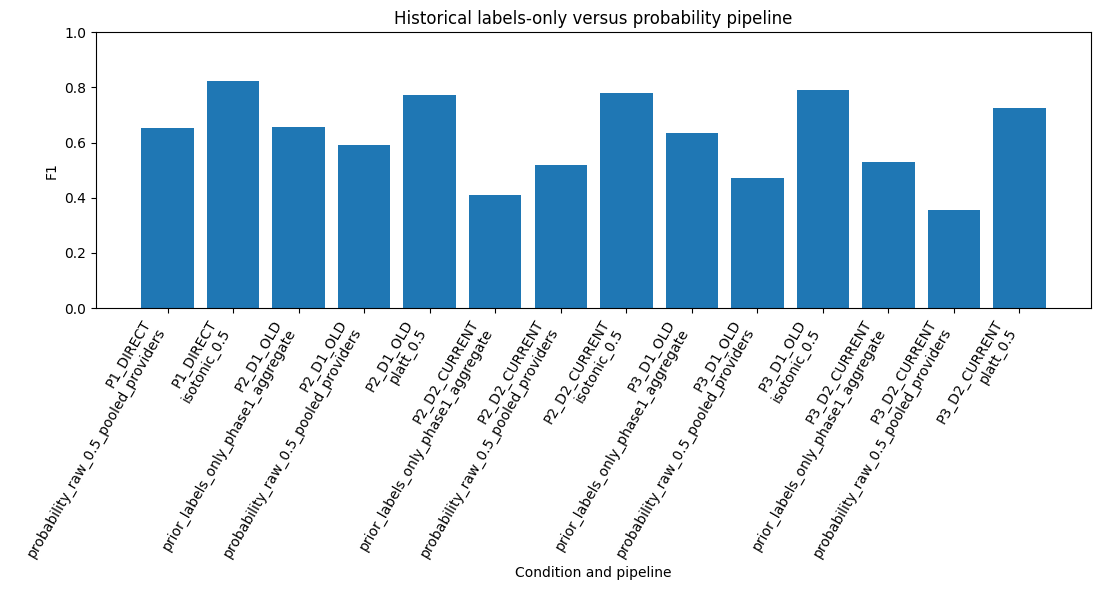

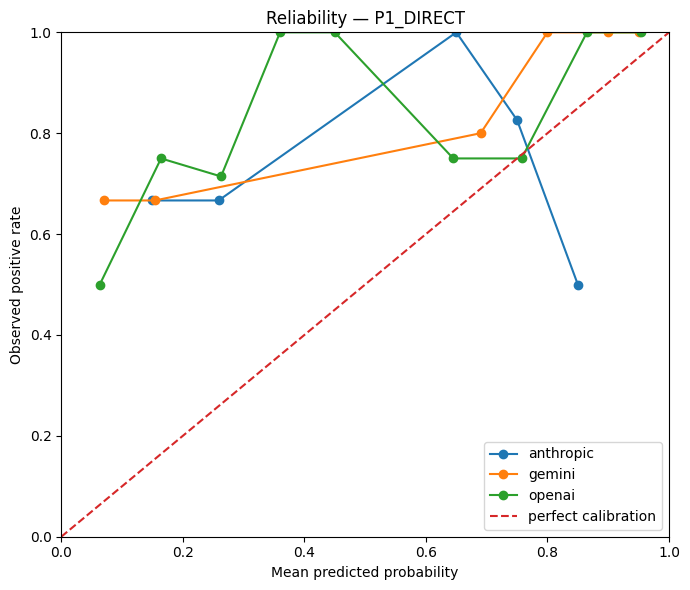

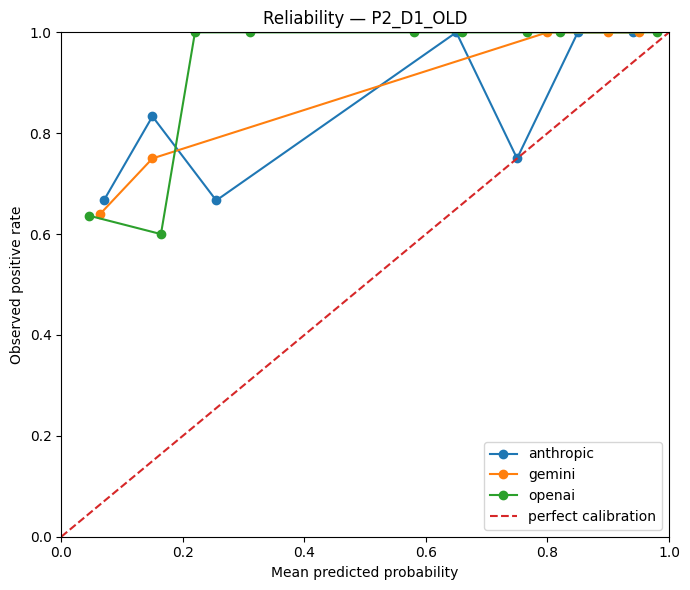

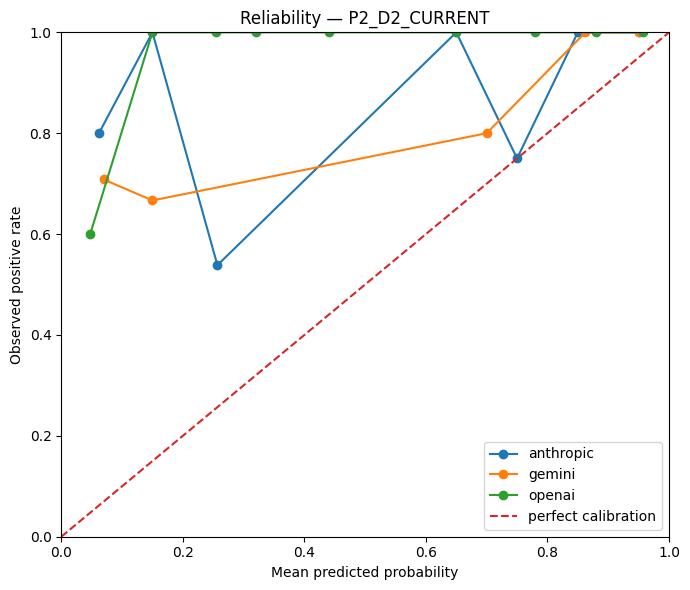

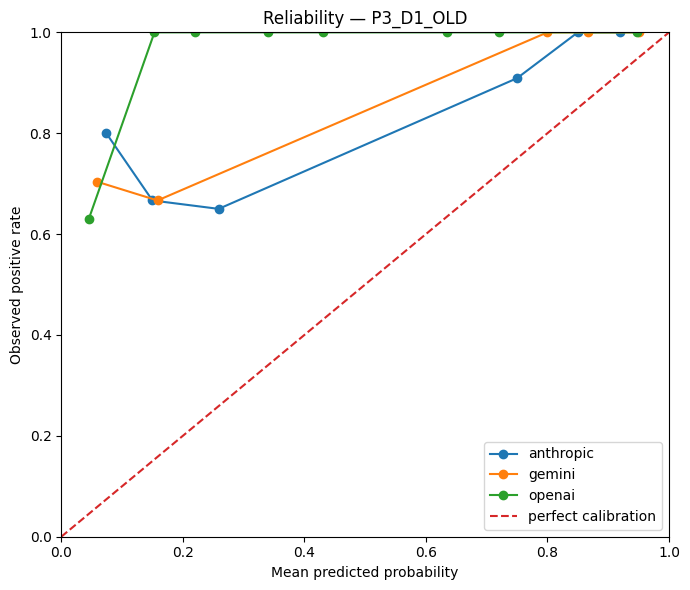

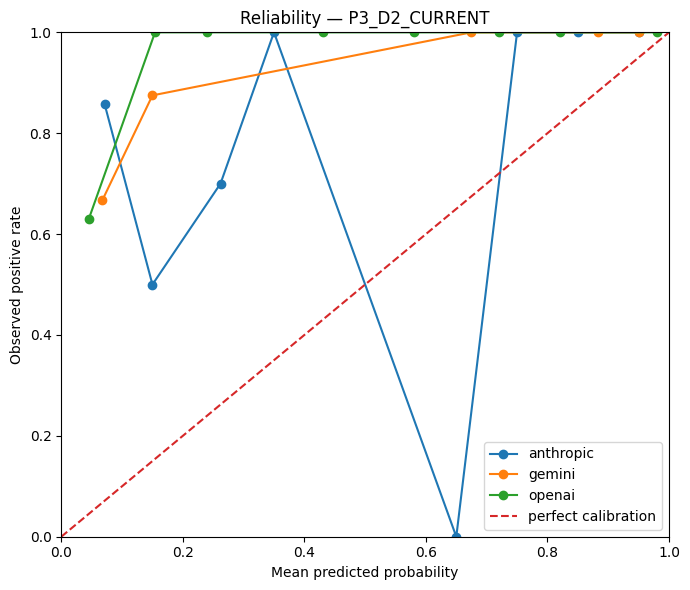

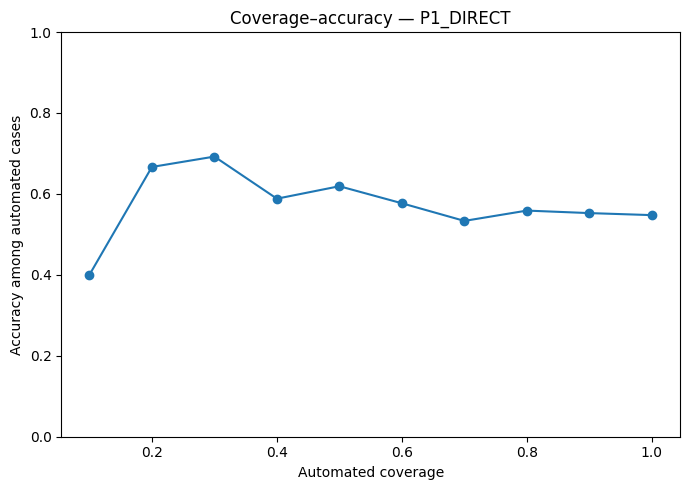

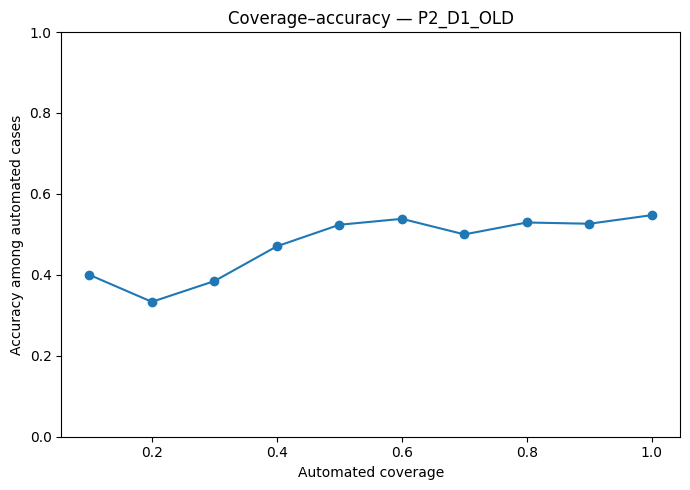

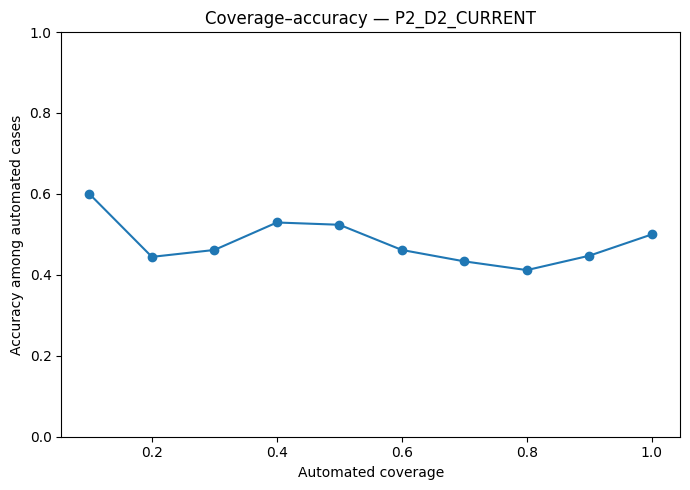

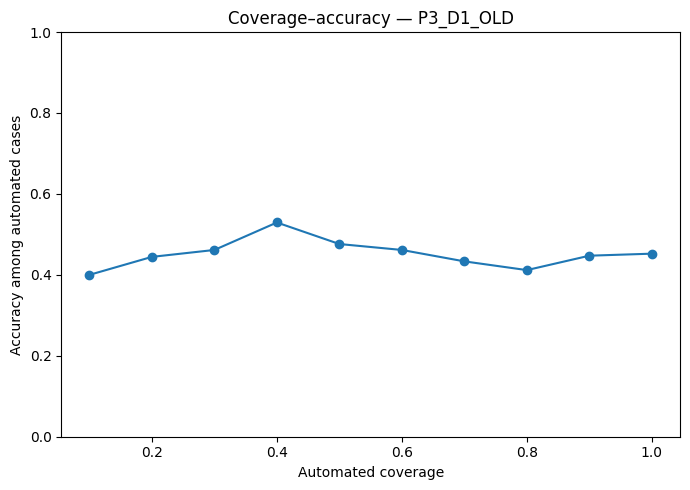

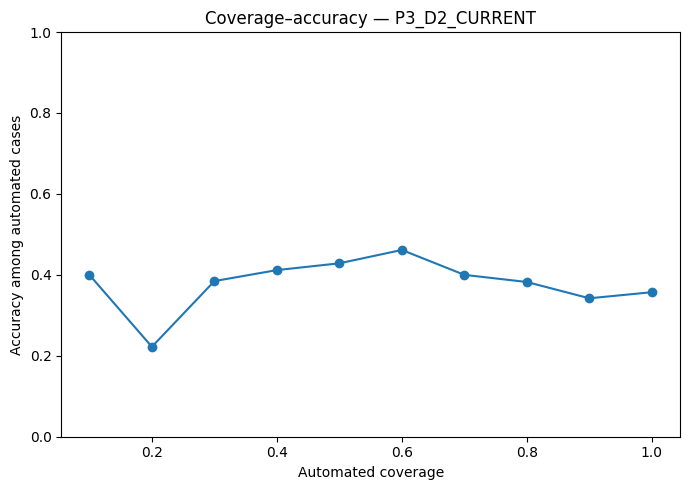

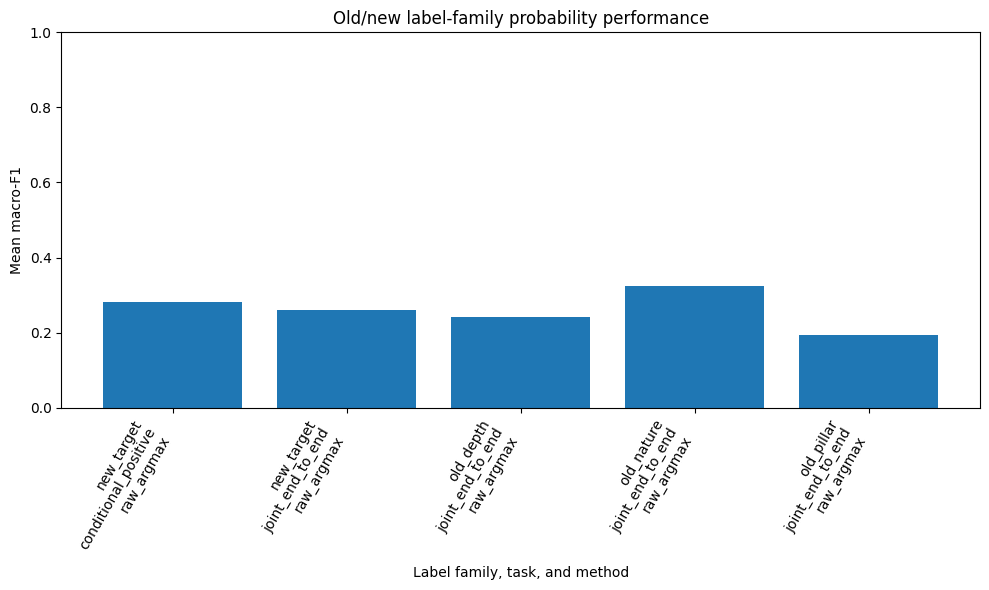

Saved plots: 12


In [63]:
import matplotlib.pyplot as plt

plot_files: list[str] = []


def save_current_figure(filename: str) -> Path:
    path = PLOT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plot_files.append(str(path))
    plt.show()
    plt.close()
    return path


# Binary F1 across historical/raw/postprocessed pipelines.
if not aggregate_historical_comparison_df.empty:
    plot_frame = aggregate_historical_comparison_df.dropna(subset=["f1"]).copy()
    # Keep the historical row, raw probability row, and the strongest OOF method for readable plotting.
    selected_rows = []
    for condition_id, group in plot_frame.groupby("condition_id"):
        historical = group[group["pipeline"].eq("prior_labels_only_phase1_aggregate")]
        raw = group[group["pipeline"].eq("probability_raw_0.5_pooled_providers")]
        processed = group[group["pipeline"].str.startswith("probability_postprocess::", na=False)].nlargest(1, "f1")
        selected_rows.extend([historical, raw, processed])
    selected_plot_df = pd.concat([part for part in selected_rows if not part.empty], ignore_index=True)
    if not selected_plot_df.empty:
        selected_plot_df["label"] = selected_plot_df["condition_id"] + "\n" + selected_plot_df["pipeline"].str.replace("probability_postprocess::", "", regex=False)
        plt.figure(figsize=(max(10, len(selected_plot_df) * 0.8), 6))
        plt.bar(selected_plot_df["label"], selected_plot_df["f1"])
        plt.ylabel("F1")
        plt.xlabel("Condition and pipeline")
        plt.title("Historical labels-only versus probability pipeline")
        plt.ylim(0, 1)
        plt.xticks(rotation=60, ha="right")
        save_current_figure("01_historical_vs_probability_f1.png")

# Reliability curve for each provider/condition in the primary seed.
if not calibration_tables_df.empty:
    for condition_id, condition_table in calibration_tables_df[calibration_tables_df["seed"].eq(SEEDS_TO_RUN[0])].groupby("condition_id"):
        plt.figure(figsize=(7, 6))
        plotted = False
        for provider, provider_table in condition_table.groupby("provider"):
            valid = provider_table.dropna(subset=["mean_probability", "observed_positive_rate"])
            if valid.empty:
                continue
            plt.plot(valid["mean_probability"], valid["observed_positive_rate"], marker="o", label=provider)
            plotted = True
        if plotted:
            plt.plot([0, 1], [0, 1], linestyle="--", label="perfect calibration")
            plt.xlabel("Mean predicted probability")
            plt.ylabel("Observed positive rate")
            plt.title(f"Reliability — {condition_id}")
            plt.legend()
            plt.xlim(0, 1)
            plt.ylim(0, 1)
            save_current_figure(f"02_reliability_{slugify(condition_id)}.png")
        else:
            plt.close()

# Coverage-accuracy curve.
if not coverage_accuracy_df.empty:
    for condition_id, condition_table in coverage_accuracy_df.groupby("condition_id"):
        plt.figure(figsize=(7, 5))
        plt.plot(condition_table["coverage"], condition_table["accuracy"], marker="o")
        plt.xlabel("Automated coverage")
        plt.ylabel("Accuracy among automated cases")
        plt.title(f"Coverage–accuracy — {condition_id}")
        plt.ylim(0, 1)
        save_current_figure(f"03_coverage_accuracy_{slugify(condition_id)}.png")

# Multiclass macro-F1 overview.
if not multiclass_summary_df.empty:
    best_multiclass = (
        multiclass_summary_df.dropna(subset=["macro_f1"])
        .sort_values(["label_family", "task", "provider", "condition_id", "macro_f1"], ascending=[True, True, True, True, False])
        .groupby(["label_family", "task", "provider", "condition_id"], as_index=False)
        .head(1)
    )
    if not best_multiclass.empty:
        plot_table = (
            best_multiclass.groupby(["label_family", "task", "method"], dropna=False)["macro_f1"]
            .mean()
            .reset_index()
        )
        plot_table["label"] = plot_table["label_family"] + "\n" + plot_table["task"] + "\n" + plot_table["method"]
        plt.figure(figsize=(max(10, len(plot_table) * 0.8), 6))
        plt.bar(plot_table["label"], plot_table["macro_f1"])
        plt.ylabel("Mean macro-F1")
        plt.xlabel("Label family, task, and method")
        plt.title("Old/new label-family probability performance")
        plt.ylim(0, 1)
        plt.xticks(rotation=60, ha="right")
        save_current_figure("04_multiclass_macro_f1.png")

print("Saved plots:", len(plot_files))


## 21. Export all research artifacts

The Excel workbook is a convenience report; CSV/JSONL files remain the preferred machine-readable research artifacts. The raw provider JSONL checkpoints are never overwritten by this export step.


In [ ]:
def safe_to_csv(frame: pd.DataFrame, name: str) -> Optional[Path]:
    if frame is None or frame.empty:
        return None
    path = REPORT_DIR / f"{name}.csv"
    frame.to_csv(path, index=False)
    return path


export_tables: dict[str, pd.DataFrame] = {
    "condition_registry": condition_table_df,
    "run_plan": run_plan_df,
    "coverage_audit": coverage_audit_df,
    "probability_rows": probability_df,
    "ensemble_rows": ensemble_df,
    "raw_binary_summary": raw_binary_summary_df,
    "selected_binary_summary": selected_binary_summary_df,
    "calibration_tables": calibration_tables_df,
    "postprocess_rows": all_postprocess_row_df,
    "postprocess_folds": postprocess_fold_df,
    "postprocess_summary": all_postprocess_summary_df,
    "exploratory_best": exploratory_best_postprocess_df,
    "multiclass_rows": multiclass_oof_row_df,
    "multiclass_summary": multiclass_summary_df,
    "labels_only_baseline": baseline_df,
    "binary_paired": binary_paired_comparison_df,
    "binary_paired_detail": binary_paired_detail_df,
    "label_paired": label_paired_comparison_df,
    "review_queue": review_queue_df,
    "coverage_accuracy": coverage_accuracy_df,
    "historical_reference": historical_phase1_reference_df,
    "historical_comparison": aggregate_historical_comparison_df,
    "benchmark_canonical": benchmark_df,
    "old_codebook": old_codebook_df,
    "new_codebook": new_codebook_df,
    "prompt_audit": prompt_audit_df,
}

csv_paths = []
for name, frame in export_tables.items():
    path = safe_to_csv(frame, name)
    if path is not None:
        csv_paths.append(str(path))

excel_path = REPORT_DIR / "Unlearning_Phase1_Probability_Postprocessing_Report.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for name, frame in export_tables.items():
        if frame is None or frame.empty:
            continue
        sheet_name = name[:31]
        export_frame = frame.copy()
        # Excel cells cannot store arbitrary nested dict/list values.
        for column in export_frame.columns:
            if export_frame[column].map(lambda value: isinstance(value, (dict, list, tuple, set))).any():
                export_frame[column] = export_frame[column].map(lambda value: stable_json(value) if isinstance(value, (dict, list, tuple, set)) else value)
        export_frame.to_excel(writer, sheet_name=sheet_name, index=False)

manifest = {
    "protocol_version": PROTOCOL_VERSION,
    "prompt_revision": PROMPT_REVISION,
    "created_utc": utc_now_iso(),
    "demo_mode": DEMO_MODE,
    "mock_provider": USE_MOCK_PROVIDER,
    "benchmark_source": benchmark_source,
    "old_codebook_source": old_codebook_source,
    "new_codebook_source": new_codebook_source,
    "labels_only_baseline_path": str(LABELS_ONLY_BASELINE_PATH) if LABELS_ONLY_BASELINE_PATH else None,
    "dataset_sha256": DATASET_SHA256,
    "benchmark_rows": len(benchmark_df),
    "historical_gold_shared_between_codebooks": bool(shared_gold_warning),
    "conditions_to_run": CONDITIONS_TO_RUN,
    "seed_condition_pairs": seed_condition_pairs(),
    "provider_configs": {
        provider: {key: value for key, value in cfg.items() if key != "api_key_env"}
        for provider, cfg in PROVIDER_CONFIGS.items()
    },
    "probability_semantics": "elicited_model_probabilities_not_native_token_logprobs",
    "threshold_objective": PRIMARY_THRESHOLD_OBJECTIVE,
    "specificity_floor": SPECIFICITY_FLOOR,
    "cv_splits": CV_SPLITS,
    "cv_repeats": CV_REPEATS,
    "expected_benchmark_rows": EXPECTED_BENCHMARK_ROWS,
    "expected_dataset_sha256": EXPECTED_DATASET_SHA256,
    "raw_jsonl_files": {
        provider: str(provider_results_path(provider))
        for provider, cfg in PROVIDER_CONFIGS.items() if cfg["enabled"]
    },
    "excel_report": str(excel_path),
    "csv_files": csv_paths,
    "plot_files": plot_files,
}
manifest_path = REPORT_DIR / "experiment_manifest.json"
manifest_path.write_text(json.dumps(json_safe(manifest), ensure_ascii=False, indent=2), encoding="utf-8")

print("Excel report:", excel_path)
print("Manifest:", manifest_path)
print("CSV files:", len(csv_paths))
print("Raw JSONL checkpoints:")
for provider, cfg in PROVIDER_CONFIGS.items():
    if cfg["enabled"]:
        print(" -", provider_results_path(provider))


## 22. Interpretation and decision rules

Use the outputs in this order:

1. **Coverage audit:** exclude provider/condition groups with incomplete or schema-invalid calls before comparing accuracy.
2. **Raw probability metrics:** determine whether the probability prompt itself changed decisions relative to the labels-only baseline.
3. **Calibration metrics:** inspect Brier, log loss, ECE, and reliability curves. A higher F1 with worse calibration is a different tradeoff, not an unqualified improvement.
4. **Out-of-fold post-processing:** compare every method to raw 0.5 and the frozen labels-only baseline. Do not report a threshold fitted on all 42 passages as an unbiased test result.
5. **Subordinate labels:** report conditional-positive and end-to-end joint results separately. A model can classify the target well conditional on Yes while still failing the complete task because it misses Unlearning.
6. **Old versus new codebook:** if both are scored against one historical gold column, describe the result as sensitivity to definition wording—not proof that either codebook is theoretically correct.
7. **Provider ensemble:** compare it as a separate production option; it is not a like-for-like single-model baseline.
8. **Human review:** use entropy/disagreement to triage ambiguous rows, then freeze any adjudicated labels before the final confirmatory rerun.

### Recommended confirmatory sequence

- Freeze old-definition, new-definition, and final-definition human labels separately.
- Pre-register one probability post-processing rule using the exploratory results.
- Evaluate that frozen rule on a held-out document or newly adjudicated set.
- Only then claim that probability elicitation/post-processing improves generalization over the labels-only pipeline.


## 23. Final run checklist

Before the paid run, verify all of the following:

- `DEMO_MODE` is `False`.
- The canonical benchmark contains the intended cleaned 42 passages.
- `DATASET_SHA256` is copied into `EXPECTED_DATASET_SHA256` and enforcement is enabled for the final run.
- The old and new codebook source paths/sheets are correct.
- The model IDs match the earlier labels-only Phase 1 run, or deviations are documented.
- Current provider prices are entered if you need a dollar guard.
- `LABELS_ONLY_BASELINE_PATH` points to frozen row-level outputs.
- `RUN_API_CALLS=True` and the confirmation phrase is exact.
- The final exported manifest says `demo_mode: false` and `mock_provider: false`.
